Fig 1

SVG saved as arena_map.svg


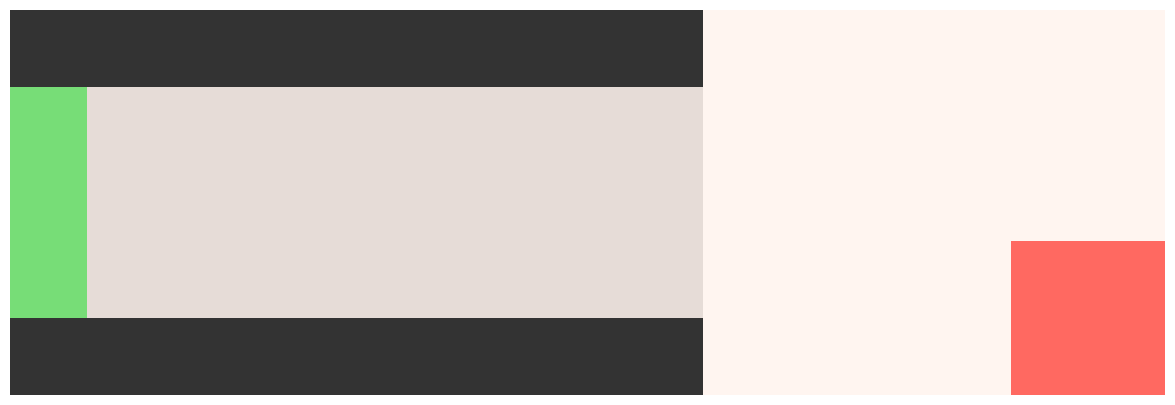

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Setup the Mask
mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

# 2. Settings
rows, cols = mask.shape

# Revised Palette (Normalized to 0-1 for Matplotlib)
def hex_to_rgb(r, g, b):
    return (r/255, g/255, b/255)

colors = {
    'wall':           hex_to_rgb(51, 51, 51),
    'shelter':        hex_to_rgb(119, 221, 119),
    'threat':         hex_to_rgb(255, 105, 97),
    'floor_corridor': hex_to_rgb(230, 220, 215),
    'floor_chamber':  hex_to_rgb(255, 245, 240)
}

# 3. Create Figure
# We set the aspect ratio to match the mask dimensions
fig, ax = plt.subplots(figsize=(cols, rows))
ax.set_xlim(0, cols)
ax.set_ylim(0, rows)
ax.set_aspect('equal')
ax.axis('off')  # Hide axes for a clean map

# 4. Draw the Grid
for r in range(rows):
    for c in range(cols):
        # Determine Color
        if not mask[r, c]:
            fill = colors['wall']
        elif c == 0 and 1 <= r <= 3:
            fill = colors['shelter']
        elif c >= 13 and r >= 3:
            fill = colors['threat']
        else:
            if c <= 8:
                fill = colors['floor_corridor']
            else:
                fill = colors['floor_chamber']
        
        # Matplotlib's (0,0) is bottom-left, PIL's is top-left.
        # To match your PIL output, we flip the row index:
        y_pos = rows - 1 - r
        
        # Add a borderless rectangle patch
        rect = patches.Rectangle((c, y_pos), 1, 1, facecolor=fill, edgecolor='none')
        ax.add_patch(rect)

# 5. Save as SVG
plt.savefig("arena_map.svg", format='svg', bbox_inches='tight', pad_inches=0)
print("SVG saved as arena_map.svg")
plt.show()

In [3]:
import pandas as pd
import numpy as np

final_mask = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
])


active_cells = np.argwhere(final_mask == 1) 
# Create a dictionary to map (row, col) to a zero-indexed bin ID (0-56)
bin_id_map = {tuple(pos): i for i, pos in enumerate(active_cells)}

def get_closest_bin(r, c):
    if final_mask[r, c] == 1:
        return bin_id_map[(r, c)]
    
    # Calculate Euclidean distance to all active cells
    distances = np.sum((active_cells - np.array([r, c]))**2, axis=1)
    nearest_idx = np.argmin(distances)
    nearest_r, nearest_c = active_cells[nearest_idx]
    
    return bin_id_map[(nearest_r, nearest_c)]

def map_position(row, min_x, min_y, max_x, max_y, n_rows=5, n_cols=15, flipped=False):
    # Normalize and find raw grid coordinates
    x_norm = np.clip((row['Center_x'] - min_x) / (max_x - min_x), 0, 0.999)
    y_norm = np.clip((row['Center_y'] - min_y) / (max_y - min_y), 0, 0.999)

    if flipped:
        x_norm = 0.999 - x_norm
        y_norm = 0.999 - y_norm
    
    r = int(np.floor(y_norm * n_rows))
    c = int(np.floor(x_norm * n_cols))
    
    # Return the mapped bin ID using nearest-neighbor logic
    return get_closest_bin(r, c)

def get_trajectory(df, n_steps=2000, flipped=False):
    df_filtered = df.copy()
    # Coarse-grain into 2000 steps
    df_filtered['step_number'] = np.linspace(0, n_steps, len(df_filtered), endpoint=False).astype(int)
    # Aggregate mean position per step
    coarse_data = df_filtered.groupby('step_number').agg({
        'Center_x': 'mean',
        'Center_y': 'mean'
    }).reset_index()

    min_x, max_x = df_filtered['Center_x'].min(), df_filtered['Center_x'].max()
    min_y, max_y = df_filtered['Center_y'].min(), df_filtered['Center_y'].max()

    coarse_data['location'] = coarse_data.apply(map_position, axis=1, args=(min_x, min_y, max_x, max_y), flipped=flipped)
    final_table = coarse_data[['step_number', 'location']]

    return final_table


confidence_threshold = 0.8

df_16_pre = pd.read_csv(f'./dlc/DLC_all_batches/m16_investigation_hab3_cropped.csv', index_col=0)
df_16_pre = df_16_pre[df_16_pre['Center_p'] > confidence_threshold]
trajectory_16_pre = get_trajectory(df_16_pre, n_steps=2000)['location']

df_16_post = pd.read_csv(f'./dlc/DLC_all_batches/m16_investigation_def2_cropped.csv', index_col=0)
df_16_post = df_16_post[df_16_post['Center_p'] > confidence_threshold]
trajectory_16_post = get_trajectory(df_16_post, n_steps=2000)['location']

trajectory_16_pre = trajectory_16_pre.to_list()
trajectory_16_post = trajectory_16_post.to_list()

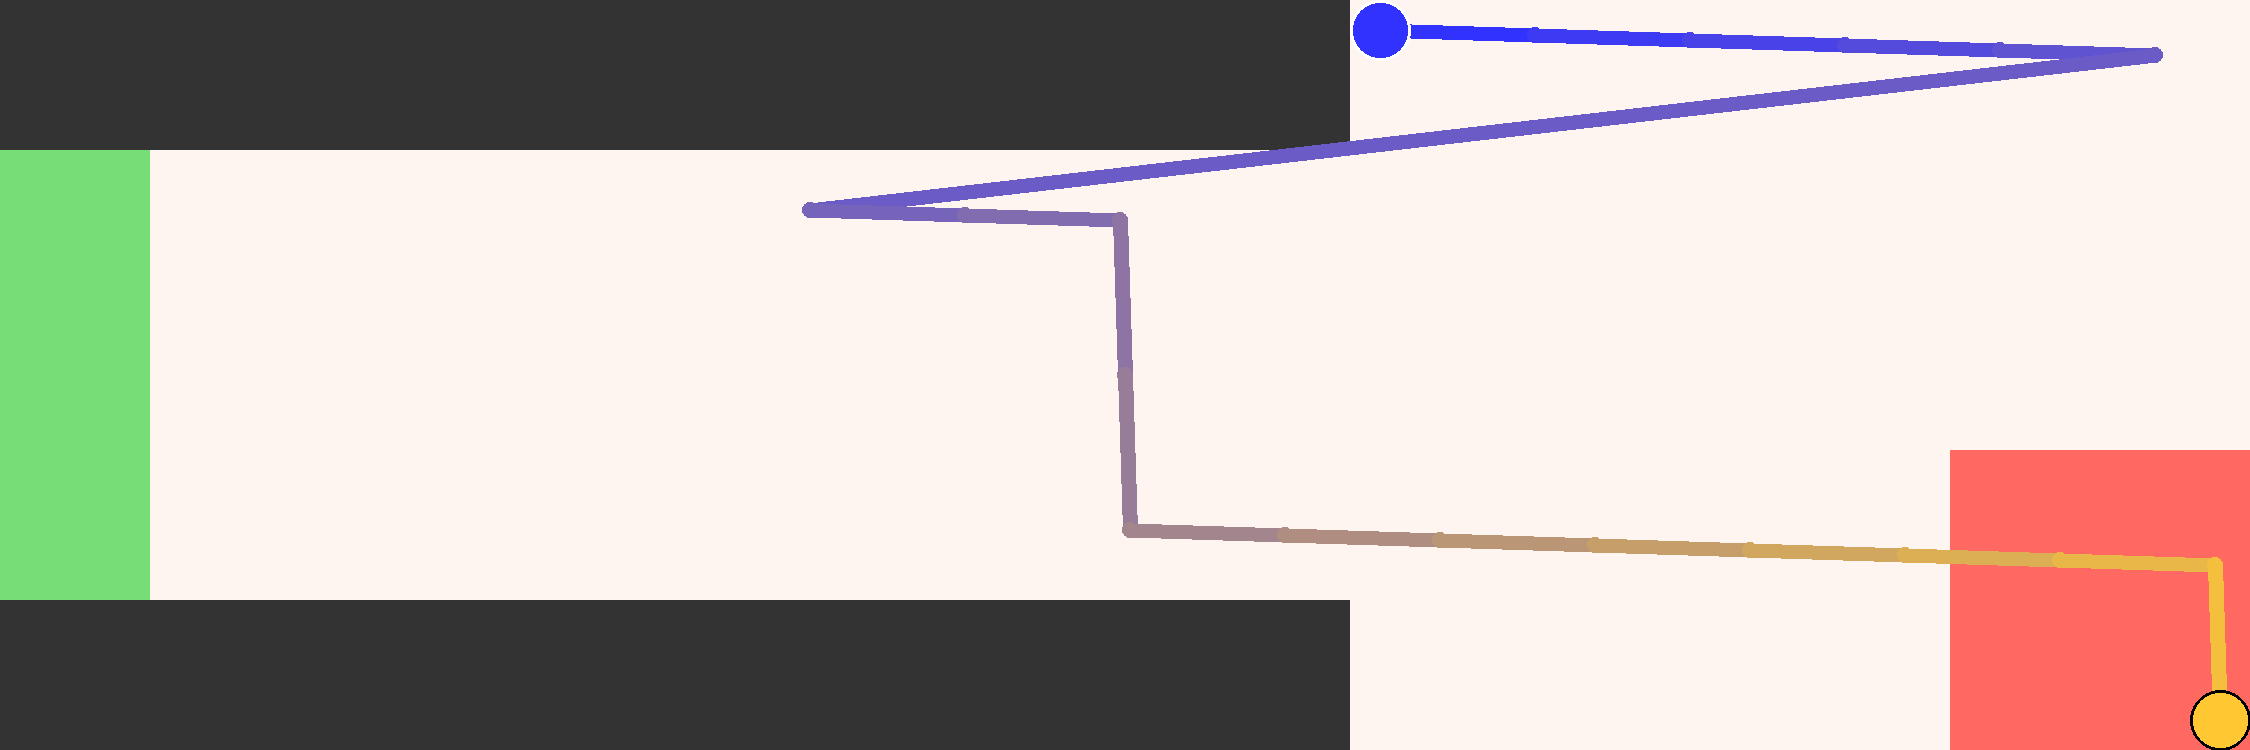

In [7]:
import numpy as np
from PIL import Image, ImageDraw

# --- Setup ---
mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

cell_size = 150 
rows, cols = mask.shape

# Visual Settings
line_width = int(cell_size * 0.10) 
marker_radius = int(cell_size * 0.2)

# MAX_OFFSET: How far from the center can the line drift?
# 0.3 means it uses the middle 60% of the cell, leaving 20% buffer on edges
max_offset = cell_size * 0.3  

colors = {
    'wall':    (51, 51, 51),
    'floor':   (255, 245, 240),
    'shelter': (119, 221, 119),
    'threat':  (255, 105, 97),
    'start':   (50, 50, 255),
    'end':     (255, 200, 50)
}

idx_to_rc = {}
counter = 0
for r in range(rows):
    for c in range(cols):
        if mask[r, c]:
            idx_to_rc[counter] = (r, c)
            counter += 1

example_trajectory = [
    0, 1, 2, 3, 4, 5,              
    11, 12, 13, 28, 43, 44,        
    45, 46, 47, 48, 49, 50, 56     
]

def get_gradient_color(progress, start_rgb, end_rgb):
    r = int(start_rgb[0] + (end_rgb[0] - start_rgb[0]) * progress)
    g = int(start_rgb[1] + (end_rgb[1] - start_rgb[1]) * progress)
    b = int(start_rgb[2] + (end_rgb[2] - start_rgb[2]) * progress)
    return (r, g, b)

def draw_trace(traj):
    img = Image.new('RGB', (cols * cell_size, rows * cell_size), colors['wall'])
    draw = ImageDraw.Draw(img)

    # 1. Draw Background
    for r in range(rows):
        for c in range(cols):
            x0, y0 = c * cell_size, r * cell_size
            x1, y1 = x0 + cell_size, y0 + cell_size
            
            if not mask[r, c]:
                fill = colors['wall']
            elif c == 0 and 1 <= r <= 3:
                fill = colors['shelter']
            elif c >= 13 and r >= 3:
                fill = colors['threat']
            else:
                fill = colors['floor']
            
            draw.rectangle([x0, y0, x1, y1], fill=fill)

    if len(traj) > 1:
        points = []
        total_steps = len(traj)

        # 2. Calculate Points with TIME OFFSET
        for i, idx in enumerate(traj):
            r, c = idx_to_rc[idx]
            
            # Standard Center
            cx = c * cell_size + cell_size // 2
            cy = r * cell_size + cell_size // 2

            # Calculate Time Factor (0.0 at start, 1.0 at end)
            time_factor = i / max(1, total_steps - 1) 

            # Calculate Offset
            # If time_factor is 0 (start), offset is -max_offset (Top-Left)
            # If time_factor is 1 (end), offset is +max_offset (Bottom-Right)
            current_offset = -max_offset + (2 * max_offset * time_factor)

            # Apply offset to both X and Y to create a diagonal slide
            px = cx + current_offset
            py = cy + current_offset
            
            points.append((px, py))

        # 3. Draw Lines
        num_segments = len(points) - 1
        for i in range(num_segments):
            progress = i / max(1, num_segments)
            color = get_gradient_color(progress, colors['start'], colors['end'])
            
            p1 = points[i]
            p2 = points[i+1]

            draw.line([p1, p2], fill=color, width=line_width)
            
            # Draw joint to make corners smooth
            draw.ellipse([p1[0]-line_width/2, p1[1]-line_width/2, 
                          p1[0]+line_width/2, p1[1]+line_width/2], fill=color)

        # 4. Draw Start/End Markers (Using the offset positions)
        start_pt = points[0]
        end_pt = points[-1]
        
        # Start (Blue)
        draw.ellipse([start_pt[0]-marker_radius, start_pt[1]-marker_radius, 
                      start_pt[0]+marker_radius, start_pt[1]+marker_radius], 
                      fill=colors['start'], outline=(255,255,255), width=3)
        
        # End (Yellow)
        draw.ellipse([end_pt[0]-marker_radius, end_pt[1]-marker_radius, 
                      end_pt[0]+marker_radius, end_pt[1]+marker_radius], 
                      fill=colors['end'], outline=(0,0,0), width=3)
        
    return img

img = draw_trace(example_trajectory)
display(img)

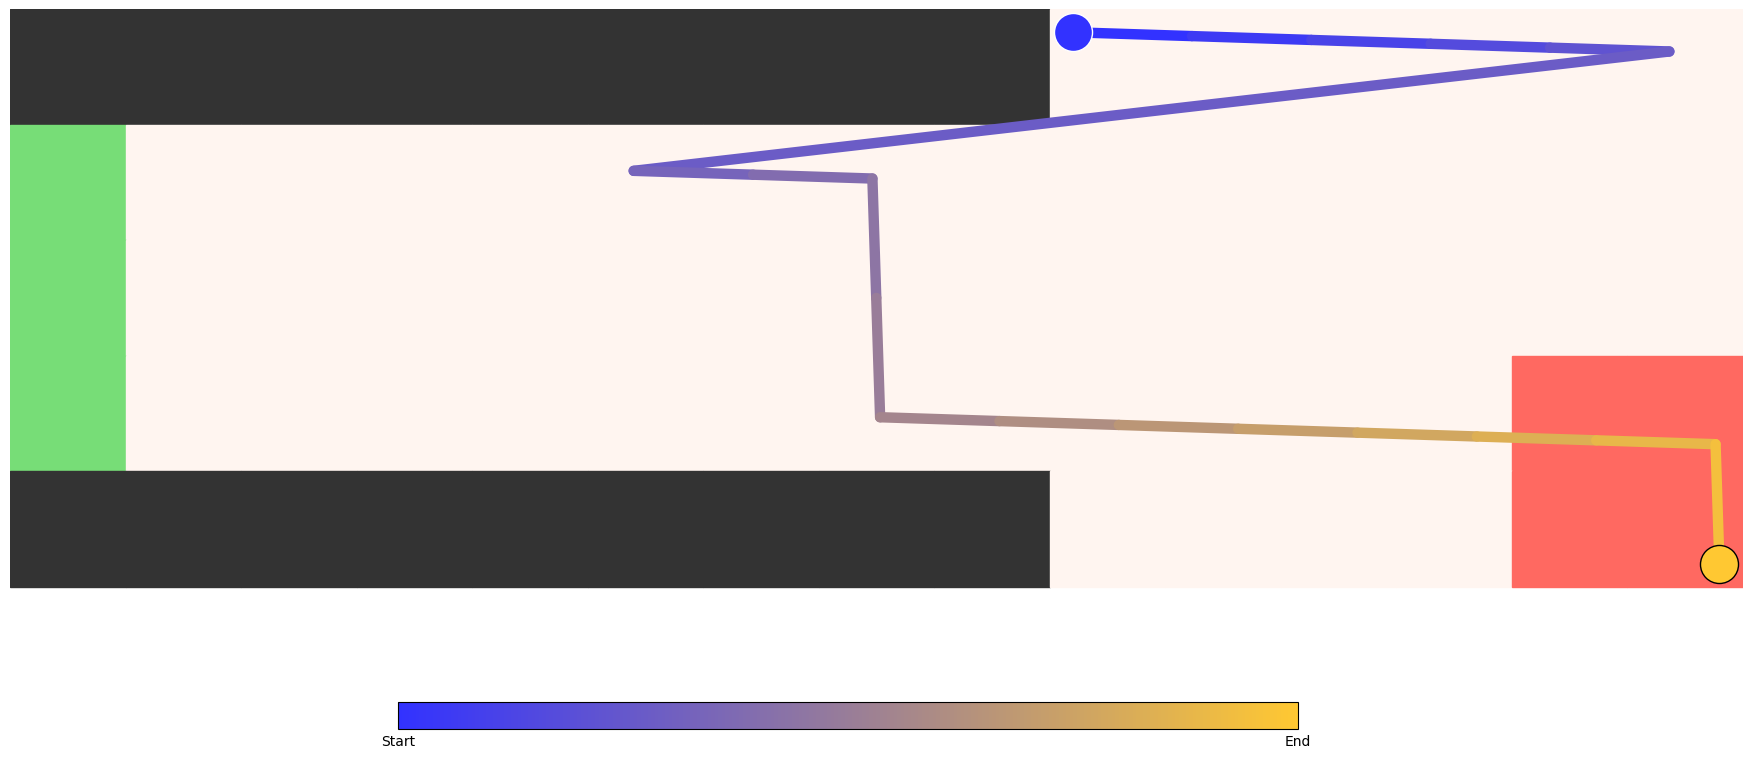

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

# --- Setup ---
mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

cell_size = 150 
rows, cols = mask.shape
px_to_unit = 1/100 # Scaling for matplotlib

colors_svg = {
    'wall':    (51/255, 51/255, 51/255),
    'floor':   (255/255, 245/255, 240/255),
    'shelter': (119/255, 221/255, 119/255),
    'threat':  (255/255, 105/255, 97/255),
    'start':   (50/255, 50/255, 255/255),
    'end':     (255/255, 200/255, 50/255)
}

idx_to_rc = {}
counter = 0
for r in range(rows):
    for c in range(cols):
        if mask[r, c]:
            idx_to_rc[counter] = (r, c)
            counter += 1

example_trajectory = [0, 1, 2, 3, 4, 5, 11, 12, 13, 28, 43, 44, 45, 46, 47, 48, 49, 50, 56]

def draw_trace_svg(traj, filename=None):
    # Create Figure
    fig, ax = plt.subplots(figsize=(cols * cell_size * px_to_unit, (rows+1) * cell_size * px_to_unit))
    ax.set_xlim(0, cols * cell_size)
    ax.set_ylim(0, (rows + 1) * cell_size) # Extra space for legend
    ax.set_aspect('equal')
    ax.axis('off')

    # 1. Draw Background
    for r in range(rows):
        for c in range(cols):
            x0, y0 = c * cell_size, (rows - 1 - r + 1) * cell_size # Flip Y for matplotlib
            
            if not mask[r, c]:
                fill = colors_svg['wall']
            elif c == 0 and 1 <= r <= 3:
                fill = colors_svg['shelter']
            elif c >= 13 and r >= 3:
                fill = colors_svg['threat']
            else:
                fill = colors_svg['floor']
            
            ax.add_patch(patches.Rectangle((x0, y0), cell_size, cell_size, color=fill, zorder=1))

    # 2. Draw Trajectory
    if len(traj) > 1:
        max_offset = cell_size * 0.3
        points = []
        for i, idx in enumerate(traj):
            r, c = idx_to_rc[idx]
            cx = c * cell_size + cell_size / 2
            cy = (rows - 1 - r + 1) * cell_size + cell_size / 2
            time_factor = i / max(1, len(traj) - 1)
            current_offset = -max_offset + (2 * max_offset * time_factor)
            points.append((cx + current_offset, cy - current_offset))

        # Gradient Line
        for i in range(len(points) - 1):
            progress = i / (len(points) - 1)
            c = [(1-progress)*colors_svg['start'][j] + progress*colors_svg['end'][j] for j in range(3)]
            ax.plot([points[i][0], points[i+1][0]], [points[i][1], points[i+1][1]], 
                    color=c, linewidth=cell_size*0.05, solid_capstyle='round', zorder=3)

        # Start/End Markers
        ax.scatter(*points[0], color=colors_svg['start'], s=750, edgecolors='white', zorder=4)
        ax.scatter(*points[-1], color=colors_svg['end'], s=750, edgecolors='black', zorder=4)

    # 3. ADD LEGEND BAR (Blue to Yellow)
    # Positioning the bar at the bottom center
    gradient_ax = fig.add_axes([0.3, 0.08, 0.4, 0.03]) # [left, bottom, width, height]
    cmap = LinearSegmentedColormap.from_list('custom_grad', [colors_svg['start'], colors_svg['end']])
    cb = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), cax=gradient_ax, orientation='horizontal')
    cb.set_ticks([0, 1])
    cb.set_ticklabels(['Start', 'End'])
    gradient_ax.tick_params(labelsize=10, length=0)

    # 4. SAVE AS SVG
    if filename is not None:
        plt.savefig(filename, format='svg', bbox_inches='tight', transparent=True)
    plt.show()

draw_trace_svg(example_trajectory, filename=None)

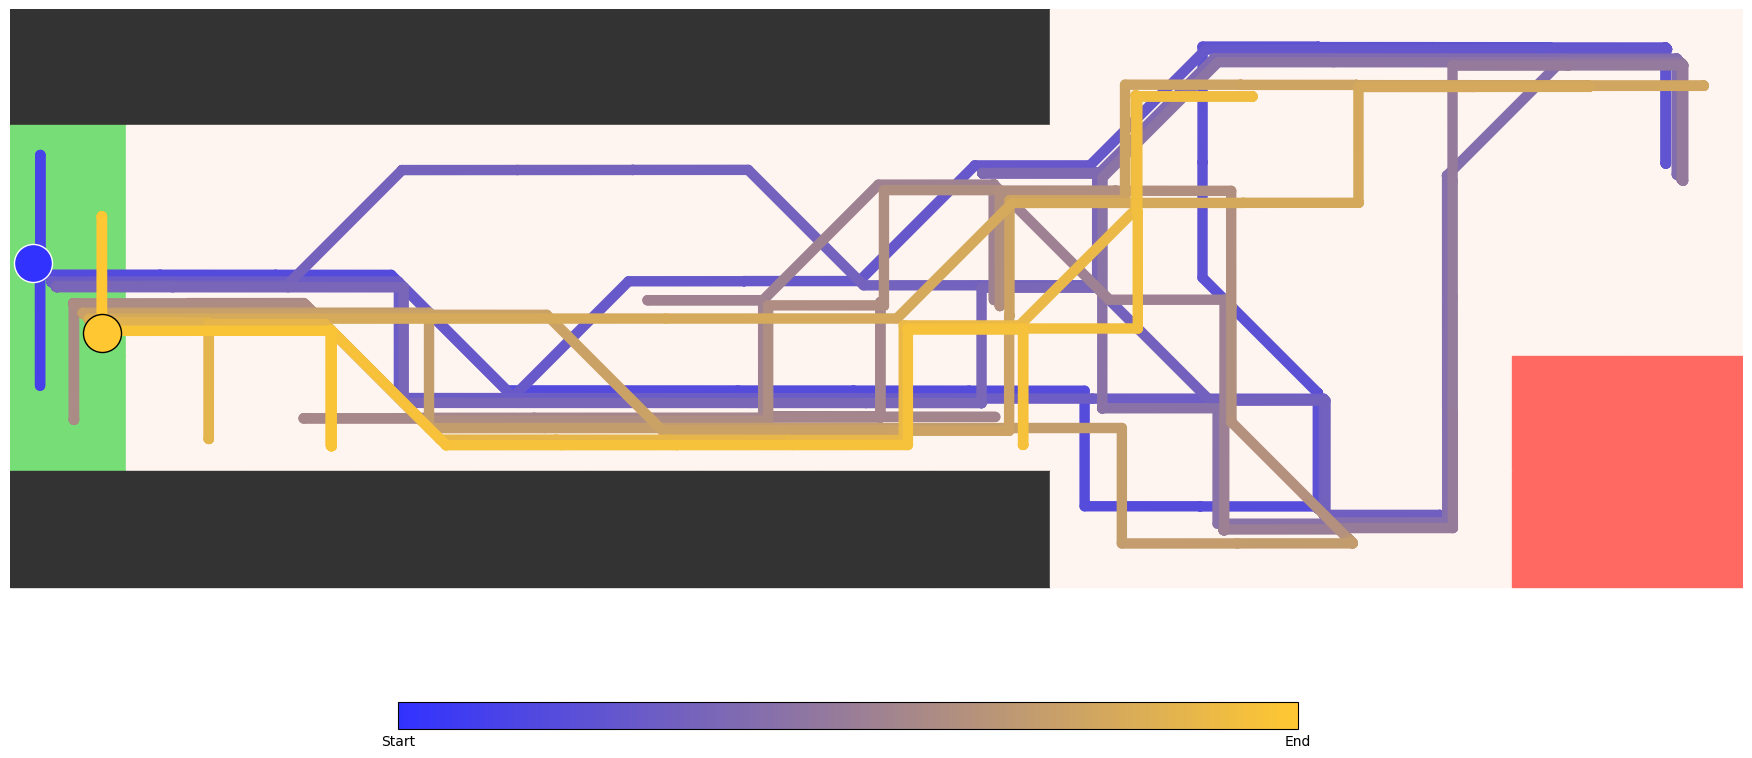

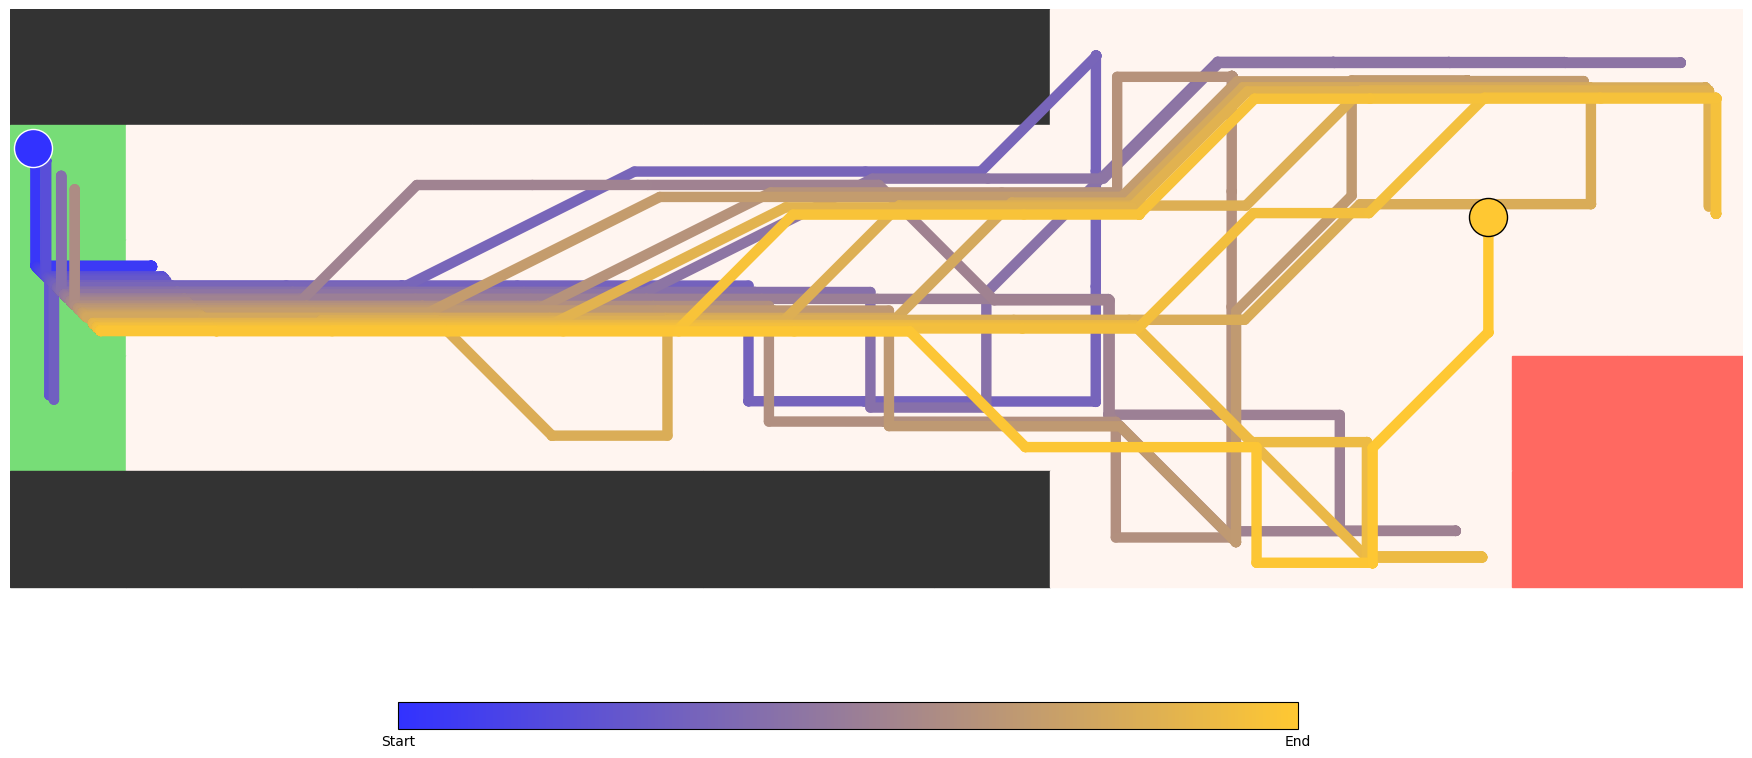

pre


None

post


None

In [52]:
trace_16_pre = draw_trace_svg(trajectory_16_pre)
trace_16_post = draw_trace_svg(trajectory_16_post)
print("pre")
display(trace_16_pre)
print("post")
display(trace_16_post)

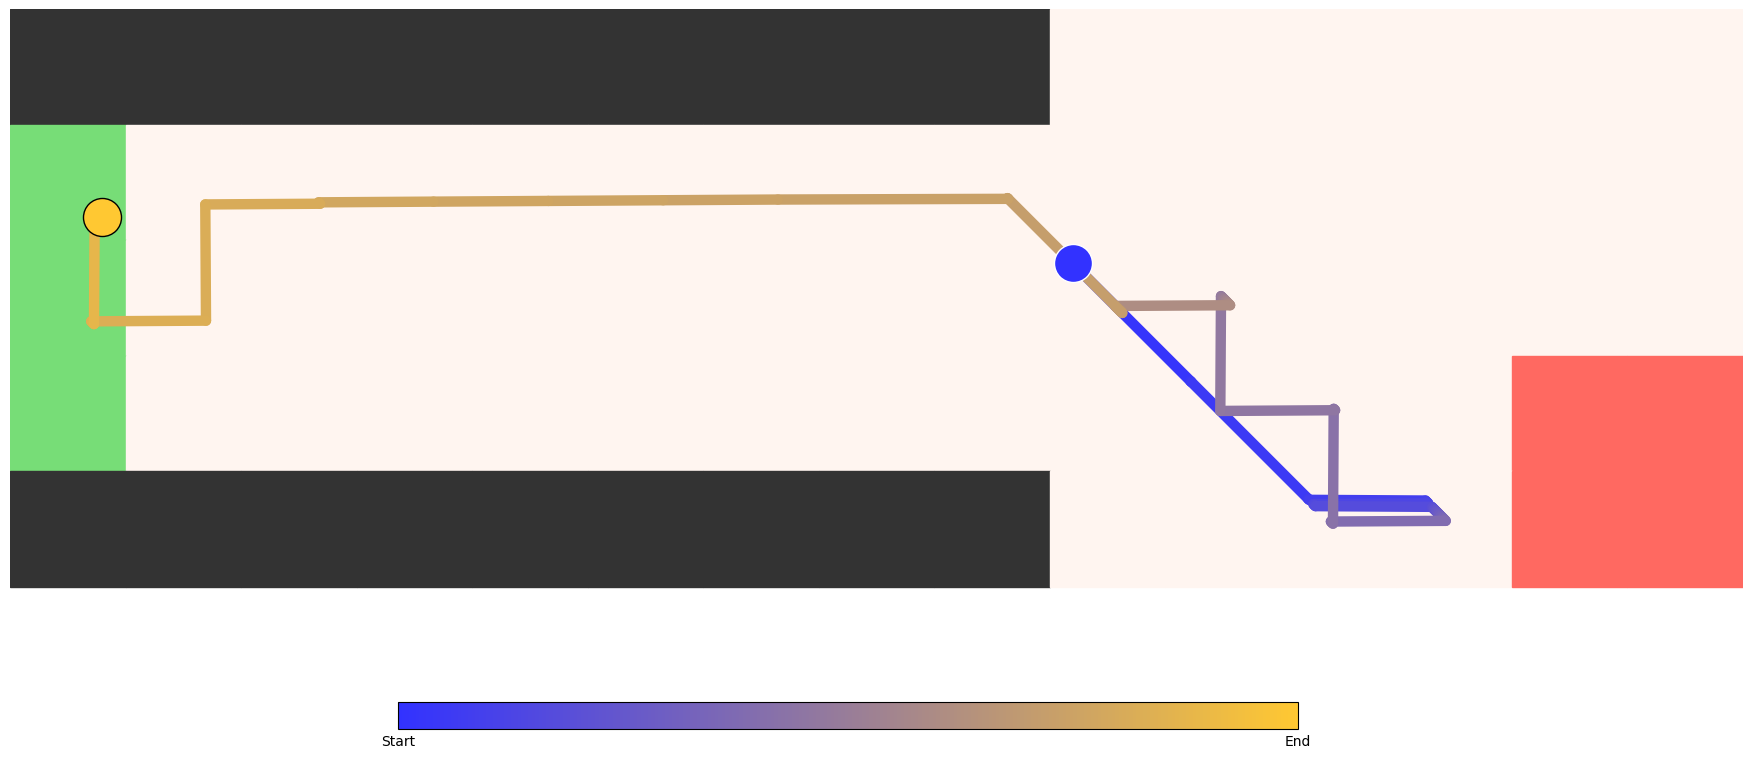

None

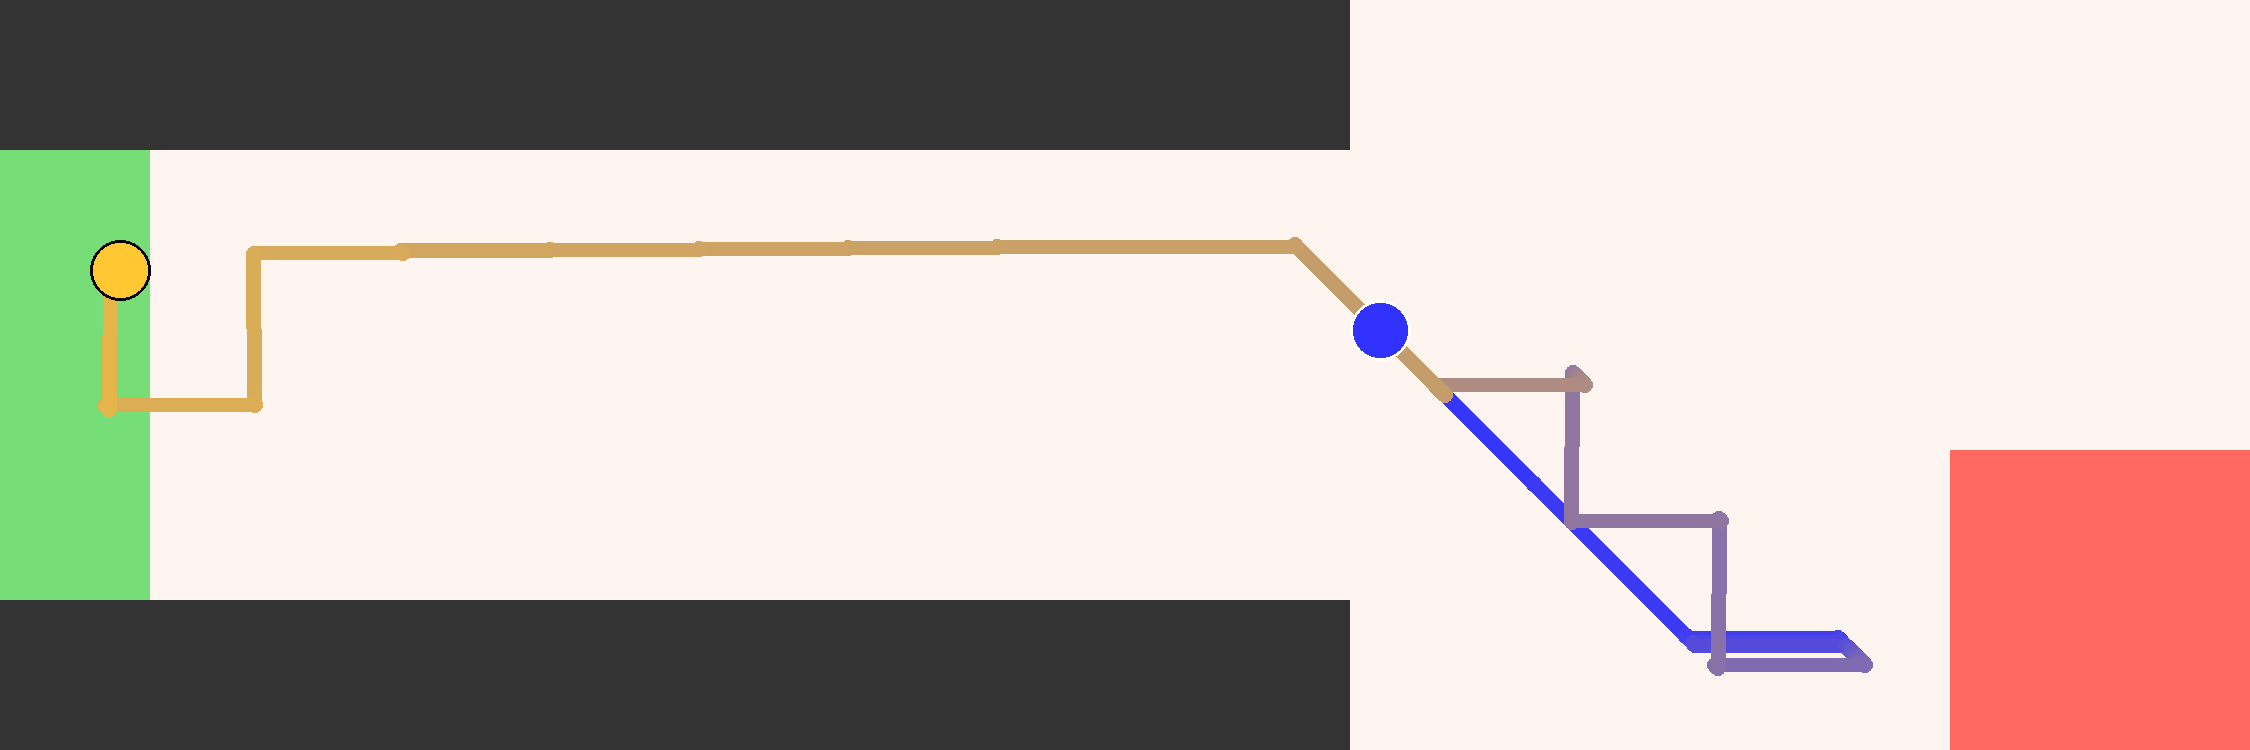

In [53]:
# df_26_post = pd.read_csv(f'./dlc/DLC_all_batches/m26_investigation_def3_cropped.csv', index_col=0)
# df_26_post = df_26_post[df_26_post['Center_p'] > confidence_threshold]
# trajectory_26_post = get_trajectory(df_26_post, n_steps=2000, flipped=True)['location'].to_list()

# start_step = 1500
# n_steps = 2000
# trace_26_post = draw_trace(trajectory_26_post[start_step:n_steps])
# display(trace_26_post) # SCARED MOUSE

df_22_post = pd.read_csv(f'./dlc/DLC_all_batches/m22_investigation_def3_cropped.csv', index_col=0)
df_22_post = df_22_post[df_22_post['Center_p'] > confidence_threshold]
trajectory_22_post = get_trajectory(df_22_post, n_steps=2000, flipped=True)['location'].to_list()

start_step = 170
n_steps = 270
trace_22_post = draw_trace_svg(trajectory_22_post[start_step:n_steps])
display(trace_22_post) # EXPLORER
trace_og = draw_trace(trajectory_22_post[start_step:n_steps])
display(trace_og)

In [21]:
from collections import Counter
import matplotlib.cm as cm
import math
from PIL import ImageFont

c_wall = []
for i in colors_svg['wall']:
    c_wall.append(int(i*255))

c_wall = tuple(c_wall)

def draw_difference_heatmap(traj_a, traj_b, opacity=0.85):
    # 1. Calculate Differences (B - A)
    counts_a = Counter(traj_a)
    counts_b = Counter(traj_b)
    
    # Get set of all visited locations in either trajectory
    all_indices = set(counts_a.keys()).union(set(counts_b.keys()))
    
    diff_map = {}
    max_diff = 1 # Avoid div by zero
    
    for idx in all_indices:
        # Post (b) - Pre (a)
        val = counts_b.get(idx, 0) - counts_a.get(idx, 0)
        diff_map[idx_to_rc[idx]] = val
        if abs(val) > max_diff:
            max_diff = abs(val)

    # 2. Setup Image
    img = Image.new('RGB', (cols * cell_size, rows * cell_size), c_wall)
    draw = ImageDraw.Draw(img)
    
    # Use a diverging colormap: Blue (neg) <-> White (0) <-> Red (pos)
    colormap = cm.get_cmap('bwr') 
    
    # Font for overlay numbers
    try:
        fnt = ImageFont.truetype("arial.ttf", 40)
    except:
        fnt = ImageFont.load_default()

    # 3. Draw Grid
    for r in range(rows):
        for c in range(cols):
            x0, y0 = c * cell_size, r * cell_size
            x1, y1 = x0 + cell_size, y0 + cell_size
            
            if not mask[r, c]:
                # Wall
                draw.rectangle([x0, y0, x1, y1], fill=c_wall)
            else:
                diff = diff_map.get((r, c), 0)
                
                # Normalize difference to 0.0 - 1.0 range for the colormap
                # 0.0 = Max Negative (Blue)
                # 0.5 = Zero Change (White)
                # 1.0 = Max Positive (Red)
                norm_val = 0.5 + 0.5 * (diff / max_diff)
                
                rgba_float = colormap(norm_val)
                r_val, g_val, b_val = [int(x*255) for x in rgba_float[:3]]
                
                # Draw Cell
                draw.rectangle([x0, y0, x1, y1], fill=(r_val, g_val, b_val))
                
                # 4. Optional: Text Overlay (The "Sharpening" trick)
                # Only draw text if the difference is significant enough to care
                if abs(diff) > 0:
                    msg = f"{diff:+}" # Adds + sign for positives
                    
                    # Calculate text size to center it
                    bbox = draw.textbbox((0, 0), msg, font=fnt)
                    w = bbox[2] - bbox[0]
                    h = bbox[3] - bbox[1]
                    
                    # Contrast text color: Black for light backgrounds, White for dark
                    # (Simple heuristic: if val is extreme, use white text)
                    text_col = (0,0,0) if 0.3 < norm_val < 0.7 else (255,255,255)
                    
                    draw.text((x0 + (cell_size-w)/2, y0 + (cell_size-h)/2), msg, fill=text_col, font=fnt)

    return img

In [38]:
from scipy.ndimage import gaussian_filter

def draw_heatmap_smoothed(traj, saturation_threshold=0.2, cmap='viridis', max_visits=None, smoothing_sigma=0.0):
    # --- 1. Create Data Grid ---
    visit_counts = Counter(traj)
    
    # Initialize a 2D numpy array for the grid
    # We use floats to allow for the partial values from smoothing
    grid_data = np.zeros((rows, cols), dtype=float)
    
    # Fill the grid with raw counts
    for idx, count in visit_counts.items():
        r, c = idx_to_rc[idx]
        grid_data[r, c] = count
        
    # --- 2. Apply Spatial Smoothing (The New Step) ---
    if smoothing_sigma > 0:
        # We apply a Gaussian filter to the grid data itself.
        # This spreads the "heat" to neighboring cells mathematically.
        grid_data = gaussian_filter(grid_data, sigma=smoothing_sigma, mode='constant', cval=0)
        
        # KEY STEP: Masking
        # Smoothing might spread values into the walls (which are 0 in the mask).
        # We must re-zero the walls so they don't glow.
        # mask is boolean: True=Floor, False=Wall. 
        # (Assuming your mask is 1 for floor, 0 for wall as per your first snippet)
        grid_data = grid_data * mask

    zero_coords = [(3, 13), (3, 14), (4, 13), (4, 14)] 
    for r, c in zero_coords:
        if 0 <= r < rows and 0 <= c < cols:
            grid_data[r, c] = 0

    # --- 3. Normalization Setup ---
    # We need to recalculate max because smoothing spreads the peaks, lowering the max value.
    if max_visits is None:
        current_max = np.max(grid_data)
    else:
        # If the user provided a raw count max (e.g. 2000), we need to respect that,
        # but technically smoothing lowers peaks. For visualization consistency,
        # we usually just use the max of the current smoothed data or a fixed visual scale.
        current_max = max_visits 

    # Recalculate scale based on the (potentially smoothed) data peaks
    scale_max = current_max * saturation_threshold
    scale_max = max(scale_max, 1) # avoid div zero
    log_denominator = math.log(scale_max + 1)
    
    # --- 4. Drawing ---
    img = Image.new('RGB', (cols * cell_size, rows * cell_size), c_wall)
    draw = ImageDraw.Draw(img)
    colormap = cm.get_cmap(cmap)
    
    for r in range(rows):
        for c in range(cols):
            x0, y0 = c * cell_size, r * cell_size
            x1, y1 = x0 + cell_size, y0 + cell_size
            
            if not mask[r, c]:
                # Wall
                draw.rectangle([x0, y0, x1, y1], fill=c_wall, outline=None)
            else:
                # Floor
                val = grid_data[r, c]
                clamped_val = min(val, scale_max)
                
                # Log Transform
                intensity = math.log(clamped_val + 1) / log_denominator
                
                rgba_float = colormap(intensity)
                r_val, g_val, b_val = [int(x*255) for x in rgba_float[:3]]
                
                draw.rectangle([x0, y0, x1, y1], fill=(r_val, g_val, b_val), outline=None)

    # --- 4. Draw Legend (Using final_map_img height) ---
    legend_width = 150
    final_map_img = img
    bar_width = 40
    padding = 40
    legend_img = Image.new('RGB', (legend_width, final_map_img.height), (255, 255, 255))
    legend_draw = ImageDraw.Draw(legend_img)
    bar_height = final_map_img.height - (padding * 2)
    bar_x = 30
    bar_y_start = padding

    for y in range(bar_height):
        progress = 1.0 - (y / bar_height)
        raw_count_at_pixel = progress * scale_max
        intensity = math.log(raw_count_at_pixel + 1) / log_denominator
        rgba = colormap(intensity)
        color = tuple(int(c * 255) for c in rgba[:3])
        legend_draw.line([(bar_x, bar_y_start + y), (bar_x + bar_width, bar_y_start + y)], fill=color)

    legend_draw.rectangle([bar_x, bar_y_start, bar_x + bar_width, bar_y_start + bar_height], outline=(0,0,0), width=2)

    try:
        font = ImageFont.truetype("arial.ttf", 30)
        font_sm = ImageFont.truetype("arial.ttf", 20)
    except IOError:
        font = ImageFont.load_default()
        font_sm = ImageFont.load_default()

    text_x = bar_x + bar_width + 15
    legend_draw.text((text_x, bar_y_start - 10), f">={scale_max}", fill=(0,0,0), font=font)
    mid_y = bar_y_start + (bar_height // 2)
    mid_val = int(scale_max / 2)
    legend_draw.text((text_x, mid_y - 10), f"{mid_val}", fill=(0,0,0), font=font)
    legend_draw.text((text_x, bar_y_start + bar_height - 20), "0", fill=(0,0,0), font=font)
    legend_draw.text((text_x, bar_y_start + bar_height + 15), "Visits", fill=(100,100,100), font=font_sm)

    # --- 5. Composite Final Image ---
    final_w = final_map_img.width + legend_img.width
    final_h = final_map_img.height
    final_composite = Image.new('RGB', (final_w, final_h))
    final_composite.paste(final_map_img, (0, 0))
    final_composite.paste(legend_img, (final_map_img.width, 0))

    return final_composite

In [35]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import math
from collections import Counter
from scipy.ndimage import gaussian_filter

def draw_heatmap_matplotlib(traj, rows, cols, cell_size, mask, idx_to_rc, c_wall, 
                             saturation_threshold=0.2, cmap='viridis', 
                             max_visits=None, smoothing_sigma=0.0):
    # --- 1. Create Data Grid ---
    visit_counts = Counter(traj)
    grid_data = np.zeros((rows, cols), dtype=float)
    
    for idx, count in visit_counts.items():
        r, c = idx_to_rc.get(idx, (0,0))
        grid_data[r, c] = count
        
    # --- 2. Apply Spatial Smoothing ---
    if smoothing_sigma > 0:
        grid_data = gaussian_filter(grid_data, sigma=smoothing_sigma, mode='constant', cval=0)
        grid_data = grid_data * mask

    # --- 3. Forced Zero-Out Step ---
    zero_coords = [(3, 13), (3, 14), (4, 13), (4, 14)] 
    for r, c in zero_coords:
        if 0 <= r < rows and 0 <= c < cols:
            grid_data[r, c] = 0

    # --- 4. Normalization Setup ---
    current_max = max_visits if max_visits is not None else np.max(grid_data)
    scale_max = max(current_max * saturation_threshold, 1)
    
    # --- 5. Plotting ---
    wall_color = np.array(c_wall) / 255.0 if isinstance(c_wall, tuple) else c_wall

    # Create figure - figsize now controls the overall canvas
    fig, ax_map = plt.subplots(figsize=(10, 8))
    
    masked_data = np.ma.masked_where(mask == 0, grid_data)
    current_cmap = cm.get_cmap(cmap).copy()
    current_cmap.set_bad(color=wall_color)

    class CustomLogNorm(mcolors.Normalize):
        def __call__(self, value, clip=None):
            v_clipped = np.clip(value, 0, scale_max)
            return np.log1p(v_clipped) / np.log1p(scale_max)

    img = ax_map.imshow(masked_data, cmap=current_cmap, norm=CustomLogNorm(), 
                        origin='upper', aspect='equal')
    
    ax_map.axis('off') 

    # --- 6. Fixed-Size Legend (Colorbar) ---
    # This creates an axis divider to append a colorbar that is exactly 5% 
    # of the map width and has a fixed padding.
    divider = make_axes_locatable(ax_map)
    cax = divider.append_axes("right", size="5%", pad=0.2)
    
    cb = fig.colorbar(img, cax=cax, orientation='vertical')
    
    # Labeling
    cb.set_ticks([0, 0.5, 1.0]) 
    cb.set_ticklabels(['0', f'{int(scale_max/2)}', f'>={int(scale_max)}'])
    
    cax.set_ylabel('Visits', color=(0.4, 0.4, 0.4), fontsize=10, labelpad=10)
    cax.yaxis.set_label_position('right')

    return fig

/tmp/ipykernel_36517/3582048020.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)
/tmp/ipykernel_36517/3254019964.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  current_cmap = cm.get_cmap(cmap).copy()


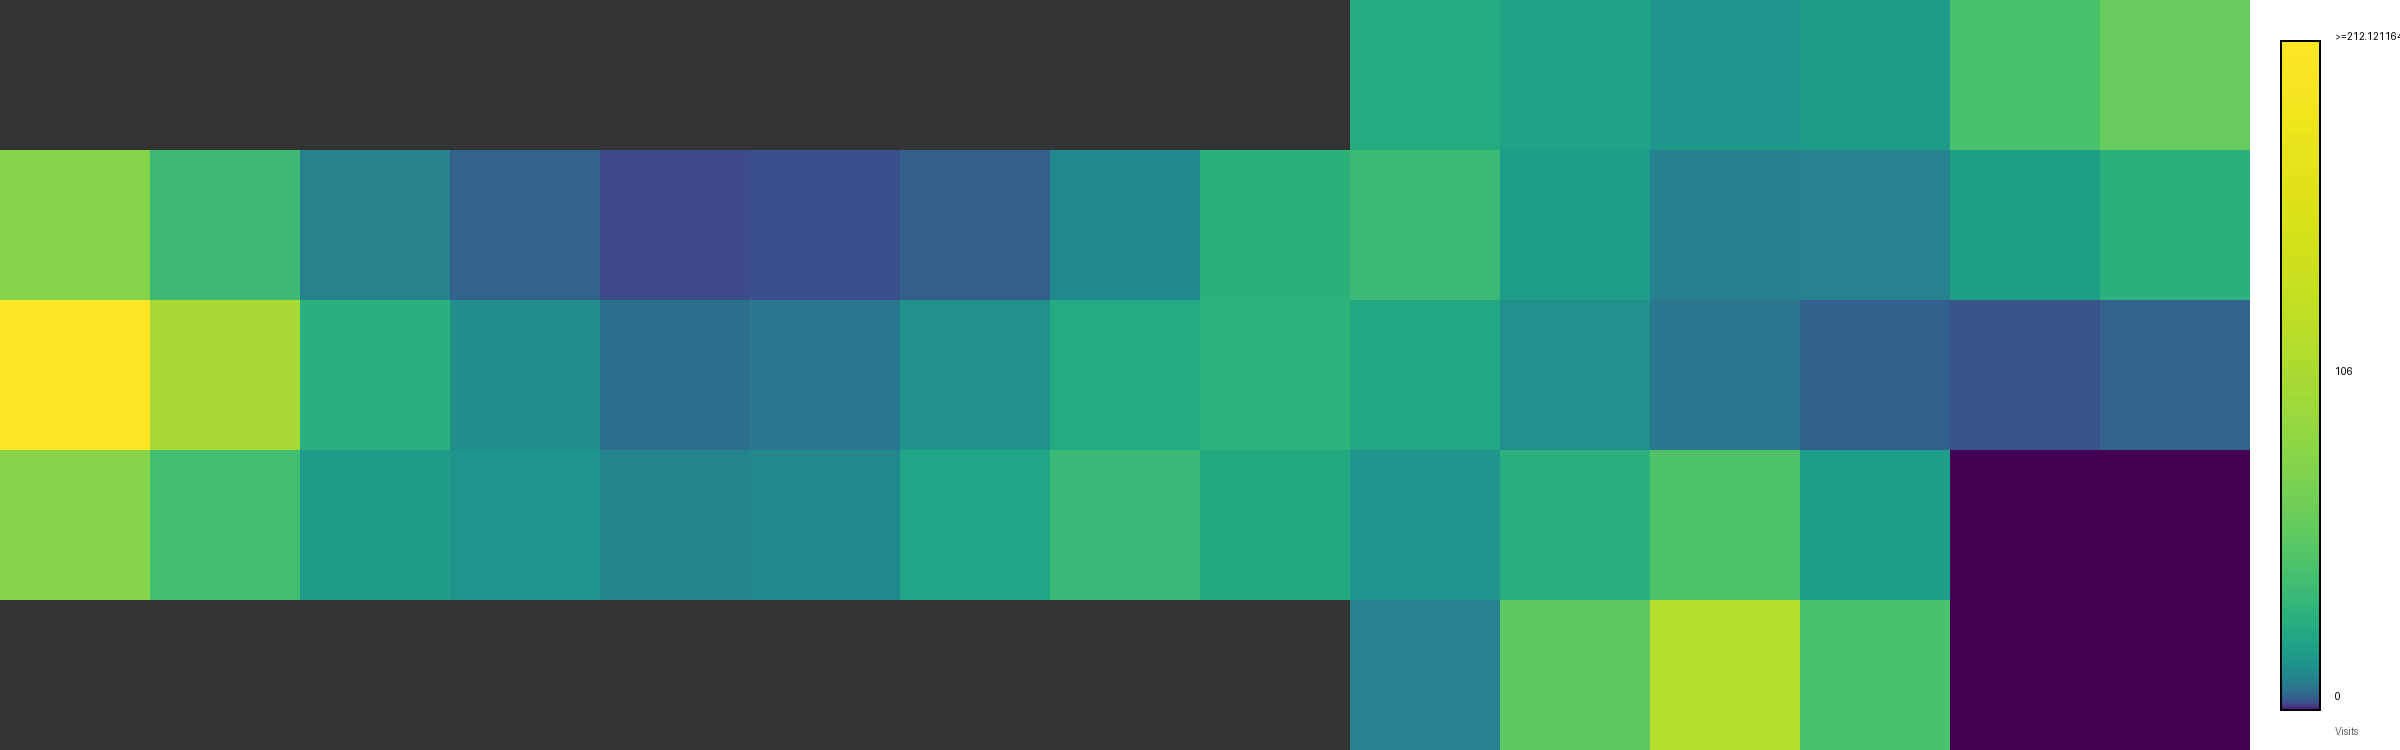

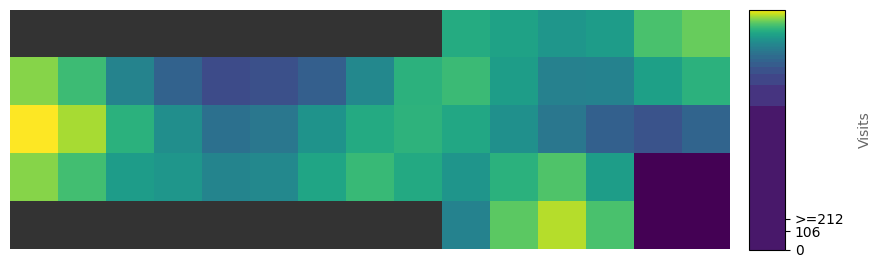

In [39]:
# max_v = max(max(Counter(trajectory_16_pre).values()), max(Counter(trajectory_16_post).values()))
counts_pre = list(Counter(trajectory_16_pre).values())
counts_post = list(Counter(trajectory_16_post).values())
all_counts = counts_pre + counts_post


data_driven_max = int(np.percentile(all_counts, 95)) 


max_v = data_driven_max
# max_v = 2000
thres = 1

sigma = 0.7
heatmap_16_pre1 = draw_heatmap_smoothed(trajectory_16_pre, saturation_threshold = thres, max_visits=None, smoothing_sigma=sigma)
# heatmap_16_post1 = draw_heatmap_smoothed(trajectory_16_post, saturation_threshold = thres, max_visits=None, smoothing_sigma=sigma)

heatmap_svg1 = draw_heatmap_matplotlib(trajectory_16_pre, rows, cols, 250, mask, idx_to_rc, c_wall, saturation_threshold = thres, max_visits=None, smoothing_sigma=sigma)
# diff_image = draw_difference_heatmap(trajectory_16_pre, trajectory_16_post)
# draw_heatmap_matplotlib(rows: Any, cols: Any, cell_size: Any, mask: Any, idx_to_rc: Any, c_wall: Any, saturation_threshold: float = 0.2, cmap: str = 'viridis', max_visits: Any)
# display(diff_image)

display(heatmap_16_pre1)
plt.show(heatmap_svg1)

/tmp/ipykernel_3062/665099826.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


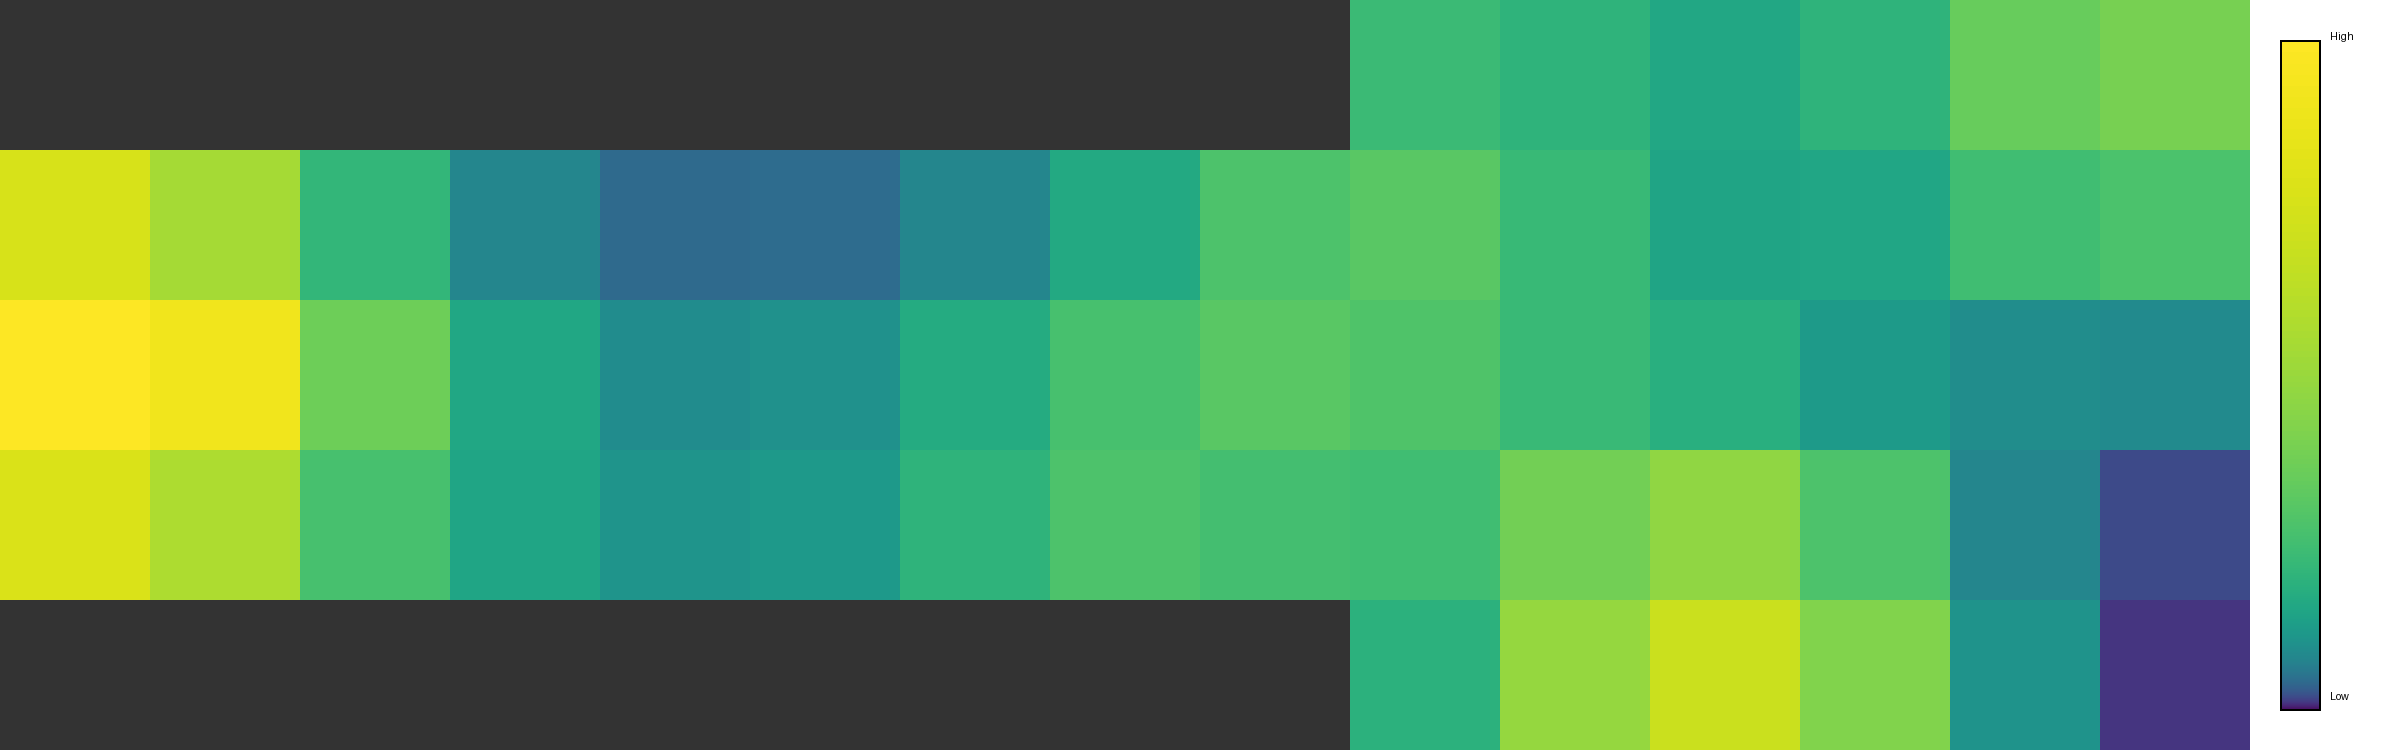

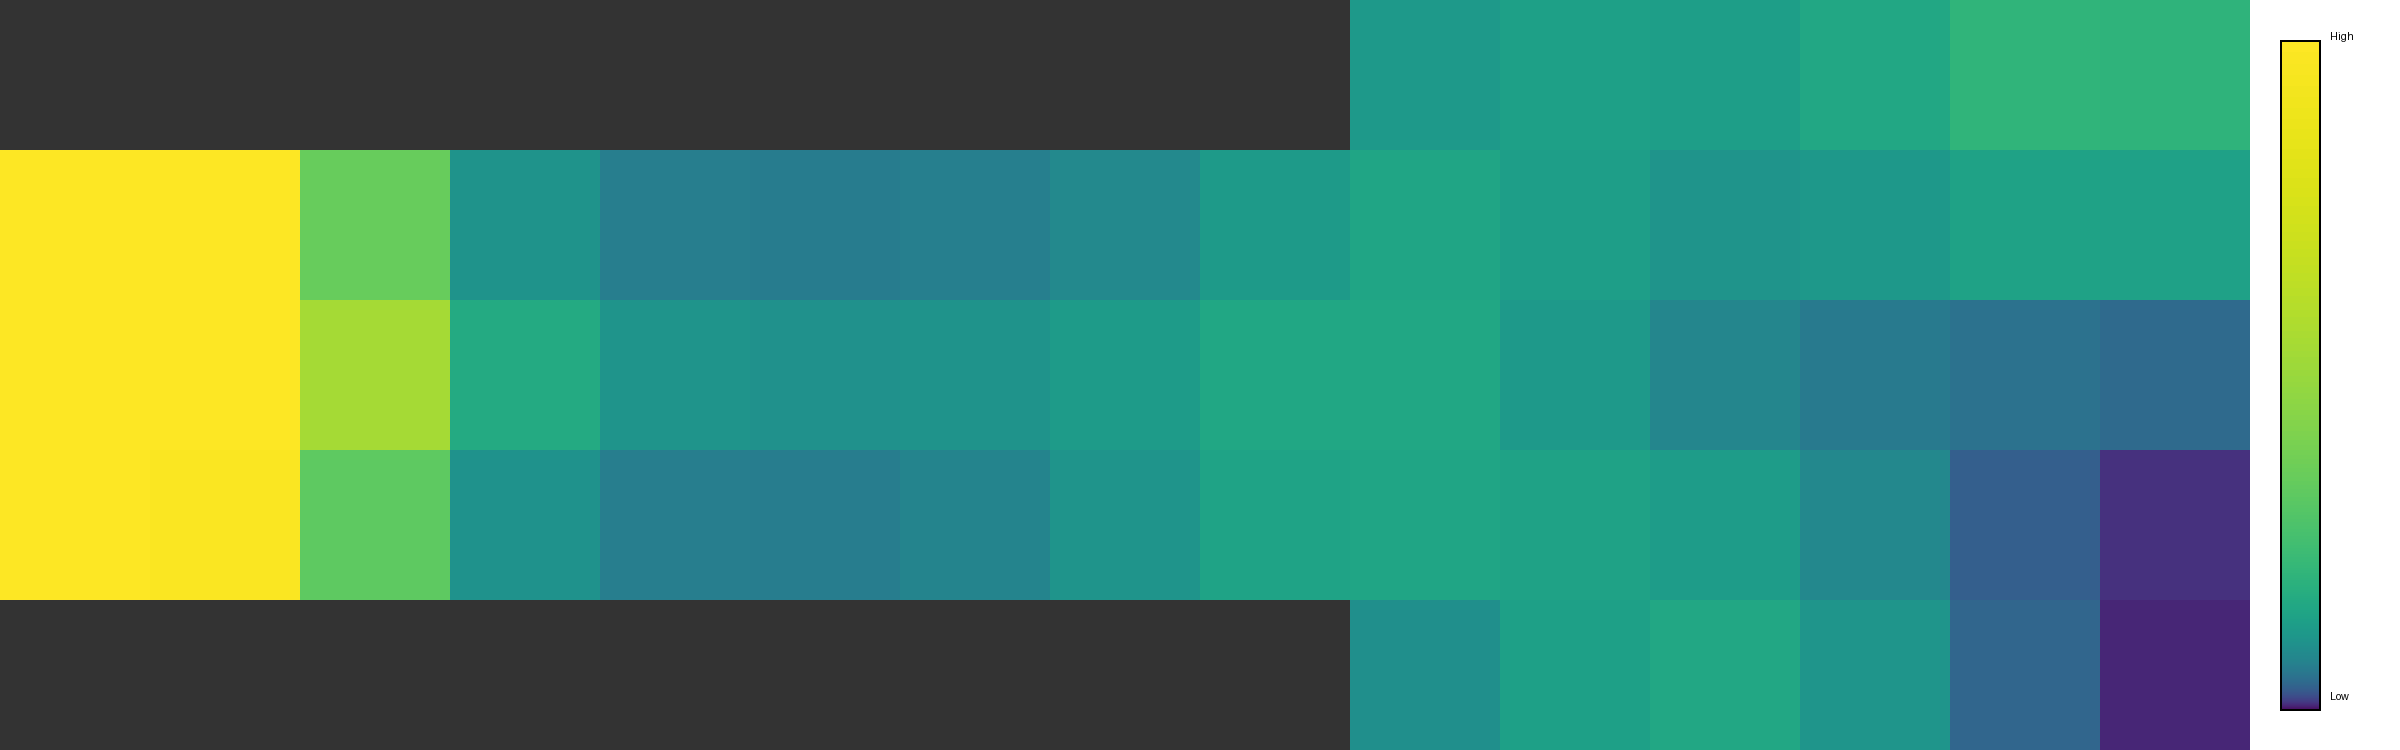

In [43]:
import numpy as np
import math
import matplotlib.cm as cm
from PIL import Image, ImageDraw, ImageFont
from collections import Counter
from scipy.ndimage import gaussian_filter

# --- Helper: Convert Trajectory to Smoothed Grid ---
def get_smoothed_density(traj, rows, cols, mask, idx_to_rc, sigma=1.0):
    # 1. Create empty grid
    grid = np.zeros((rows, cols), dtype=float)
    
    # 2. Fill with raw counts
    counts = Counter(traj)
    for idx, count in counts.items():
        r, c = idx_to_rc[idx]
        grid[r, c] = count

    # 3. Apply Gaussian Smoothing (The "Spread")
    if sigma > 0:
        grid = gaussian_filter(grid, sigma=sigma, mode='constant', cval=0)
        
    # 4. Re-apply Mask (Zero out walls so they don't glow)
    # Assumes mask is 1 for floor, 0 for wall
    grid = grid * mask 
    
    return grid

# --- Main Drawing Function ---
def draw_density_map(grid_data, max_val, cell_size=150, cmap='viridis'):
    rows, cols = grid_data.shape
    
    # 1. Setup Scaling
    # We use the provided max_val (calculated externally) for the color scale
    scale_max = max(max_val, 1e-5) # avoid div zero
    log_denominator = math.log(scale_max + 1)
    
    img = Image.new('RGB', (cols * cell_size, rows * cell_size), (51, 51, 51)) # c_wall
    draw = ImageDraw.Draw(img)
    colormap = cm.get_cmap(cmap)
    
    # 2. Draw Grid
    for r in range(rows):
        for c in range(cols):
            x0, y0 = c * cell_size, r * cell_size
            x1, y1 = x0 + cell_size, y0 + cell_size
            
            # Check mask (if value is 0 and it's a wall, keep it wall color)
            # We use the grid value itself to determine floor/wall loosely, 
            # or rely on the global mask variable if available.
            if mask[r,c] == 0:
                draw.rectangle([x0, y0, x1, y1], fill=(51,51,51))
            else:
                val = grid_data[r, c]
                # Clamp to max
                clamped_val = min(val, scale_max)
                
                # Log Transform
                intensity = math.log(clamped_val + 1) / log_denominator
                
                rgba = colormap(intensity)
                color = tuple(int(x*255) for x in rgba[:3])
                
                draw.rectangle([x0, y0, x1, y1], fill=color)

    # 3. Draw Legend (Simplified for Density)
    legend_width = 150
    legend = Image.new('RGB', (legend_width, img.height), (255,255,255))
    l_draw = ImageDraw.Draw(legend)
    
    # Draw Gradient Bar
    bar_x, bar_w, pad = 30, 40, 40
    bar_h = img.height - (pad * 2)
    
    for y in range(bar_h):
        prog = 1 - (y/bar_h)
        val = prog * scale_max
        intensity = math.log(val + 1) / log_denominator
        c = tuple(int(x*255) for x in colormap(intensity)[:3])
        l_draw.line([(bar_x, pad+y), (bar_x+bar_w, pad+y)], fill=c)
        
    l_draw.rectangle([bar_x, pad, bar_x+bar_w, pad+bar_h], outline=(0,0,0), width=2)
    
    # Labels
    try: font = ImageFont.truetype("arial.ttf", 24)
    except: font = ImageFont.load_default()
    
    # Since we smoothed, these aren't exact visit counts anymore, 
    # they are "Density" or "Activity" levels.
    l_draw.text((bar_x+bar_w+10, pad-10), f"High", fill=(0,0,0), font=font)
    l_draw.text((bar_x+bar_w+10, pad+bar_h-20), "Low", fill=(0,0,0), font=font)

    # Composite
    final = Image.new('RGB', (img.width + legend_width, img.height))
    final.paste(img, (0,0))
    final.paste(legend, (img.width, 0))
    
    return final

# --- EXECUTION: The Combined Method ---

# 1. Generate Smoothed Data Grids FIRST
# Sigma 0.8 is a sweet spot: clearly connects areas, but keeps shapes distinct
SIGMA = 1.0

grid_pre = get_smoothed_density(trajectory_16_pre, rows, cols, mask, idx_to_rc, sigma=SIGMA)
grid_post = get_smoothed_density(trajectory_16_post, rows, cols, mask, idx_to_rc, sigma=SIGMA)

# 2. Calculate Shared 95th Percentile
# We pool all active floor pixels from both maps to find the common "Max"
valid_pixels = np.concatenate([
    grid_pre[mask],  # Select only floor pixels
    grid_post[mask]
])

if len(valid_pixels) > 0:
    shared_max = np.percentile(valid_pixels, 95) # The "Bright Yellow" Threshold
else:
    shared_max = 1.0

# 3. Draw Both using the Shared Max
map_pre = draw_density_map(grid_pre, shared_max, cmap='viridis')
map_post = draw_density_map(grid_post, shared_max, cmap='viridis')

display(map_pre)
display(map_post)

/tmp/ipykernel_3062/2929508984.py:87: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


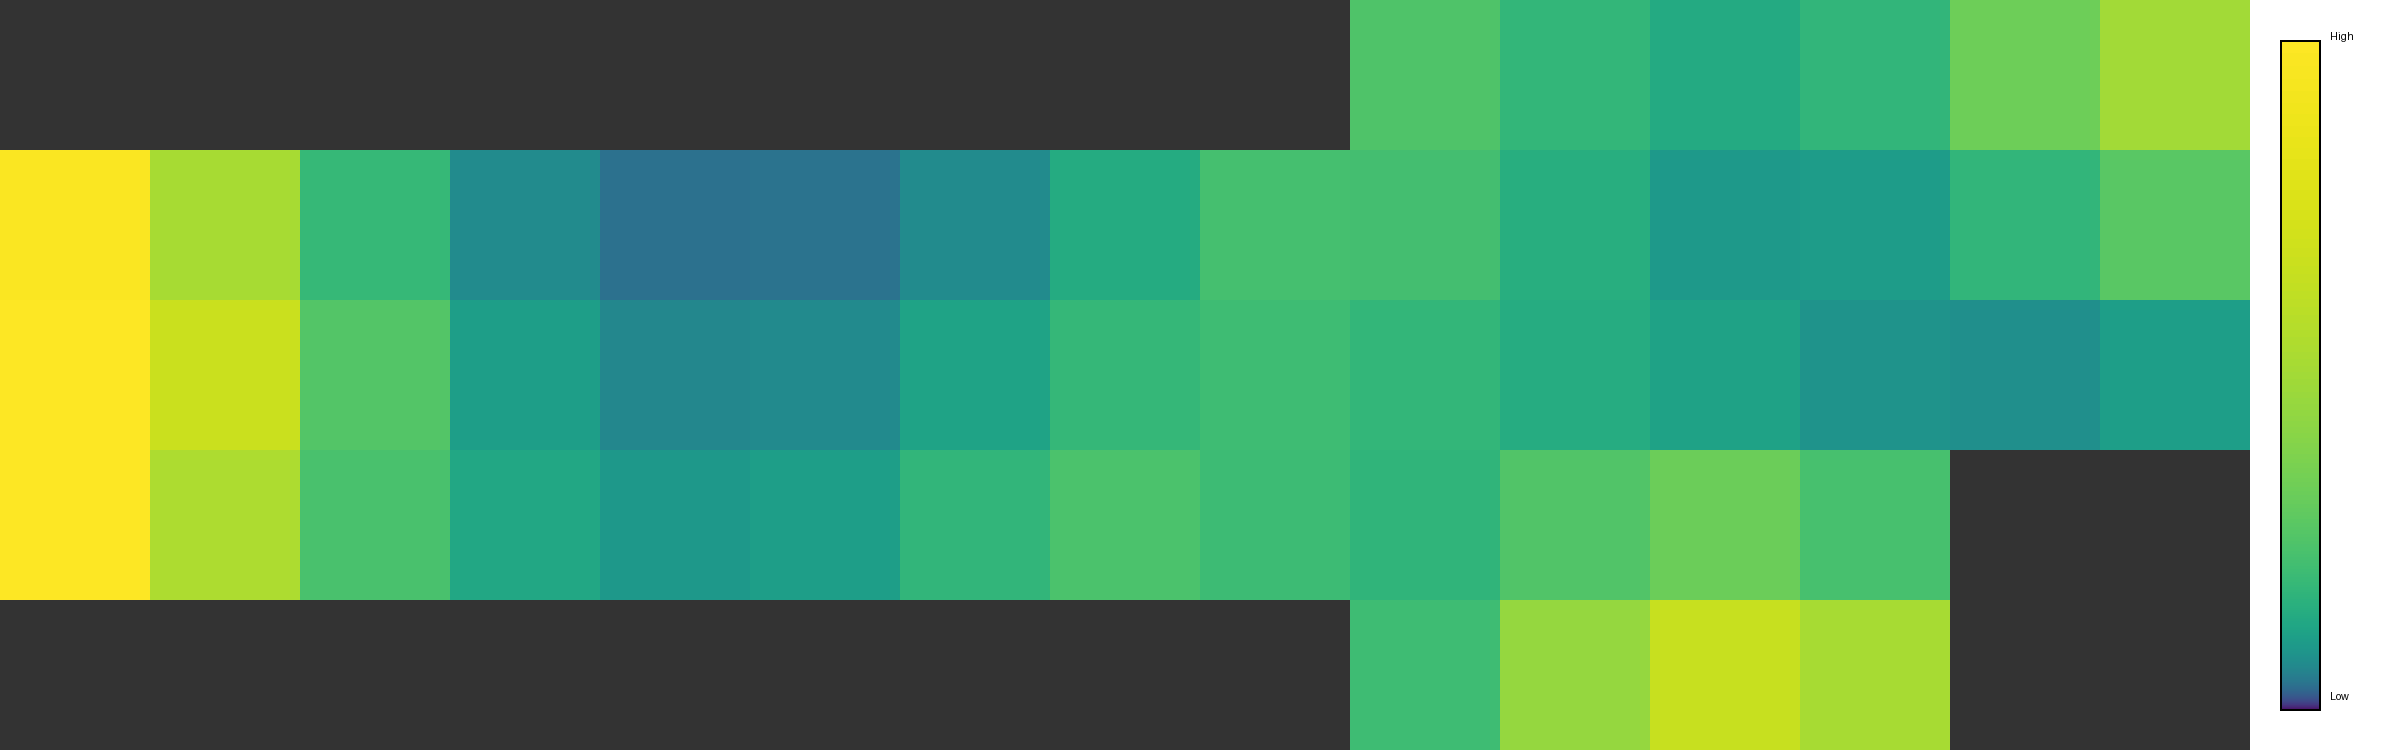

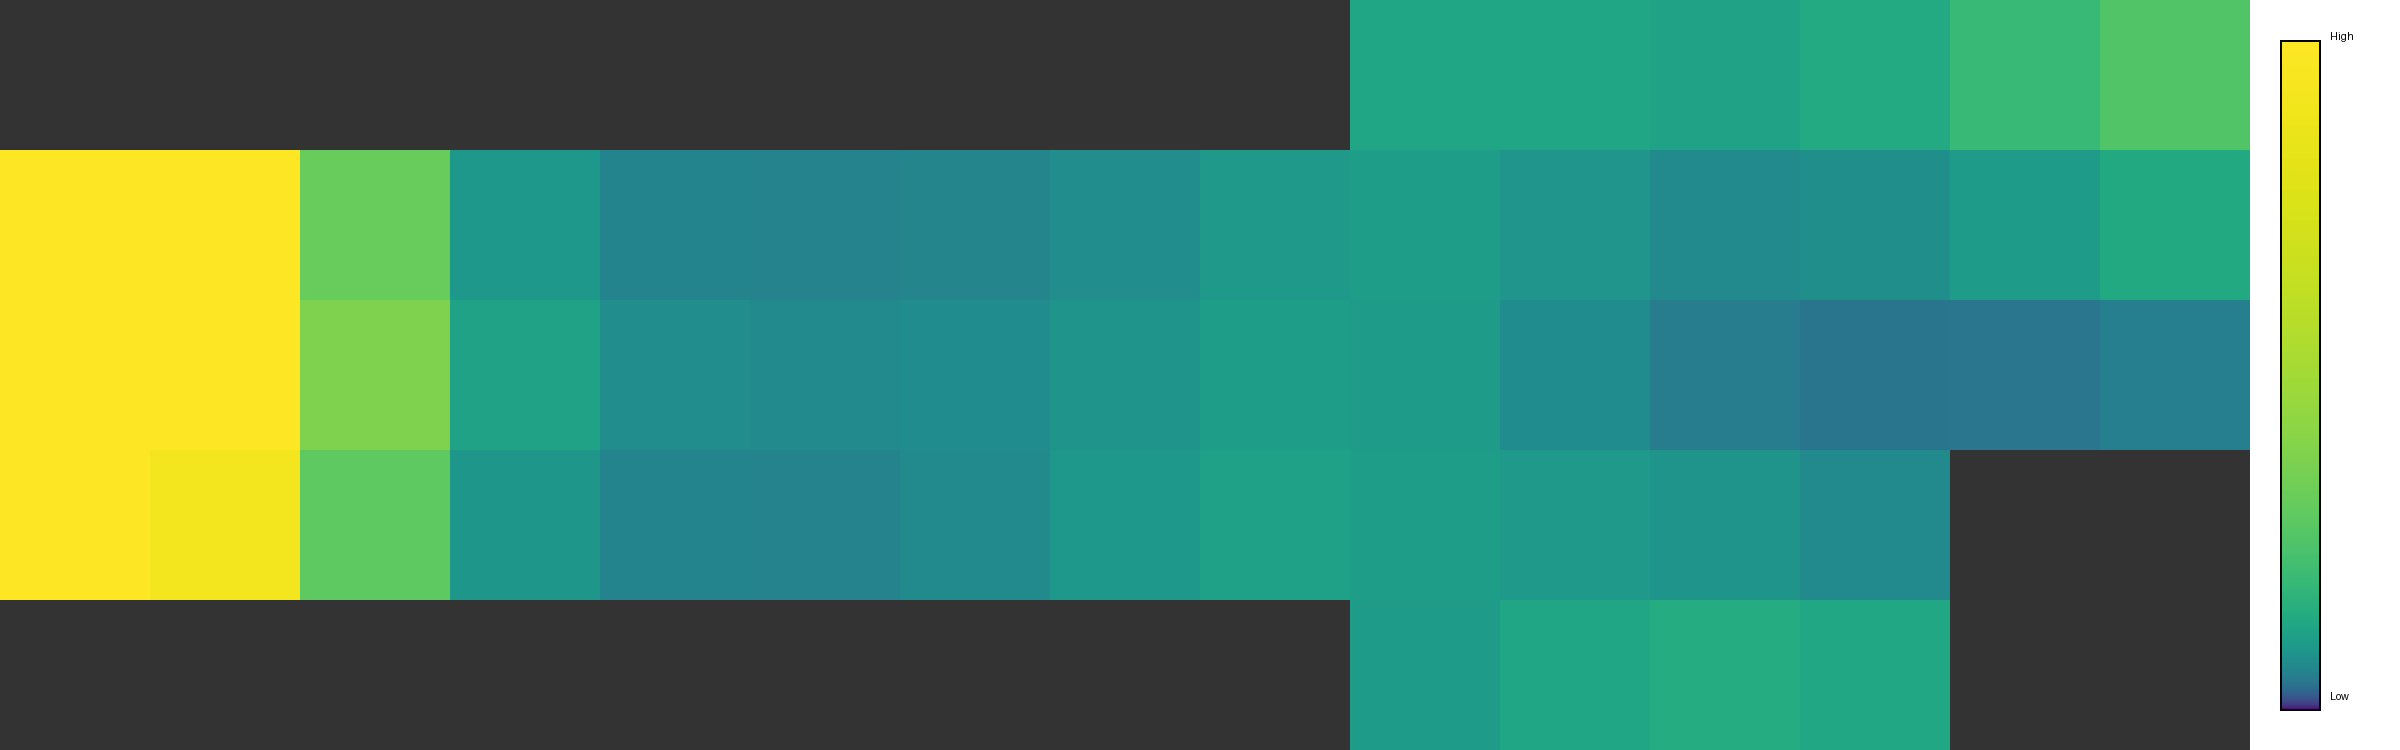

In [50]:
import numpy as np
import math
import matplotlib.cm as cm
from PIL import Image, ImageDraw, ImageFont
from collections import Counter
from scipy.ndimage import gaussian_filter

# --- 1. Define the Environment ---

# ORIGINAL MASK: Used to map your data indices correctly
# (Do not change this if your data indices depend on it)
data_mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

# RENDER MASK: The visual mask where we force the bottom-right to be walls.
render_mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,0,0]
], dtype=bool)



cell_size = 150
rows, cols = data_mask.shape
c_wall = (51, 51, 51)

# Map indices to (row, col) using the DATA mask
idx_to_rc = {}
counter = 0
for r in range(rows):
    for c in range(cols):
        if data_mask[r, c]:
            idx_to_rc[counter] = (r, c)
            counter += 1

# --- 2. Advanced Smoothing Function (Normalized) ---
def get_smoothed_density_normalized(traj, rows, cols, mask, idx_to_rc, sigma=1.0):
    """
    Calculates density while accounting for walls.
    'mask' determines which cells are valid for spreading heat.
    """
    # Initialize grid
    grid = np.zeros((rows, cols), dtype=float)
    counts = Counter(traj)
    
    # Fill grid (Only if the index maps to a valid location)
    for idx, count in counts.items():
        if idx in idx_to_rc:
            r, c = idx_to_rc[idx]
            # If our render_mask says this is now a wall, we ignore the visits here
            if mask[r, c]: 
                grid[r, c] = count

    if sigma > 0:
        # A. Smooth the Data
        smoothed_data = gaussian_filter(grid, sigma=sigma, mode='constant', cval=0)
        
        # B. Smooth the Mask (Calculates available floor area)
        # This prevents edge-darkening (vignetting) near walls
        smoothed_weights = gaussian_filter(mask.astype(float), sigma=sigma, mode='constant', cval=0)
        
        # C. Normalize
        with np.errstate(divide='ignore', invalid='ignore'):
            grid = smoothed_data / smoothed_weights
            grid[np.isnan(grid)] = 0
            
    # Final Crop: Ensure walls are strictly 0
    grid = grid * mask 
    return grid

# --- 3. Drawing Function ---
def draw_density_map(grid_data, max_val, mask, cell_size=150, cmap='viridis'):
    rows, cols = grid_data.shape
    scale_max = max(max_val, 1e-5)
    log_denominator = math.log(scale_max + 1)
    
    img = Image.new('RGB', (cols * cell_size, rows * cell_size), c_wall)
    draw = ImageDraw.Draw(img)
    colormap = cm.get_cmap(cmap)
    
    for r in range(rows):
        for c in range(cols):
            x0, y0 = c * cell_size, r * cell_size
            x1, y1 = x0 + cell_size, y0 + cell_size
            
            # If render_mask says it's a wall, draw dark gray
            if not mask[r, c]:
                draw.rectangle([x0, y0, x1, y1], fill=c_wall)
            else:
                val = grid_data[r, c]
                clamped_val = min(val, scale_max)
                intensity = math.log(clamped_val + 1) / log_denominator
                
                rgba = colormap(intensity)
                color = tuple(int(x*255) for x in rgba[:3])
                draw.rectangle([x0, y0, x1, y1], fill=color)

    # --- Draw Legend ---
    legend_width = 150
    legend = Image.new('RGB', (legend_width, img.height), (255,255,255))
    l_draw = ImageDraw.Draw(legend)
    
    bar_x, bar_w, pad = 30, 40, 40
    bar_h = img.height - (pad * 2)
    
    for y in range(bar_h):
        prog = 1 - (y/bar_h)
        val = prog * scale_max
        intensity = math.log(val + 1) / log_denominator
        c = tuple(int(x*255) for x in colormap(intensity)[:3])
        l_draw.line([(bar_x, pad+y), (bar_x+bar_w, pad+y)], fill=c)
        
    l_draw.rectangle([bar_x, pad, bar_x+bar_w, pad+bar_h], outline=(0,0,0), width=2)
    
    try: font = ImageFont.truetype("arial.ttf", 24)
    except: font = ImageFont.load_default()
    
    l_draw.text((bar_x+bar_w+10, pad-10), "High", fill=(0,0,0), font=font)
    l_draw.text((bar_x+bar_w+10, pad+bar_h-20), "Low", fill=(0,0,0), font=font)

    final = Image.new('RGB', (img.width + legend_width, img.height))
    final.paste(img, (0,0))
    final.paste(legend, (img.width, 0))
    
    return final

# --- 4. Execution ---

# A. Generate Smoothed Grids using RENDER_MASK
# Sigma 0.8 gives a clear "Region" look without losing detail
SIGMA = 1.0

grid_pre = get_smoothed_density_normalized(trajectory_16_pre, rows, cols, render_mask, idx_to_rc, sigma=SIGMA)
grid_post = get_smoothed_density_normalized(trajectory_16_post, rows, cols, render_mask, idx_to_rc, sigma=SIGMA)

# B. Calculate Shared 95th Percentile (Contrast Boost)
# We only look at pixels that are FLOOR in the RENDER mask
valid_pixels = np.concatenate([
    grid_pre[render_mask], 
    grid_post[render_mask]
])

if len(valid_pixels) > 0:
    shared_max = np.percentile(valid_pixels, 95)
else:
    shared_max = 1.0

# C. Draw
map_pre = draw_density_map(grid_pre, shared_max, render_mask, cmap='viridis')
map_post = draw_density_map(grid_post, shared_max, render_mask, cmap='viridis')

display(map_pre)
display(map_post)

<>:76: SyntaxWarning: invalid escape sequence '\s'
<>:147: SyntaxWarning: invalid escape sequence '\D'
<>:150: SyntaxWarning: invalid escape sequence '\D'
<>:76: SyntaxWarning: invalid escape sequence '\s'
<>:147: SyntaxWarning: invalid escape sequence '\D'
<>:150: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_8232/2180459290.py:76: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(io.StringIO(data_str), sep='\s+')
/tmp/ipykernel_8232/2180459290.py:147: SyntaxWarning: invalid escape sequence '\D'
  plot_violin_deltas(axes[0], delta_df, 'delta_investigation', '$\Delta$ Social Investigation', 'Change after defeat (Post - Pre)', direction='greater')
/tmp/ipykernel_8232/2180459290.py:150: SyntaxWarning: invalid escape sequence '\D'
  plot_violin_deltas(axes[1], delta_df, 'delta_shelter', '$\Delta$ Shelter Time', 'Change after defeat (Post - Pre)', direction='less')
/tmp/ipykernel_8232/2180459290.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is

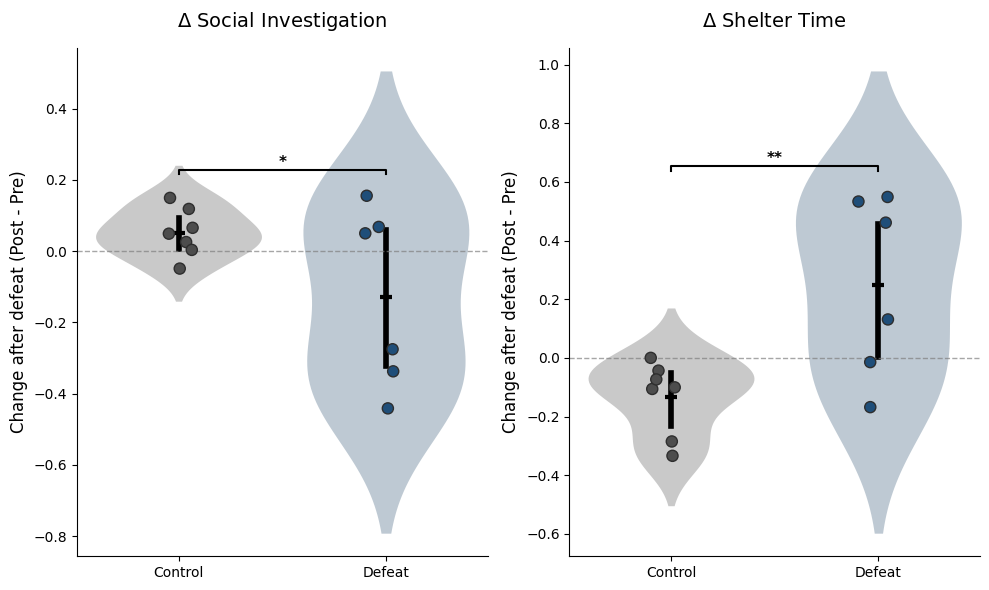

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import io
import seaborn as sns
from scipy import stats
import matplotlib as mpl

mpl.rcParams["svg.fonttype"] = "none"   # keep text as text
mpl.rcParams["text.usetex"] = False     # disable LaTeX text rendering


# 1. Load Data
# data_str = """
# mouse_number    phase    t_shelter    t_investigating
# 13    pre-defeat    0.5015    0.126
# 13    post-defeat    0.2165    0.2755
# 14    pre-defeat    0.4895    0.104
# 14    post-defeat    0.3215    0.2595
# 15    pre-defeat    0.688    0.0825
# 15    post-defeat    0.354    0.1315
# 16    pre-defeat    0.1445    0.387
# 16    post-defeat    0.6055    0.1115
# 17    pre-defeat    0.4405    0.2235
# 17    post-defeat    0.426    0.2915
# 18    pre-defeat    0.4175    0.1405
# 18    post-defeat    0.317    0.206
# 19    pre-defeat    0.2555    0.211
# 19    post-defeat    0.5945    0.046
# 20    pre-defeat    0.1435    0.3655
# 20    post-defeat    0.1    0.391
# 21    pre-defeat    0.241    0.483
# 21    post-defeat    0.135    0.434
# 22    pre-defeat    0.2155    0.139
# 22    post-defeat    0.142    0.2575
# 23    pre-defeat    0.1945    0.3365
# 23    post-defeat    0.3255    0.3865
# 24    pre-defeat    0.09    0.559
# 24    post-defeat    0.6385    0.1175
# 25    pre-defeat    0.127    0.5135
# 25    post-defeat    0.127    0.517
# 26    pre-defeat    0.291    0.3945
# 26    post-defeat    0.824    0.057
# """

data_str = """
mouse_number    phase    t_shelter    t_investigating
13    pre-defeat    0.5015    0.126
13    post-defeat    0.2165    0.2755
14    pre-defeat    0.4895    0.104
14    post-defeat    0.3215    0.2595
15    pre-defeat    0.688    0.0825
15    post-defeat    0.354    0.1315
16    pre-defeat    0.1445    0.387
16    post-defeat    0.6055    0.1115
17    pre-defeat    0.4405    0.2235
17    post-defeat    0.426    0.2915
18    pre-defeat    0.4175    0.1405
18    post-defeat    0.317    0.206
20    pre-defeat    0.1435    0.3655
20    post-defeat    0.1    0.391
21    pre-defeat    0.241    0.483
21    post-defeat    0.135    0.434
22    pre-defeat    0.2155    0.139
22    post-defeat    0.142    0.2575
23    pre-defeat    0.1945    0.3365
23    post-defeat    0.3255    0.3865
24    pre-defeat    0.09    0.559
24    post-defeat    0.6385    0.1175
25    pre-defeat    0.127    0.5135
25    post-defeat    0.127    0.517
26    pre-defeat    0.291    0.3945
26    post-defeat    0.824    0.057
"""

df = pd.read_csv(io.StringIO(data_str), sep='\s+')

# 2. Assign Groups
control_ids = [13, 15, 18, 20, 21, 22, 25]
defeat_ids = [14, 16, 17, 19, 23, 24, 26]
df['group'] = df['mouse_number'].apply(lambda x: 'Control' if x in control_ids else 'Defeat')

# 3. Calculate Deltas
pivot_df = df.pivot(index=['mouse_number', 'group'], columns='phase', values=['t_investigating', 't_shelter'])
delta_df = pd.DataFrame()
delta_df['delta_investigation'] = pivot_df[('t_investigating', 'post-defeat')] - pivot_df[('t_investigating', 'pre-defeat')]
delta_df['delta_shelter'] = pivot_df[('t_shelter', 'post-defeat')] - pivot_df[('t_shelter', 'pre-defeat')]
delta_df = delta_df.reset_index()

# 4. Statistical Function (One-Tailed Unpaired T-test)
def add_stat_annotation(ax, data, col, x1, x2, direction='greater'):
    """
    direction='greater' checks if Control > Defeat (e.g. Investigation where Defeat drops)
    direction='less' checks if Control < Defeat (e.g. Shelter where Defeat rises)
    """
    group_ctrl = data[data['group'] == 'Control'][col]
    group_def = data[data['group'] == 'Defeat'][col]
    
    # One-Tailed Unpaired T-test
    # We use 'alternative' to specify the hypothesis
    t_stat, p_val = stats.ttest_ind(group_ctrl, group_def, alternative=direction)
    
    # Define label
    if p_val > 0.05: label = f"ns"
    elif p_val > 0.01: label = f"*"
    elif p_val > 0.001: label = f"**"
    else: label = "***"
    
    # Draw bracket
    y_max = max(data[col].max(), group_def.max())
    y_min = min(data[col].min(), group_def.min())
    y_range = y_max - y_min
    
    y_h = y_max + 0.1 * y_range 
    h = 0.02 * y_range
    
    ax.plot([x1, x1, x2, x2], [y_h, y_h + h, y_h + h, y_h], lw=1.5, c='k')
    ax.text((x1 + x2) * .5, y_h + h, label, ha='center', va='bottom', color='k', fontsize=11, fontweight='bold')

# 5. Plotting
def plot_violin_deltas(ax, data, metric_col, title, y_label, direction):
    palette = {'Control': '#4D4D4D', 'Defeat': '#1F4E79'}
    
    # Violin
    sns.violinplot(x='group', y=metric_col, data=data, ax=ax, palette=palette, inner=None, alpha=0.3, linewidth=0)
    # Points
    sns.stripplot(x='group', y=metric_col, data=data, ax=ax, palette=palette, size=8, jitter=True, edgecolor='gray', linewidth=1)
    # Mean
    sns.pointplot(x='group', y=metric_col, data=data, ax=ax, estimator=np.mean, color='black', markers="_", scale=1.5, join=False)
    # Zero line
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    
    # Add One-Tailed Stats
    add_stat_annotation(ax, data, metric_col, 0, 1, direction=direction)

    # Formatting
    ax.set_title(title, fontsize=14, fontweight='normal', pad=15)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_xlabel('')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 6. Generate Figure
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Investigation: Hypothesis is Control > Defeat (Defeat decreases), so 'greater'
plot_violin_deltas(axes[0], delta_df, 'delta_investigation', '$\Delta$ Social Investigation', 'Change after defeat (Post - Pre)', direction='greater')

# Shelter: Hypothesis is Control < Defeat (Defeat increases), so 'less'
plot_violin_deltas(axes[1], delta_df, 'delta_shelter', '$\Delta$ Shelter Time', 'Change after defeat (Post - Pre)', direction='less')

plt.tight_layout()
plt.savefig(
    "figure.svg",
    format="svg",
    bbox_inches="tight"
)
plt.show()


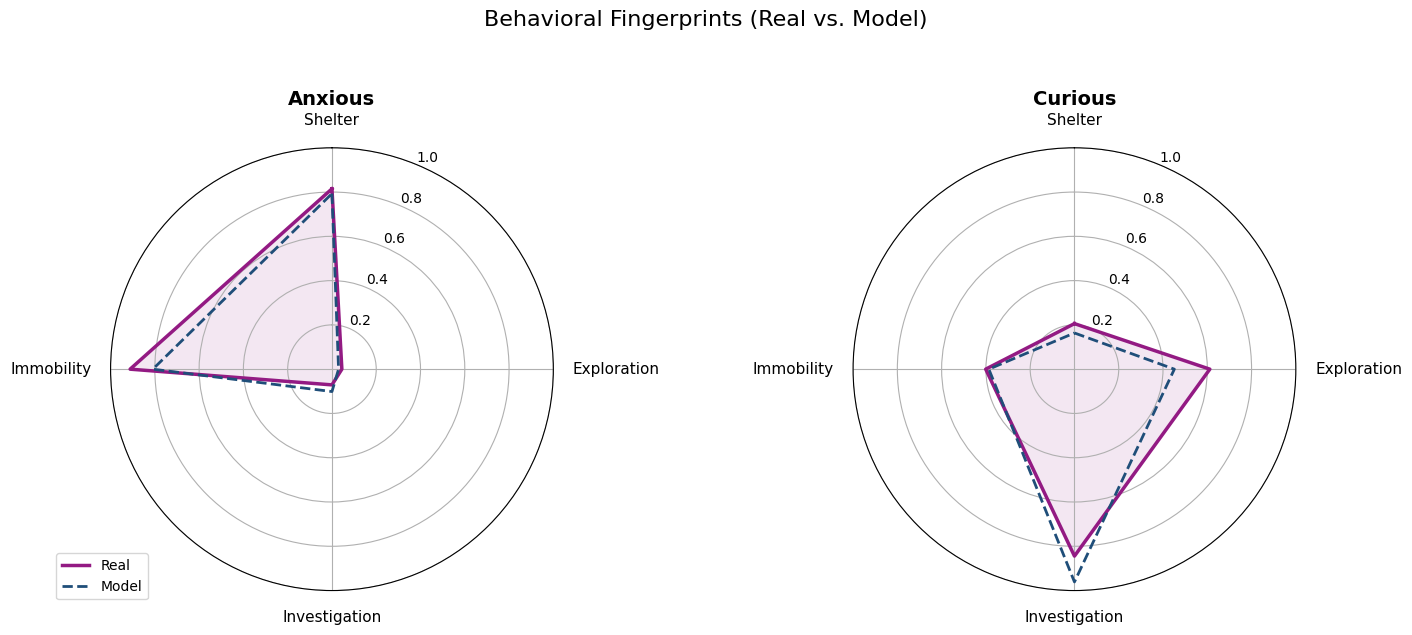

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Metrics
metrics = ['Shelter', 'Exploration', 'Investigation', 'Immobility']
num_vars = len(metrics)

# Data normalization parameters
minlist = np.array([0.09, 2.53, 0.046, 0.7305])
maxlist = np.array([0.824, 5.212, 0.56, 0.94])
std = maxlist - minlist

# Mouse data (Real)
real_m1 = [0.688, 2.65, 0.0825, 0.9215]
real_m1_norm = (real_m1 - minlist) / std

real_m2 = [0.241, 4.17, 0.48, 0.8145]
real_m2_norm = (real_m2 - minlist) / std

# Model data
model_data = [{'Mouse': 'Anxious', 'Values': [0.672, 2.61, 0.098, 0.9]}, 
              {'Mouse': 'Curious', 'Values': [0.21, 3.74, 0.54, 0.8115]}]

# Helper to close the loop
def close_loop(data):
    return np.concatenate((data, [data[0]]))

# Compute angles
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
angles_closed = np.concatenate((angles, [angles[0]]))

fig1, axes = plt.subplots(1, 2, figsize=(15, 6), subplot_kw=dict(polar=True))
fig1.suptitle('Behavioral Fingerprints (Real vs. Model)', fontsize=16, y=1.05)

mice_list = [('Anxious', real_m1_norm), ('Curious', real_m2_norm)]

for ax, (name, real_vals) in zip(axes.flat, mice_list):
    # (1) SET ORDER: Rotate so Shelter is at top and sequence is clockwise
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    
    # 1. Plot Real Data
    ax.plot(angles_closed, close_loop(real_vals), color='#931A83', linewidth=2.5, label='Real')
    ax.fill(angles_closed, close_loop(real_vals), color='#931A83', alpha=0.1)
    
    # 2. Plot Model Mean
    m_runs = [d['Values'] for d in model_data if d['Mouse'] == name]
    m_mean = (np.mean(m_runs, axis=0) - minlist) / std
    ax.plot(angles_closed, close_loop(m_mean), color="#1F4E79", linewidth=2, linestyle='--', label='Model')
    
    # (2) FIX CLASHING LABELS: Adjust alignment based on angle
    ax.set_xticks(angles)
    ax.set_xticklabels(metrics, fontsize=11)
    
    for label, angle in zip(ax.get_xticklabels(), angles):
        if angle == 0:
            label.set_verticalalignment('bottom')
            label.set_horizontalalignment('center')
        elif angle == np.pi/2: # Right side
            label.set_horizontalalignment('left')
        elif angle == np.pi: # Bottom
            label.set_verticalalignment('top')
            label.set_horizontalalignment('center')
        elif angle == 3*np.pi/2: # Left side
            label.set_horizontalalignment('right')

    ax.set_title(name, weight='bold', size=14, position=(0.5, 1.1))
    ax.set_ylim(0, 1)

# Add Legend
axes[0].legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.tight_layout()
plt.savefig('radar_chart.svg', format='svg', bbox_inches='tight')
plt.show()

In [57]:
from random_sim import random_metrics

rw_raw_dict = random_metrics(1000)
rw_raw_dict 

Setup complete
Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Thr

{'t_shelter': [0.107,
  0.1155,
  0.0185,
  0.071,
  0.03,
  0.08,
  0.028,
  0.0155,
  0.06,
  0.0605,
  0.082,
  0.063,
  0.096,
  0.0325,
  0.0485,
  0.03,
  0.0605,
  0.079,
  0.048,
  0.158,
  0.104,
  0.1585,
  0.042,
  0.0915,
  0.1025,
  0.032,
  0.0895,
  0.034,
  0.029,
  0.013,
  0.1105,
  0.0735,
  0.1315,
  0.1405,
  0.0065,
  0.0205,
  0.0735,
  0.1215,
  0.0985,
  0.0445,
  0.0685,
  0.1275,
  0.1105,
  0.031,
  0.0425,
  0.0135,
  0.133,
  0.0775,
  0.0485,
  0.0345,
  0.034,
  0.042,
  0.052,
  0.066,
  0.151,
  0.072,
  0.0245,
  0.073,
  0.0325,
  0.0805,
  0.025,
  0.0355,
  0.064,
  0.0885,
  0.0445,
  0.043,
  0.046,
  0.178,
  0.064,
  0.0155,
  0.0315,
  0.055,
  0.0545,
  0.05,
  0.1175,
  0.035,
  0.0435,
  0.1445,
  0.1295,
  0.078,
  0.105,
  0.0895,
  0.044,
  0.0505,
  0.0925,
  0.044,
  0.11,
  0.1105,
  0.026,
  0.052,
  0.049,
  0.03,
  0.0565,
  0.103,
  0.0385,
  0.1965,
  0.072,
  0.0675,
  0.1965,
  0.0565,
  0.0895,
  0.0495,
  0.068,
  0.076,
  0.

In [67]:
np.mean(rw_raw_dict['laziness'])

np.float64(0.343344)

<>:76: SyntaxWarning: invalid escape sequence '\s'
<>:77: SyntaxWarning: invalid escape sequence '\s'
<>:76: SyntaxWarning: invalid escape sequence '\s'
<>:77: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2669/4024787366.py:76: SyntaxWarning: invalid escape sequence '\s'
  df_real = pd.read_csv(io.StringIO(real_txt), sep='\s+')
/tmp/ipykernel_2669/4024787366.py:77: SyntaxWarning: invalid escape sequence '\s'
  df_sim = pd.read_csv(io.StringIO(sim_txt), sep='\s+')
/tmp/ipykernel_2669/4024787366.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=subset[subset['Type'].isin(['Random Walk', 'Model'])],
/tmp/ipykernel_2669/4024787366.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect

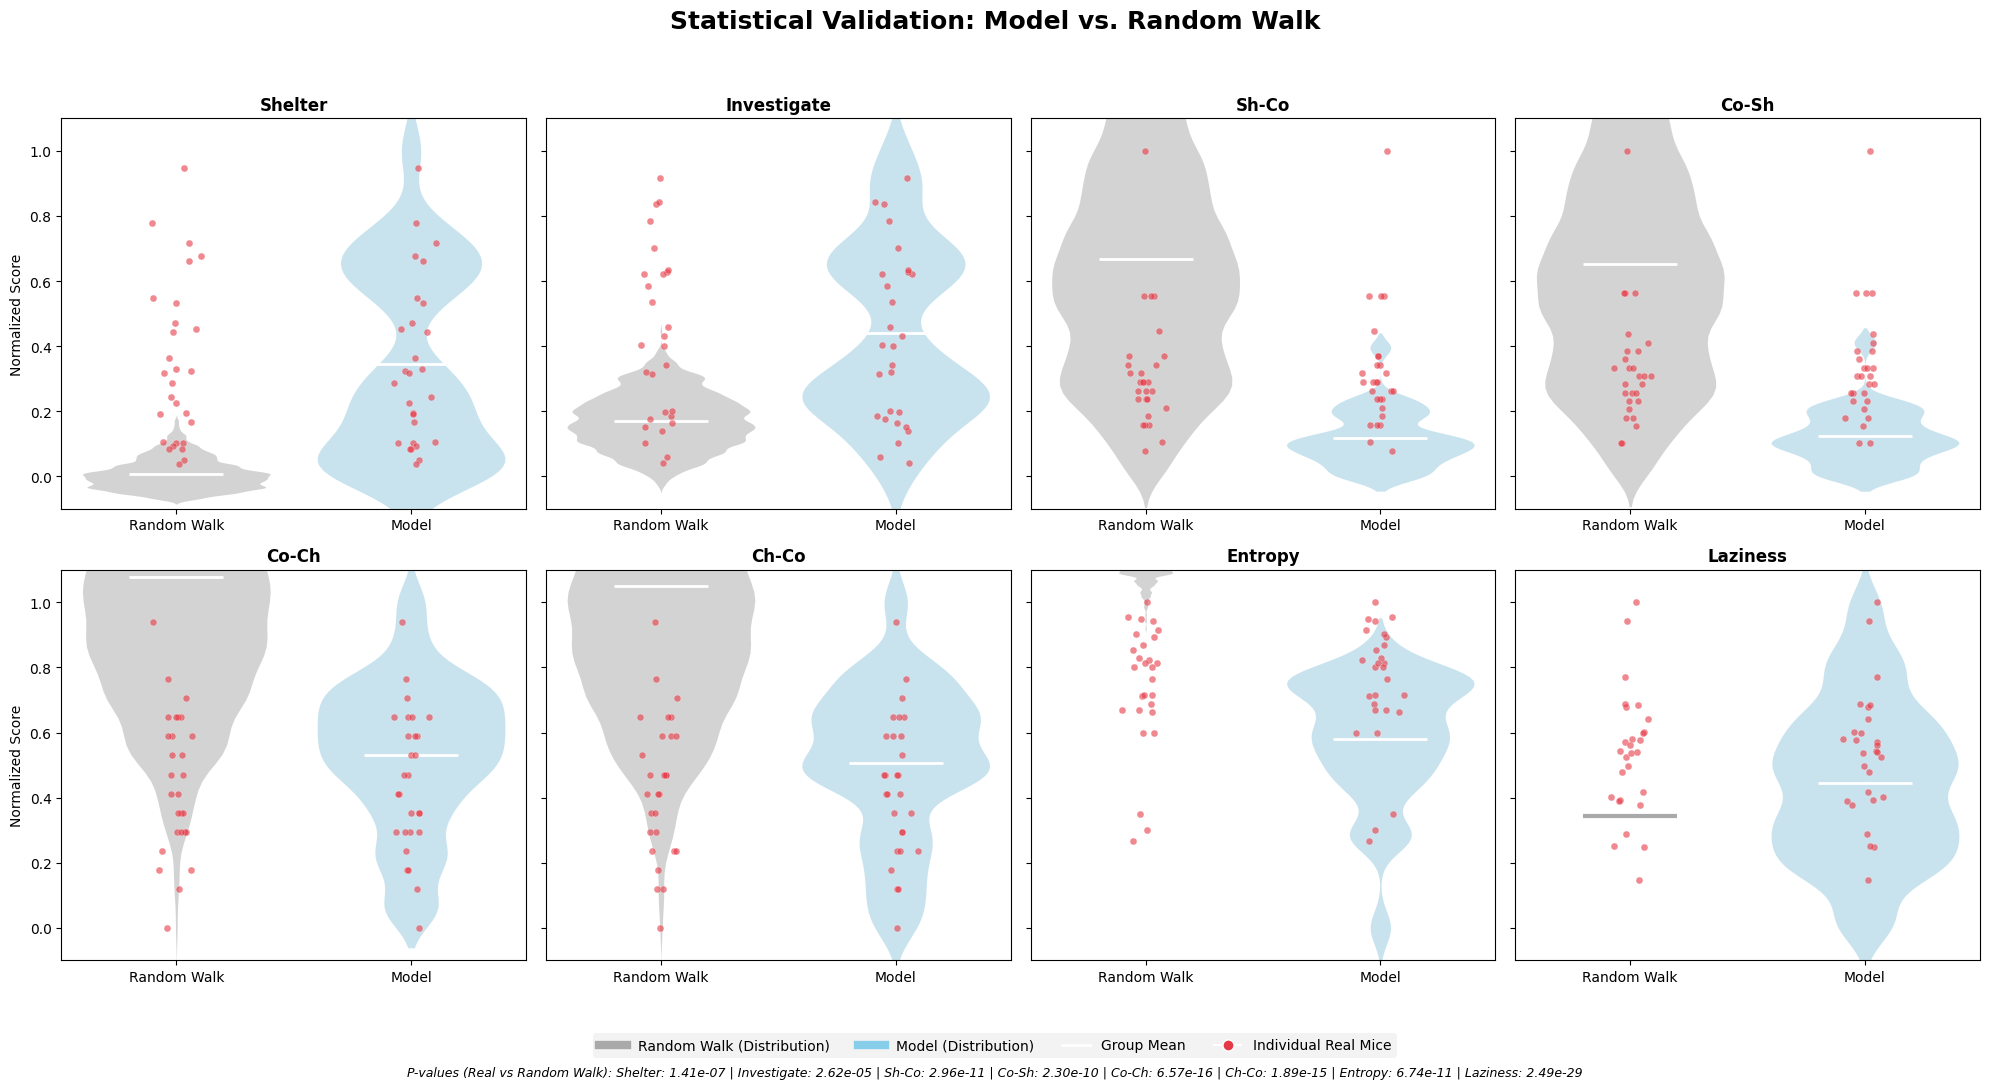

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import io
from scipy import stats
from matplotlib.patches import Patch

# ==========================================
# 1. DATA PARSING & PREPROCESSING
# ==========================================

real_txt = """mouse_number	phase	t_shelter	t_investigating	n_sh_co	n_co_sh	n_co_ch	n_ch_co	heatmap_entropy	laziness
13	pre-defeat	0.5015	0.126	9	9	8	8	4.157401889	0.8345
13	post-defeat	0.2165	0.2755	14	14	13	14	4.679772779	0.7895
14	pre-defeat	0.4895	0.104	13	13	9	9	3.746474719	0.8495
14	post-defeat	0.3215	0.2595	11	11	12	12	4.166432251	0.826
15	pre-defeat	0.688	0.0825	10	10	4	4	2.652491439	0.9215
15	post-defeat	0.354	0.1315	15	16	7	7	4.345699479	0.8325
16	pre-defeat	0.1445	0.387	7	6	7	6	4.487010226	0.81
16	post-defeat	0.6055	0.1115	11	10	11	10	2.828770281	0.8585
17	pre-defeat	0.4405	0.2235	7	7	8	9	4.068416593	0.8595
17	post-defeat	0.426	0.2915	8	8	5	6	3.74524117	0.8805
18	pre-defeat	0.4175	0.1405	22	22	13	13	4.564578899	0.8215
18	post-defeat	0.317	0.206	22	22	12	11	5.024379947	0.7955
19	pre-defeat	0.2555	0.21	10	10	18	18	5.211984137	0.755
19	post-defeat	0.5945	0.046	39	39	14	13	4.006918493	0.824
20	pre-defeat	0.1435	0.3655	12	12	13	13	4.824145152	0.7645
20	post-defeat	0.1	0.391	7	7	8	8	4.857023003	0.7555
21	pre-defeat	0.241	0.483	11	11	10	10	4.167765163	0.8145
21	post-defeat	0.135	0.434	12	12	11	10	4.72916643	0.7305
22	pre-defeat	0.2155	0.139	12	13	15	15	5.05205629	0.7885
22	post-defeat	0.142	0.2575	13	13	10	10	5.006154148	0.792
23	pre-defeat	0.1945	0.3365	12	12	12	12	4.903375069	0.786
23	post-defeat	0.3255	0.3865	18	17	13	12	4.532798358	0.8395
24	pre-defeat	0.09	0.559	10	9	7	6	3.979085758	0.8335
24	post-defeat	0.6385	0.1175	22	22	9	9	4.007712686	0.839
25	pre-defeat	0.127	0.5135	5	4	5	4	4.585052569	0.8605
25	post-defeat	0.127	0.517	4	4	6	5	4.527635349	0.83
26	pre-defeat	0.291	0.3945	14	15	7	7	4.48366893	0.825
26	post-defeat	0.824	0.057	15	15	2	2	2.535852912	0.9355
"""

sim_txt = """Name	metric_entropy	metric_laziness	metric_n_ch_co	metric_n_co_ch	metric_n_co_sh	metric_n_sh_co	metric_t_investigating	metric_t_shelter
13_def1	3.20400457	0.814	10	10	5	5	0.148	0.565
13_def3	4.395300543	0.756	12	12	7	8	0.195	0.221
14_def1	3.555217019	0.8525	9	9	2	3	0.0845	0.585
14_def3	3.901667725	0.8085	13	14	4	5	0.3685	0.228
15_def1	2.613338322	0.903	6	6	4	4	0.098	0.672
15_def3	3.022716129	0.783	13	13	9	10	0.147	0.5215
16_def1	3.984038799	0.7835	10	10	1	2	0.4275	0.07
16_def3	2.554980742	0.8475	10	11	5	6	0.173	0.6515
17_def1	3.195065402	0.8335	11	11	6	6	0.2345	0.5965
17_def3	2.602157206	0.8865	7	8	4	5	0.2735	0.5845
18_def1	3.433378673	0.775	15	15	8	8	0.1955	0.5645
18_def3	4.666456582	0.7555	11	12	7	8	0.1535	0.228
19_def1	4.296422916	0.7375	15	15	8	9	0.1535	0.3055
19_def3	3.695187819	0.695	19	19	16	16	0.182	0.4895
20_def1	4.177511677	0.7475	14	14	4	5	0.3715	0.0745
20_def3	4.439213218	0.7345	5	6	2	3	0.357	0.1065
21_def1	3.741922515	0.8115	13	13	5	5	0.5405	0.2105
21_def3	4.360964179	0.7055	13	13	4	4	0.4225	0.159
22_def1	4.296422916	0.7375	15	15	8	9	0.1535	0.3055
22_def3	4.281682272	0.8295	10	11	3	4	0.23	0.0975
23_def1	4.346072157	0.7715	13	14	3	4	0.403	0.104
23_def3	4.038996715	0.7665	16	17	9	10	0.475	0.3075
24_def1	3.464592897	0.858	4	5	0	1	0.6085	0.077
24_def3	3.340437851	0.8135	10	10	6	6	0.0745	0.6445
25_def1	3.755710101	0.882	2	3	0	1	0.4245	0.094
25_def3	3.6980664	0.835	7	8	0	1	0.55	0.06
26_def1	4.304864657	0.7995	11	12	1	2	0.41	0.1045
26_def3	1.555892085	0.932	3	3	3	3	0.0225	0.867
"""

# Load Dataframes
df_real = pd.read_csv(io.StringIO(real_txt), sep='\s+')
df_sim = pd.read_csv(io.StringIO(sim_txt), sep='\s+')

# Align Simulation column names with Real data
df_sim.columns = [c.replace('metric_', '') for c in df_sim.columns]
df_sim.rename(columns={'entropy': 'heatmap_entropy'}, inplace=True)

# Extract IDs for mapping
df_sim['mouse_number'] = df_sim['Name'].apply(lambda x: int(x.split('_')[0]))
df_sim['phase'] = df_sim['Name'].apply(lambda x: x.split('_')[1])

# Define exact metrics and display labels
metrics_raw = ['t_shelter', 't_investigating', 'n_sh_co', 'n_co_sh', 'n_co_ch', 'n_ch_co', 'heatmap_entropy', 'laziness']
display_metrics = ['Shelter', 'Investigate', 'Sh-Co', 'Co-Sh', 'Co-Ch', 'Ch-Co', 'Entropy', 'Laziness']
num_vars = len(metrics_raw)

# Normalization logic across all data types
combined_vals = pd.concat([df_real[metrics_raw], df_sim[metrics_raw]])
mins, maxs = combined_vals.min(), combined_vals.max()

def normalize_metrics(df):
    return (df[metrics_raw] - mins) / (maxs - mins)

df_real_norm = pd.concat([df_real[['mouse_number', 'phase']], normalize_metrics(df_real)], axis=1)
df_sim_norm = pd.concat([df_sim[['mouse_number', 'phase']], normalize_metrics(df_sim)], axis=1)

# --- C. Random Walk Data ---
# Map provided dictionary format to a normalized DataFrame
# rw_raw_dict = random_metrics(1000) 
df_rw = pd.DataFrame(rw_raw_dict)
# Handle potential name mismatches in random_metrics dictionary if they differ from metrics_raw
if 'entropy' in df_rw.columns and 'heatmap_entropy' not in df_rw.columns:
    df_rw.rename(columns={'entropy': 'heatmap_entropy'}, inplace=True)
df_rw_norm = normalize_metrics(df_rw)

# ==========================================
# 3. PLOT 2: COMPARATIVE VIOLIN PLOTS
# ==========================================

target_mice = list(zip(df_real['mouse_number'], df_real['phase']))

rows = []
for i, m_key in enumerate(metrics_raw):
    m_label = display_metrics[i]
    for v in df_rw_norm[m_key]:
        rows.append({'Metric': m_label, 'Value': v, 'Type': 'Random Walk'})
    for v in df_sim_norm[m_key]:
        rows.append({'Metric': m_label, 'Value': v, 'Type': 'Model'})
    for m_id, p_id in target_mice:
        match = df_real_norm[(df_real_norm['mouse_number'] == m_id) & (df_real_norm['phase'] == p_id)]
        if not match.empty:
            v = match[m_key].values[0]
            rows.append({'Metric': m_label, 'Value': v, 'Type': 'Real'})

df_viz = pd.DataFrame(rows)

# Styling
colors = {'Random Walk': '#A9A9A9', 'Model': '#87CEEB'} # Darker grey and SkyBlue
real_dot_color = '#E63946' # High-contrast red

fig2, axes2 = plt.subplots(2, 4, figsize=(20, 11), sharey=True)
fig2.suptitle('Statistical Validation: Model vs. Random Walk', fontsize=18, y=0.98, fontweight='bold')

p_values = {}

# ==========================================
# 3. PLOT 2: COMPARATIVE VIOLIN PLOTS
# ==========================================

# Use the same df_viz and setup from before...

for i, m_label in enumerate(display_metrics):
    m_key = metrics_raw[i]
    ax = axes2.flat[i]
    subset = df_viz[df_viz['Metric'] == m_label]
    
    # 1. STATS: Compare Real vs Random Walk
    real_vals = subset[subset['Type'] == 'Real']['Value'].values
    rw_vals = subset[subset['Type'] == 'Random Walk']['Value'].values
    t_stat, p_val = stats.ttest_ind(real_vals, rw_vals, equal_var=False)
    p_values[m_label] = p_val

    # 2. Draw Violins
    sns.violinplot(data=subset[subset['Type'].isin(['Random Walk', 'Model'])], 
                   x='Type', y='Value', palette=colors, ax=ax, 
                   inner=None, linewidth=0, alpha=0.5, 
                   density_norm='width', bw_adjust=0.5)

    if m_key == 'laziness':
        rw_mean = 0.343344
        # Draw a darker, thicker line to represent the "collapsed" distribution
        ax.hlines(y=rw_mean, xmin=-0.2, xmax=0.2, color='#A9A9A9', 
                  linewidth=3, zorder=5)


    # 4. Add custom white MEAN lines (for both)
    for j, t_type in enumerate(['Random Walk', 'Model']):
        m_val = subset[subset['Type'] == t_type]['Type_Value' if 'Type_Value' in subset else 'Value'].mean()
        ax.hlines(y=m_val, xmin=j-0.2, xmax=j+0.2, color='white', linestyle='-', linewidth=2, zorder=5)

    # 5. Plot Real mice over BOTH columns
    ax.scatter(x=np.random.normal(0, 0.04, size=len(real_vals)), 
               y=real_vals, c=real_dot_color, s=25, zorder=10, 
               edgecolors='white', linewidth=0.3, alpha=0.6)
    
    ax.scatter(x=np.random.normal(1, 0.04, size=len(real_vals)), 
               y=real_vals, c=real_dot_color, s=25, zorder=10, 
               edgecolors='white', linewidth=0.3, alpha=0.6)

    ax.set_title(m_label, fontweight='bold', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Normalized Score' if i % 4 == 0 else '')
    ax.set_ylim(-0.1, 1.1)

# [Remaining legend and saving code...]

# 5. FIX: Better P-Value Formatting (Scientific Notation for small values)
p_strings = []
for k, v in p_values.items():
    if v < 0.001:
        p_strings.append(f"{k}: {v:.2e}") # Scientific notation
    else:
        p_strings.append(f"{k}: {v:.4f}")

caption_text = "P-values (Real vs Random Walk): " + " | ".join(p_strings)
fig2.text(0.5, 0.01, caption_text, ha='center', fontsize=9, style='italic', wrap=True)

# Legend [Same as before]
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#A9A9A9', lw=6, label='Random Walk (Distribution)'),
    Line2D([0], [0], color='#87CEEB', lw=6, label='Model (Distribution)'),
    Line2D([0], [0], color='white', lw=2, label='Group Mean'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=real_dot_color, markersize=8, label='Individual Real Mice')
]

# fig2.legend(handles=legend_elements, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0.02), frameon=False)
fig2.legend(handles=legend_elements, 
            loc='lower center', 
            ncol=4, 
            bbox_to_anchor=(0.5, 0.02), 
            frameon=True,         # Turn the frame back on
            facecolor='#f0f0f0',  # Light grey background
            edgecolor='none')     # Hide the box border if you don't like it

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
# plt.savefig("model_validation_final.svg", format='svg', bbox_inches='tight')
plt.show()

<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2669/1263009919.py:40: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(io.StringIO(sim_txt), sep='\s+')


Plotting Control Group...


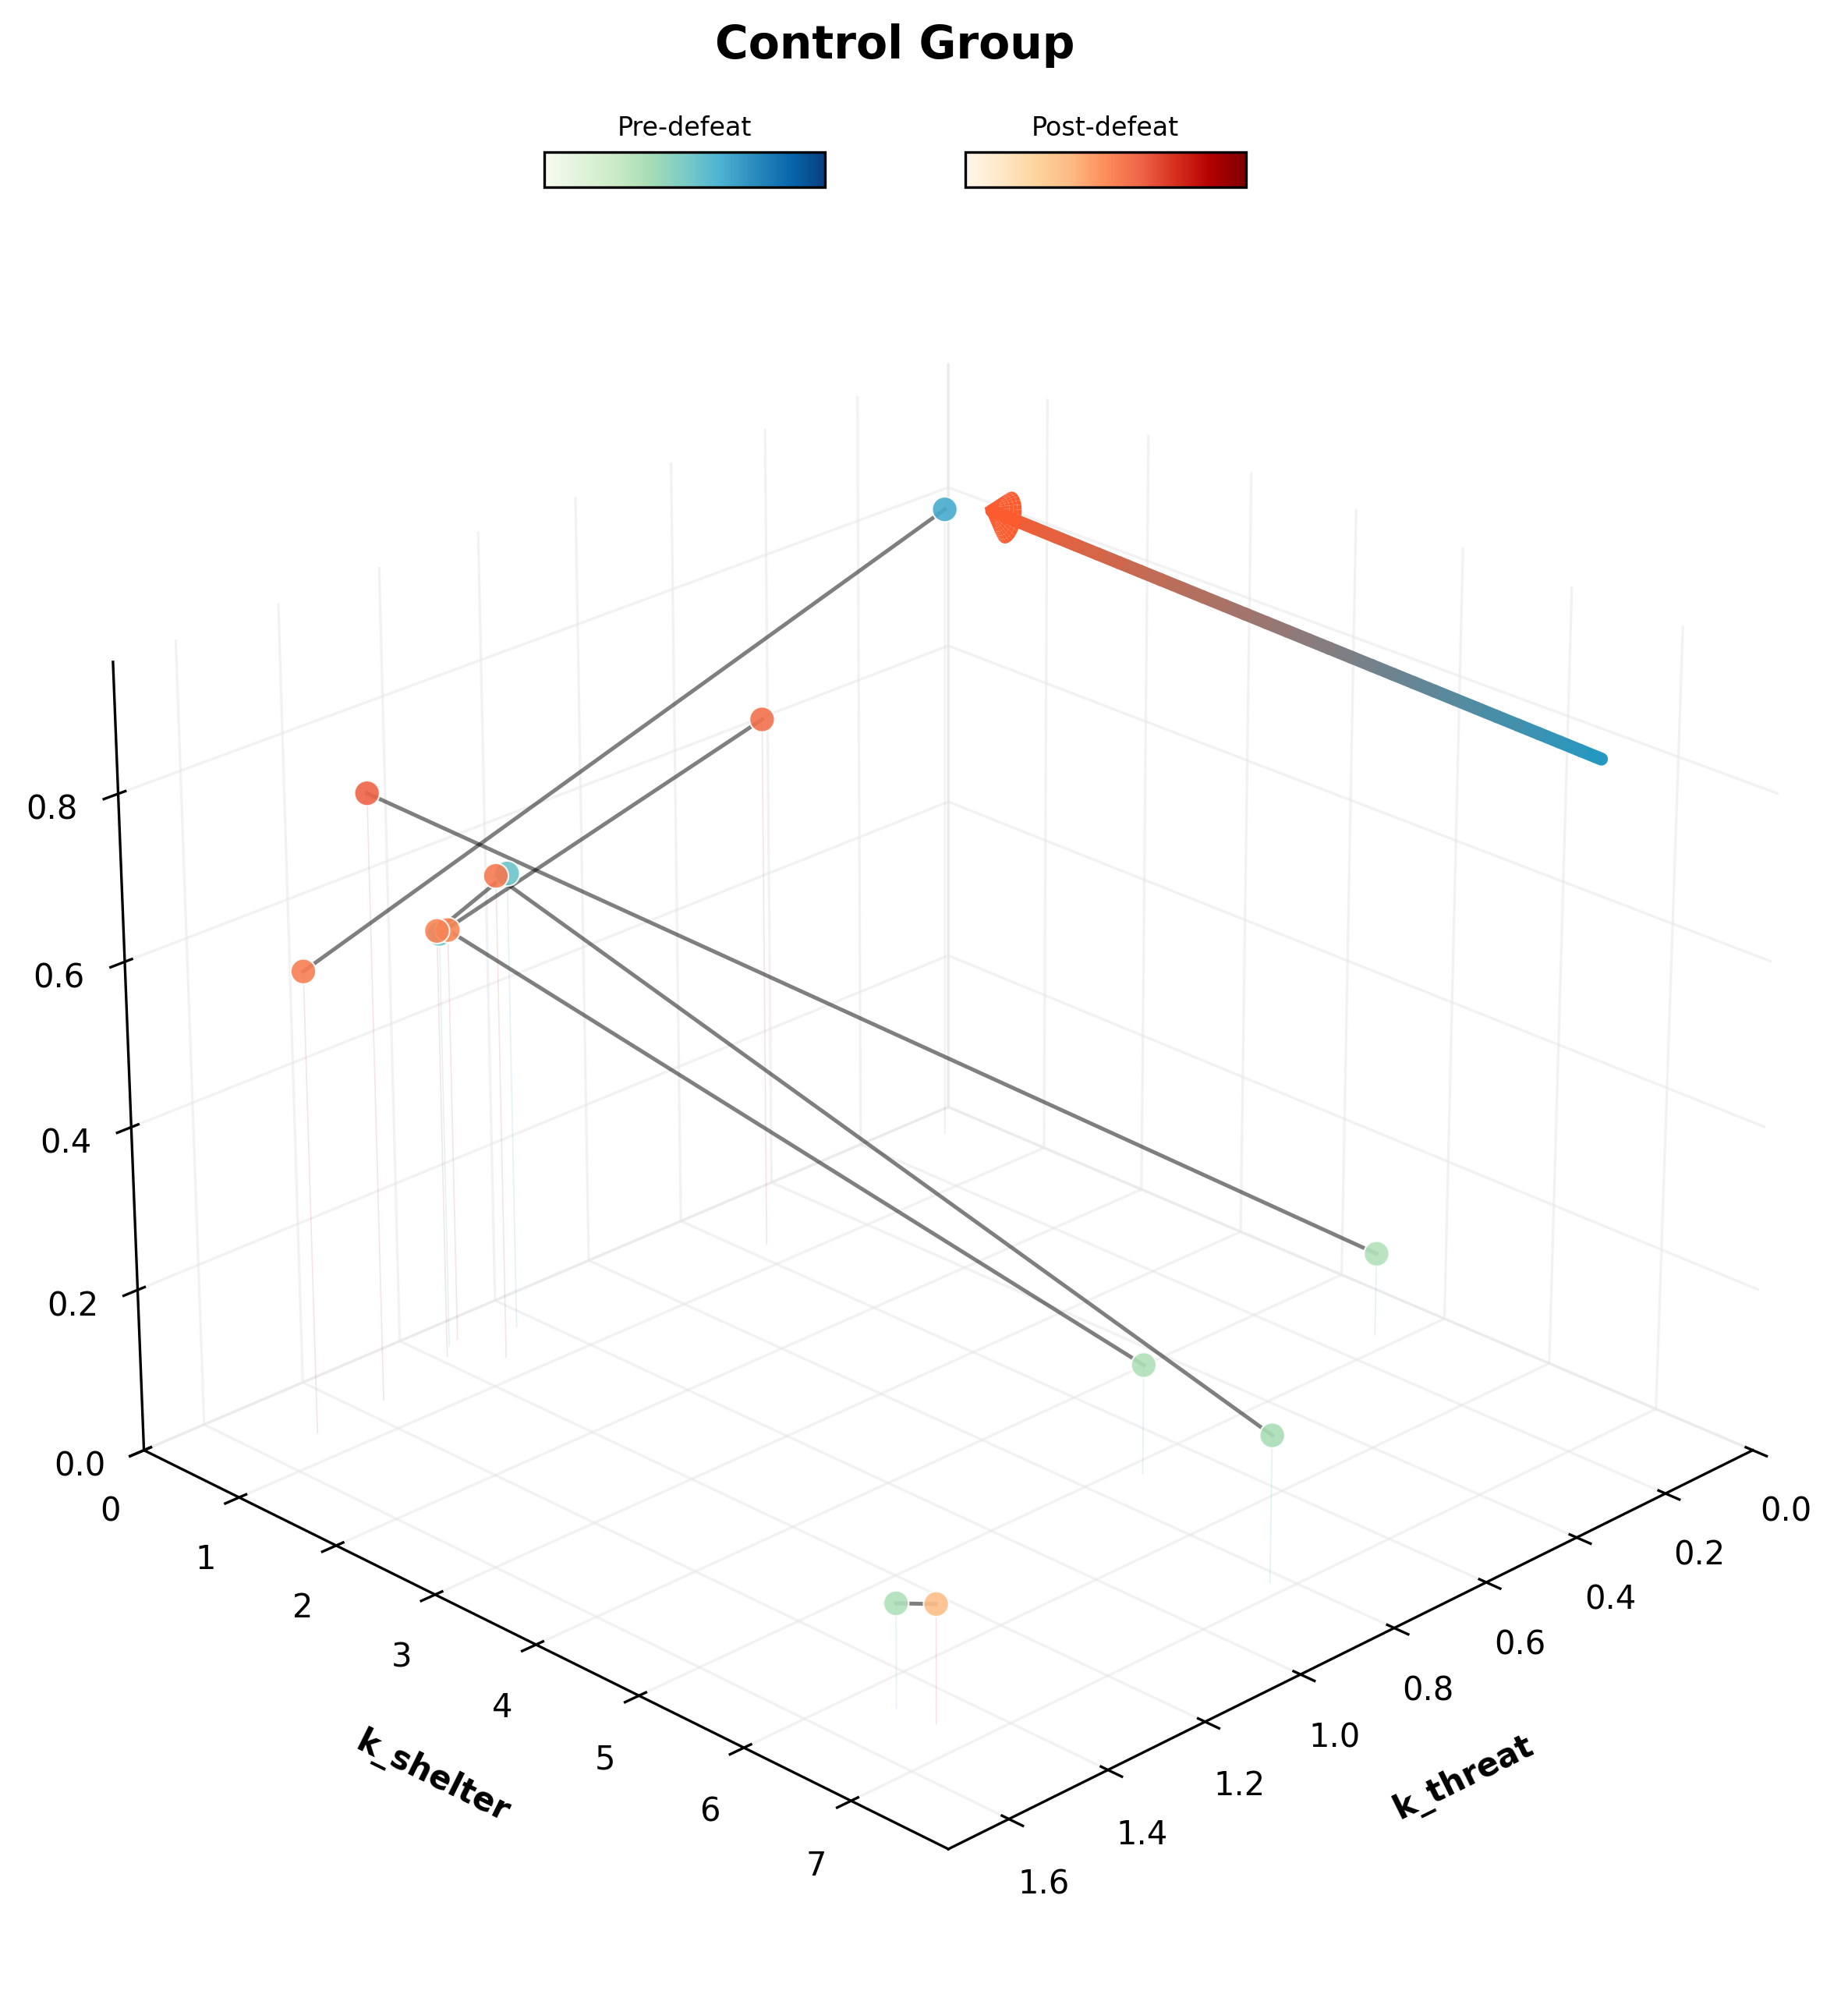

Plotting Defeat Group...


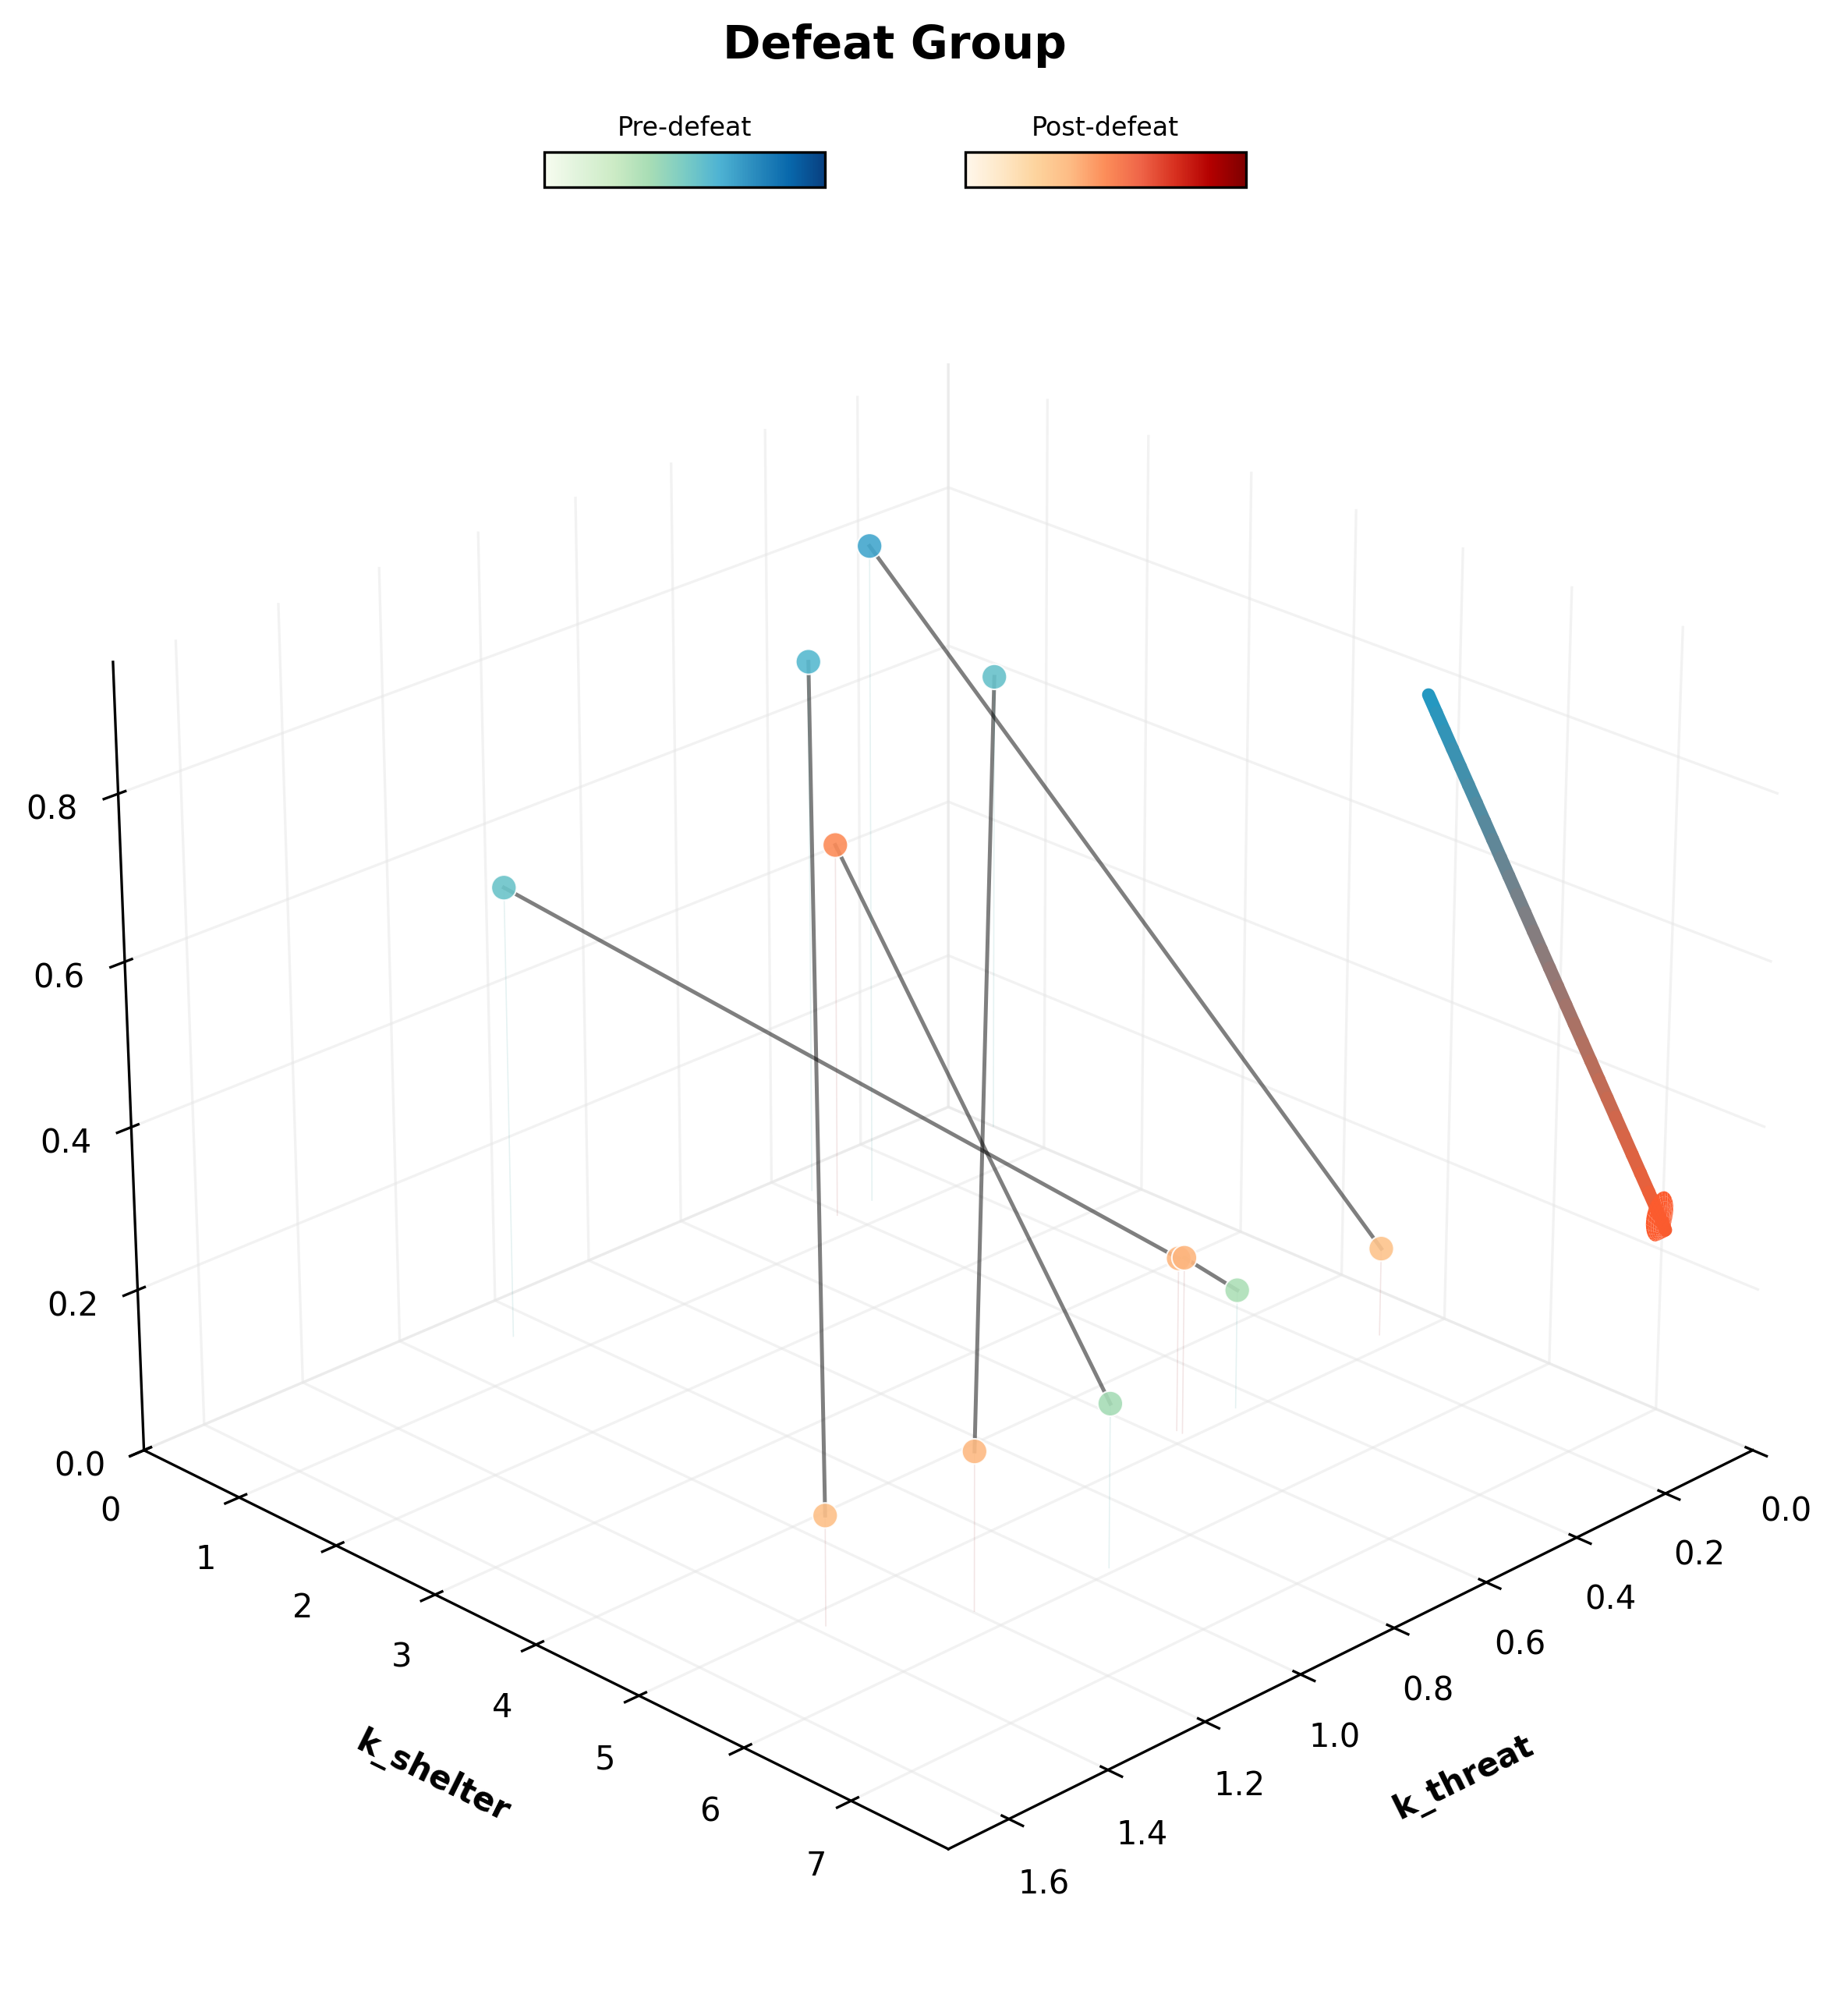

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import pandas as pd
import io
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# --- 1. DATA PREPARATION ---
sim_txt = """mouse_id   db      id      loss    param_id_threshold      param_k_shelter param_k_threat  param_delta_stay        param_sensory_prec_slope        metric_entropy  metric_laziness metric_n_ch_co  metric_n_co_ch  metric_n_co_sh  metric_n_sh_co  metric_t_investigating  metric_t_shelter
13_def1 Resilient_def.db        78      1.1469  0.180407764     6.861623272     0.826247438     1.630272862     0       3.20400457      0.814   10      10      5       5       0.148   0.565
13_def3 Resilient_hab_FAIL.db   18      2.3003  0.600207615     0.720644735     1.120970781     2.314835569     0.768483092     4.395300543     0.756   12      12      7       8       0.195   0.221
14_def1 Resilient_def.db        55      3.1273  0.201111731     5.942374128     0.960001603     1.762287243     0       3.555217019     0.8525  9       9       2       3       0.0845  0.585
14_def3 Resilient_hab_FAIL.db   75      2.8713  0.474978537     0.735021943     0.40967481      2.775568426     0.719183635     3.901667725     0.8085  13      14      4       5       0.3685  0.228
15_def1 Resilient_def.db        14      1.3467  0.126221686     6.323842398     1.484498111     1.808775671     0       2.613338322     0.903   6       6       4       4       0.098   0.672
15_def3 Resilient_def.db        42      6.3457  0.143695616     6.66008529      1.476698564     1.305955879     0       3.022716129     0.783   13      13      9       10      0.147   0.5215
16_def1 Susceptible_hab_FINAL.db        49      2.348   0.562116301     0.513166255     1.064224019     4.241777657     0.779599742     3.984038799     0.7835  10      10      1       2       0.4275  0.07
16_def3 Resilient_hab.db        51      1.0974  0.215362591     4.858386478     0.568861431     5.207956288     0.081368589     2.554980742     0.8475  10      11      5       6       0.173   0.6515
17_def1 Resilient_hab.db        67      2.2025  0.147982637     4.908866188     0.450585783     3.754876603     0.087463598     3.195065402     0.8335  11      11      6       6       0.2345  0.5965
17_def3 Resilient_hab.db        59      2.1103  0.219379437     4.914607524     0.569200004     3.918470286     0.073756821     2.602157206     0.8865  7       8       4       5       0.2735  0.5845
18_def1 Resilient_def.db        57      7.4037  0.135512367     5.145068594     0.708029413     1.798279975     0       3.433378673     0.775   15      15      8       8       0.1955  0.5645
18_def3 Control_hab_FINAL.db    34      6.381   0.513798117     0.271078611     1.133015332     1.060739951     0.87705756      4.666456582     0.7555  11      12      7       8       0.1535  0.228
20_def1 Susceptible_hab_FINAL.db        5       1.8026  0.568142213     0.412685096     1.037225998     2.613226977     0.776791986     4.177511677     0.7475  14      14      4       5       0.3715  0.0745
20_def3 Susceptible_hab_FINAL.db        24      1.2768  0.531651953     0.41390964      1.182777538     2.089778287     0.622883386     4.439213218     0.7345  5       6       2       3       0.357   0.1065
21_def1 Resilient_hab.db        20      1.8741  0.103630834     4.825989884     0.118080673     5.547148791     0.046869741     3.741922515     0.8115  13      13      5       5       0.5405  0.2105
21_def3 Susceptible_hab_FINAL.db        22      2.3349  0.746882201     0.602892196     1.351583253     2.124068703     0.602753783     4.360964179     0.7055  13      13      4       4       0.4225  0.159
22_def1 Control_hab_FINAL.db    62      2.1188  0.515727116     0.298897194     1.155770898     1.009888668     0.816352739     4.296422916     0.7375  15      15      8       9       0.1535  0.3055
22_def3 Resilient_hab_FAIL.db   25      3.0018  0.665375015     0.718894487     0.562195376     2.60938758      0.690246688     4.281682272     0.8295  10      11      3       4       0.23    0.0975
23_def1 Resilient_hab_FAIL.db   58      2.8364  0.830166775     0.734315132     0.332184857     2.285588408     0.782920093     4.346072157     0.7715  13      14      3       4       0.403   0.104
23_def3 Resilient_hab.db        17      5.9997  0.109951258     4.847216333     0.112630034     4.480764102     0.088885205     4.038996715     0.7665  16      17      9       10      0.475   0.3075
24_def1 calibration.db  33      2.7163  0.582953175     0.472766494     0       1.419451408     0.582095713     3.464592897     0.858   4       5       0       1       0.6085  0.077
24_def3 Resilient_def.db        77      6.558   0.19465149      5.735824491     1.196772465     1.747892392     0       3.340437851     0.8135  10      10      6       6       0.0745  0.6445
25_def1 Control_hab_FINAL.db    51      1.6646  0.801735408     0.303597354     0.074175372     1.529782747     0.428132801     3.755710101     0.882   2       3       0       1       0.4245  0.094
25_def3 Control_hab_FINAL.db    27      0.9424  0.568834512     0.651145654     1.496086078     3.22191556      0.200144416     3.6980664       0.835   7       8       0       1       0.55    0.06
26_def1 Resilient_hab_FAIL.db   84      7.7945  0.675904292     0.305758318     0.374797732     1.090950188     0.673335522     4.304864657     0.7995  11      12      1       2       0.41    0.1045
26_def3 Resilient_def.db        26      3.6624  0.134363192     5.178042798     1.382055521     2.284639358     0       1.555892085     0.932   3       3       3       3       0.0225  0.867
"""

df = pd.read_csv(io.StringIO(sim_txt), sep='\s+')
df['mouse_num'] = df['mouse_id'].apply(lambda x: x.split('_')[0])
df['phase'] = df['mouse_id'].apply(lambda x: x.split('_')[1])
px, py, pz = 'param_k_threat', 'param_k_shelter', 'param_id_threshold'

# --- GLOBAL SCALING ---
x_all, y_all, z_all = df[px].values, df[py].values, df[pz].values
# Add padding to global limits
xlim_global = (0, np.max(x_all) * 1.15)
ylim_global = (0, np.max(y_all) * 1.15)
zlim_global = (0, np.max(z_all) * 1.15)

v_min, v_max = np.min(z_all) - 0.75, np.max(z_all) + 0.75
norm = Normalize(vmin=v_min, vmax=v_max)
PHASE_PRE, PHASE_POST = 'def1', 'def3'

# --- HELPER: Draw smooth arrowhead ---
def draw_arrow_head(ax, tip, direction, color, scale=1.0):
    """Draws a cone-shaped arrowhead."""
    # Normalize direction vector
    direction = direction / np.linalg.norm(direction)
    
    # Cone parameters
    height = 0.8 * scale
    radius = 0.2 * scale
    base_center = tip - 0.7*(direction * height)

    # Create cone mesh
    phi = np.linspace(0, 2*np.pi, 30)
    r = np.linspace(0, radius, 10)
    Phi, R = np.meshgrid(phi, r)
    
    # Canonical cone (pointing up Z)
    Xc = R * np.cos(Phi)
    Yc = R * np.sin(Phi)
    Zc = -R * (height / radius) + height # Point at (0,0,height), base at z=0

    # Rotation to align with direction vector
    # Find rotation axis and angle to rotate Z-axis to direction vector
    z_axis = np.array([0, 0, 1])
    if np.allclose(direction, z_axis):
        rot_matrix = np.eye(3)
    elif np.allclose(direction, -z_axis):
        rot_matrix = np.array([[1, 0, 0], [0, -1, 0], [0, 0, -1]])
    else:
        rot_axis = np.cross(z_axis, direction)
        rot_axis = rot_axis / np.linalg.norm(rot_axis)
        rot_angle = np.arccos(np.dot(z_axis, direction))
        
        # Rodrigues' rotation formula matrix
        K = np.array([[0, -rot_axis[2], rot_axis[1]],
                      [rot_axis[2], 0, -rot_axis[0]],
                      [-rot_axis[1], rot_axis[0], 0]])
        rot_matrix = np.eye(3) + np.sin(rot_angle) * K + (1 - np.cos(rot_angle)) * np.dot(K, K)

    # Apply rotation and translation
    X_rot, Y_rot, Z_rot = np.zeros_like(Xc), np.zeros_like(Yc), np.zeros_like(Zc)
    for i in range(Xc.shape[0]):
        for j in range(Xc.shape[1]):
            vec = np.array([Xc[i,j], Yc[i,j], Zc[i,j]])
            rot_vec = rot_matrix @ vec
            X_rot[i,j] = rot_vec[0] + base_center[0]
            Y_rot[i,j] = rot_vec[1] + base_center[1]
            Z_rot[i,j] = rot_vec[2] + base_center[2]

    ax.plot_surface(X_rot, Y_rot, Z_rot, color=color, alpha=1.0, shade=False, antialiased=True)

def draw_gradient_arrow(ax, start, vector, cmap_start='YlGnBu', cmap_end='YlOrRd', segments=30):
    c1 = plt.get_cmap(cmap_start)(0.6) 
    c2 = plt.get_cmap(cmap_end)(0.6)
    
    # Line body
    x = np.linspace(start[0], start[0] + vector[0], segments)
    y = np.linspace(start[1], start[1] + vector[1], segments)
    z = np.linspace(start[2], start[2] + vector[2], segments)
    
    colors = [(1-t)*np.array(c1) + t*np.array(c2) for t in np.linspace(0, 1, segments)]
    
    # Draw thicker line segments
    linewidth = 4
    for i in range(segments - 1):
        ax.plot([x[i], x[i+1]], [y[i], y[i+1]], [z[i], z[i+1]], 
                color=colors[i], linewidth=linewidth, alpha=1.0, solid_capstyle='round')
        
    # Draw smooth arrowhead
    tip = np.array([x[-1], y[-1], z[-1]])
    draw_arrow_head(ax, tip, vector, color=c2, scale=0.15)

def plot_mice_group(group_name, df_subset, anchor_y_offset=1):
    fig = plt.figure(figsize=(10, 10), dpi=300)
    ax = fig.add_subplot(111, projection='3d')
    
    mouse_list = df_subset['mouse_num'].unique()
    pre_coords, post_coords = [], []

    # 1. Lines & Data Gathering
    for m_id in mouse_list:
        m_data = df_subset[df_subset['mouse_num'] == m_id]
        if len(m_data) >= 2:
            h = m_data[m_data['phase'] == PHASE_PRE]
            d = m_data[m_data['phase'] == PHASE_POST]
            if not h.empty and not d.empty:
                pre_coords.append([h[px].item(), h[py].item(), h[pz].item()])
                post_coords.append([d[px].item(), d[py].item(), d[pz].item()])
                
                ax.plot([h[px].item(), d[px].item()], [h[py].item(), d[py].item()], [h[pz].item(), d[pz].item()],
                        color='black', linewidth=1.2, alpha=0.5)
                # Drop lines
                ax.plot([h[px].item(), h[px].item()], [h[py].item(), h[py].item()], [0, h[pz].item()], color='teal', alpha=0.1, linewidth=0.4)
                ax.plot([d[px].item(), d[px].item()], [d[py].item(), d[py].item()], [0, d[pz].item()], color='darkred', alpha=0.1, linewidth=0.4)

    # 2. Scatter Points
    pre_data = df_subset[df_subset['phase'] == PHASE_PRE]
    post_data = df_subset[df_subset['phase'] == PHASE_POST]
    cmap_pre, cmap_post = plt.get_cmap('GnBu'), plt.get_cmap('OrRd')

    ax.scatter(pre_data[px], pre_data[py], pre_data[pz], c=pre_data[pz], cmap=cmap_pre, norm=norm, s=60, alpha=0.9, edgecolors='white', linewidth=0.5)
    ax.scatter(post_data[px], post_data[py], post_data[pz], c=post_data[pz], cmap=cmap_post, norm=norm, s=60, alpha=0.9, edgecolors='white', linewidth=0.5)

    # --- 3. NET CHANGE VECTOR (TOP RIGHT) ---
    if pre_coords and post_coords:
        mean_pre = np.mean(pre_coords, axis=0)
        mean_post = np.mean(post_coords, axis=0)
        net_vector = mean_post - mean_pre
        
        # Anchor point: Top Right corner (high X, high Y, high Z)
        anchor_x = xlim_global[0] * 0.8
        anchor_y = (ylim_global[1] - anchor_y_offset) * 0.8
        anchor_z = zlim_global[1] * 0.8
        anchor_point = np.array([anchor_x, anchor_y, anchor_z])
        
        # Scale vector for visibility in the corner
        draw_gradient_arrow(ax, anchor_point, net_vector * 1.5)
        # Label removed as requested

    # Aesthetics
    ax.set_xlabel('k_threat', fontsize=10, weight='bold', labelpad=12)
    ax.set_ylabel('k_shelter', fontsize=10, weight='bold', labelpad=12)

    # Lighter grid
    ax.xaxis._axinfo["grid"]['color'] =  (0.9,0.9,0.9,0.5)
    ax.yaxis._axinfo["grid"]['color'] =  (0.9,0.9,0.9,0.5)
    ax.zaxis._axinfo["grid"]['color'] =  (0.9,0.9,0.9,0.5)
    
    # --- FIX Z LABEL VISIBILITY ---
    # Reverting to standard zlabel with very high padding and adjusting view distance
    ax.set_zlabel('id_threshold', fontsize=10, weight='bold', labelpad=25)
    
    ax.set_xlim(xlim_global)
    ax.set_ylim(ylim_global)
    ax.set_zlim(zlim_global)
    
    # Increased distance slightly to prevent clipping
    ax.dist = 12 
    ax.view_init(elev=25, azim=45)

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.set_pane_color((1.0, 1.0, 1.0, 0.0))

    # Mini Colorbars
    cax1, cax2 = fig.add_axes([0.35, 0.88, 0.12, 0.015]), fig.add_axes([0.53, 0.88, 0.12, 0.015])
    sm_pre, sm_post = ScalarMappable(norm=norm, cmap=cmap_pre), ScalarMappable(norm=norm, cmap=cmap_post)
    cbar1 = fig.colorbar(sm_pre, cax=cax1, orientation='horizontal'); cbar1.set_ticks([]); cax1.set_title('Pre-defeat', weight='normal', size=8, pad=5)
    cbar2 = fig.colorbar(sm_post, cax=cax2, orientation='horizontal'); cbar2.set_ticks([]); cax2.set_title('Post-defeat', weight='normal', size=8, pad=5)
    
    fig.suptitle(f"{group_name} Group", fontsize=14, weight='bold', y=0.95)
    plt.show()

# --- EXECUTION ---
intcontrol_ids = [13,15,18,20,21,22,25]
intdefeat_ids = [14,16,17,23,24,26]

control_ids = []
defeat_ids = []

for i in intcontrol_ids:
    control_ids.append(str(i))

for i in intdefeat_ids:
    defeat_ids.append(str(i))

print(f"Plotting Control Group...")
plot_mice_group("Control", df[df['mouse_num'].isin(control_ids)], anchor_y_offset=0)
print(f"Plotting Defeat Group...")
plot_mice_group("Defeat", df[df['mouse_num'].isin(defeat_ids)], anchor_y_offset=2)

Plotting Control Group...


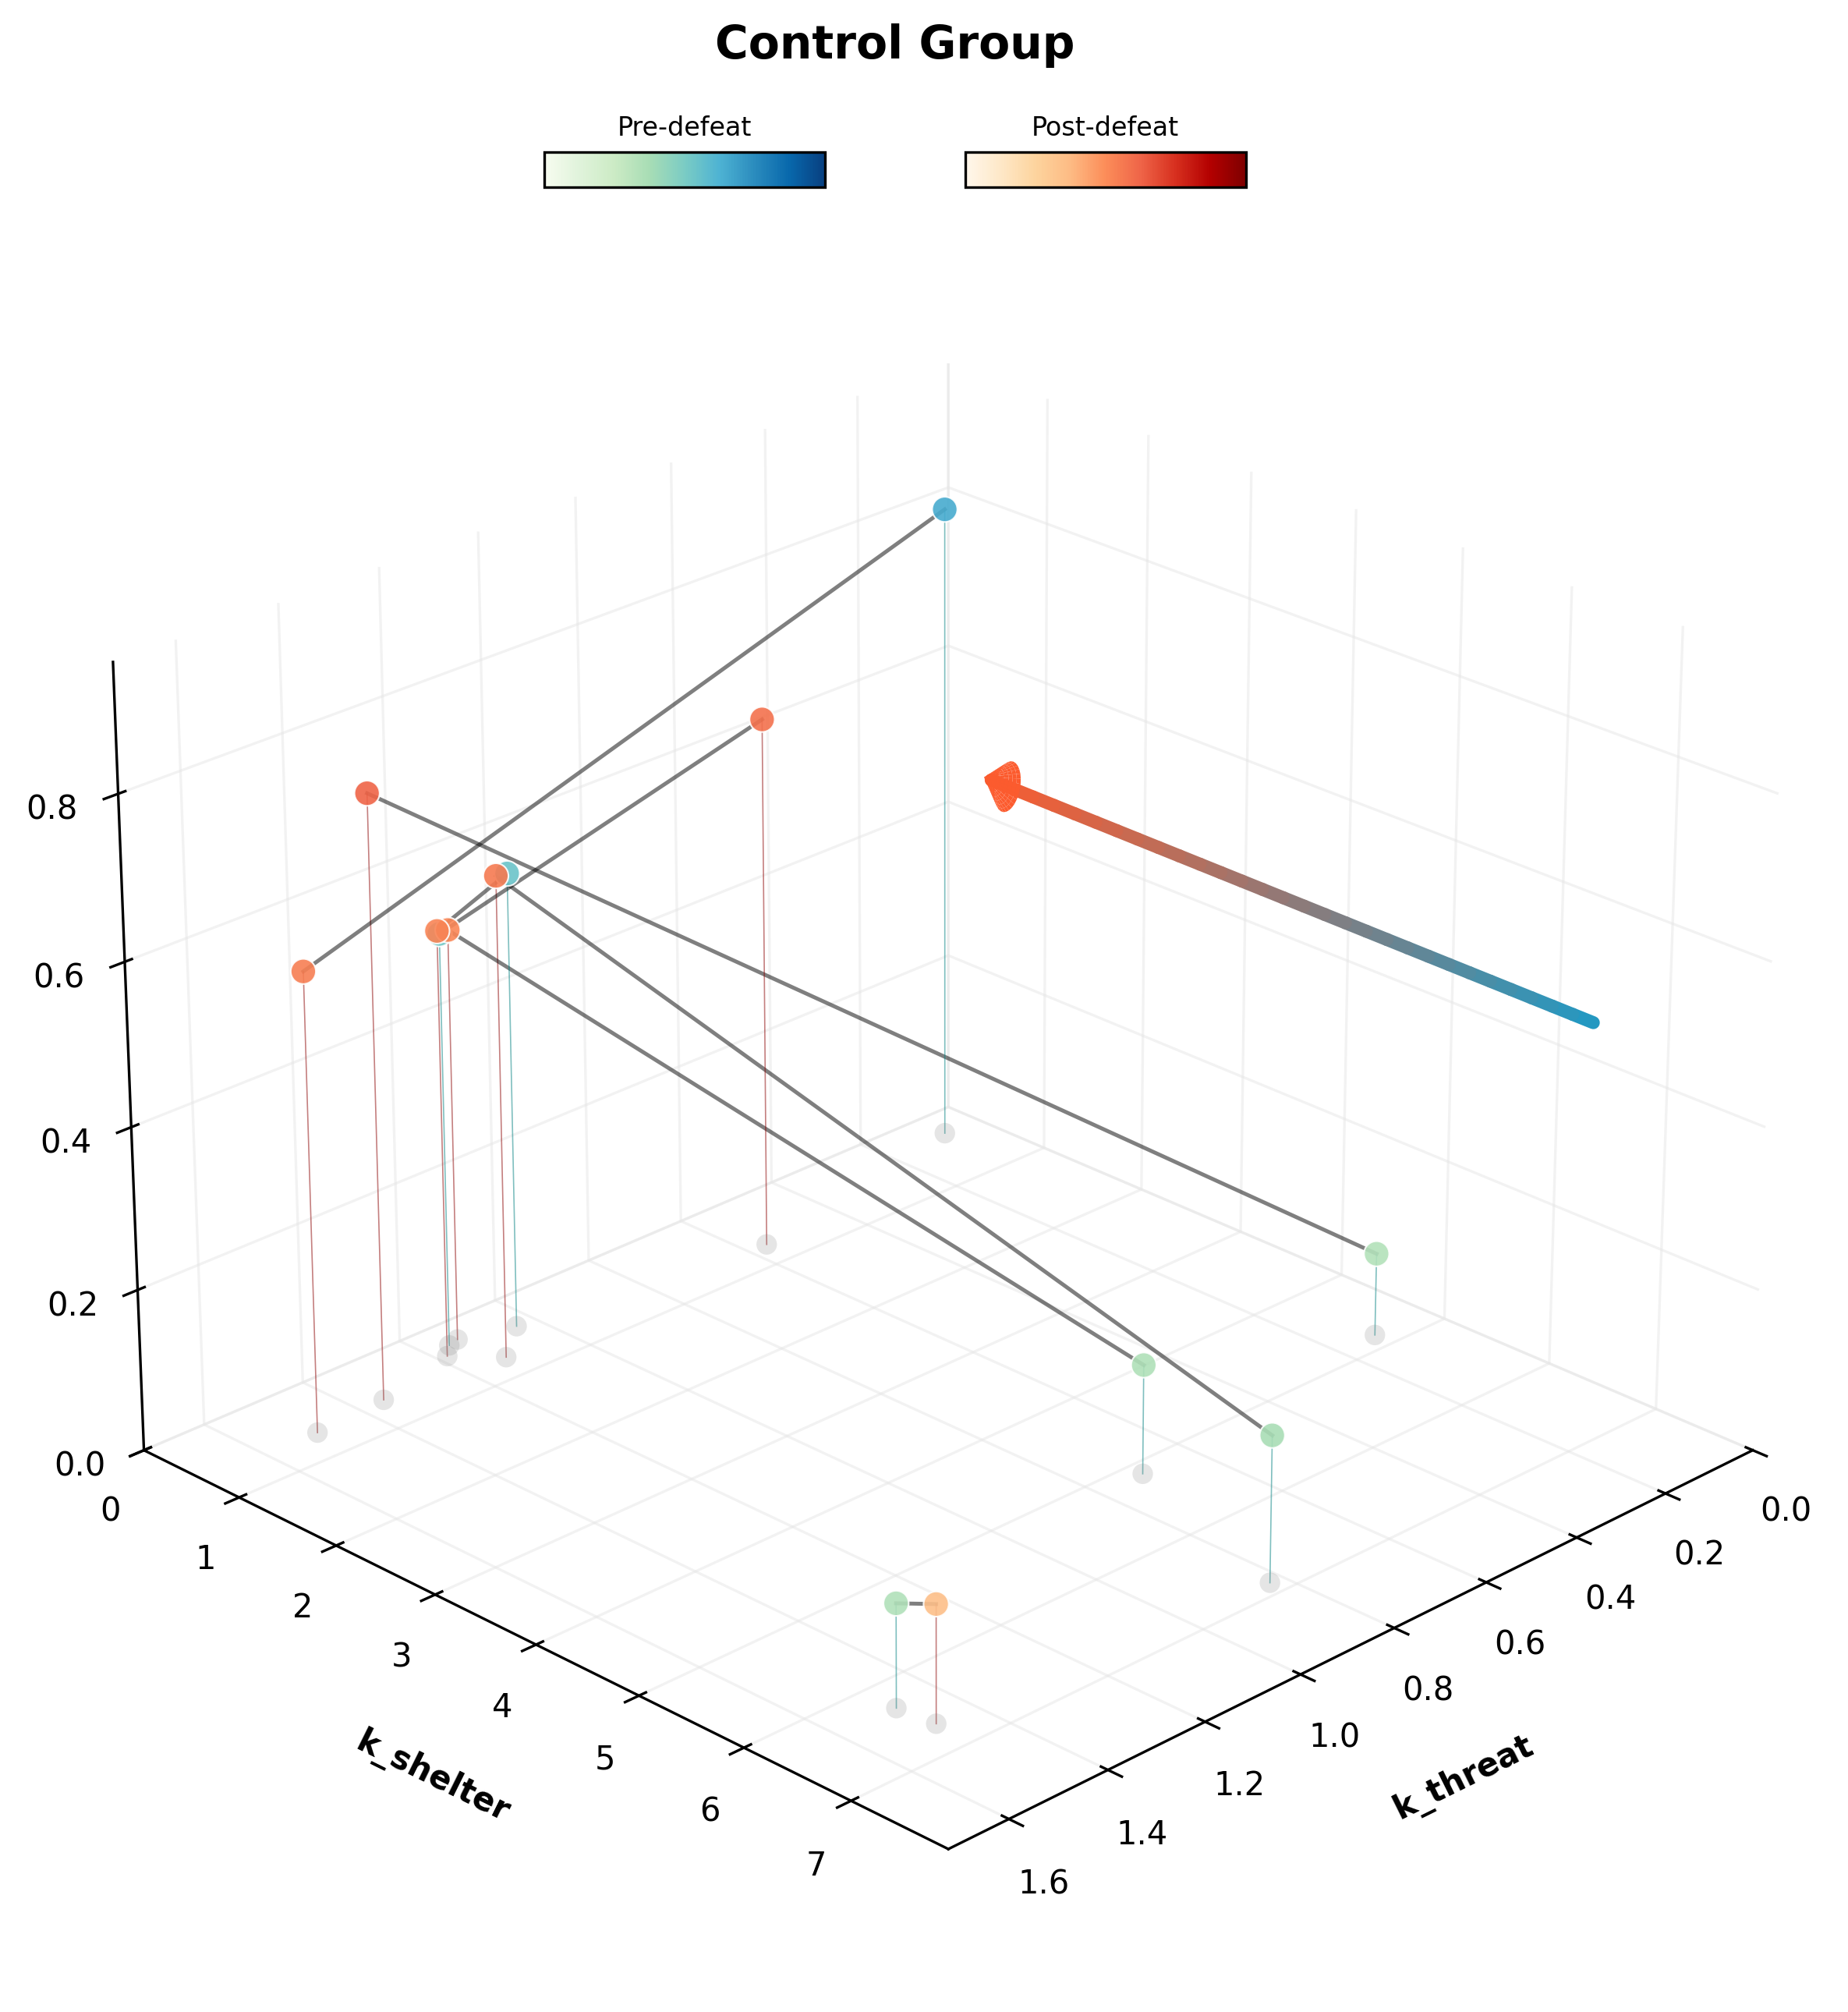

Plotting Defeat Group...


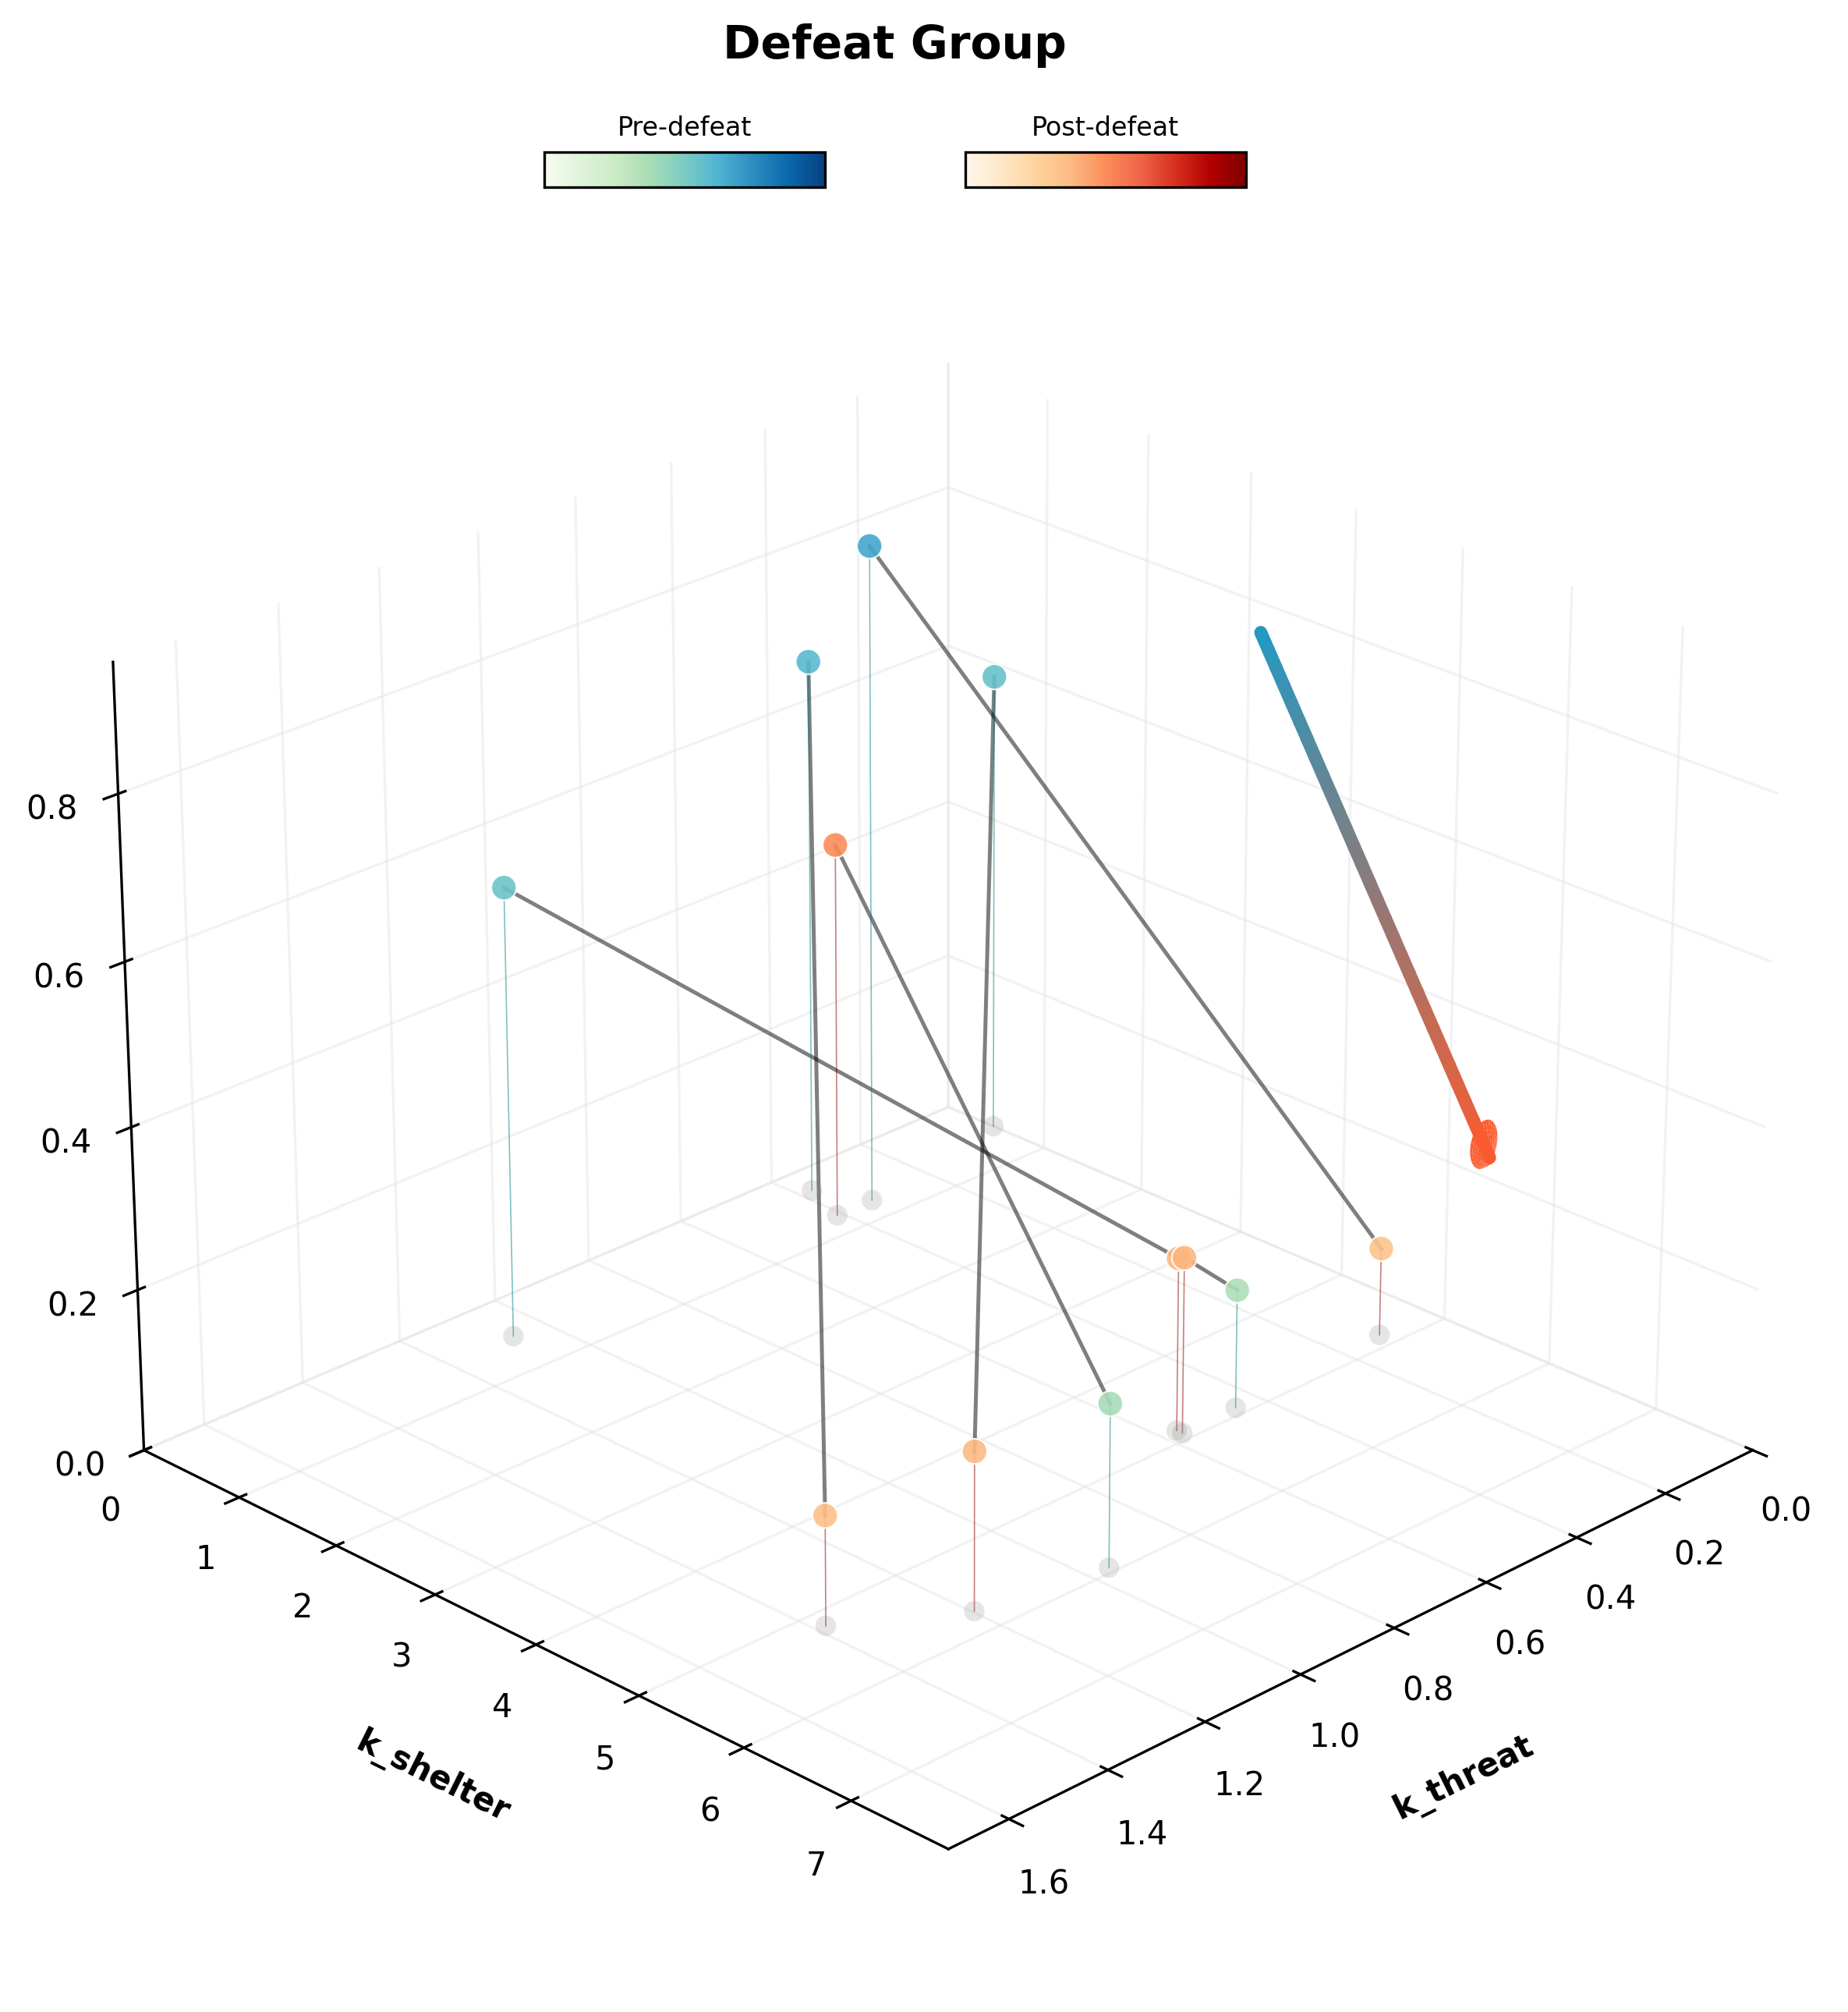

In [76]:
def plot_mice_group(group_name, df_subset, anchor_y_offset=1, anchor_z_offset=0, filename=None):
    fig = plt.figure(figsize=(10, 10), dpi=300)
    ax = fig.add_subplot(111, projection='3d')
    
    mouse_list = df_subset['mouse_num'].unique()
    pre_coords, post_coords = [], []

    # 1. Lines & Data Gathering
    for m_id in mouse_list:
        m_data = df_subset[df_subset['mouse_num'] == m_id]
        if len(m_data) >= 2:
            h = m_data[m_data['phase'] == PHASE_PRE]
            d = m_data[m_data['phase'] == PHASE_POST]
            if not h.empty and not d.empty:
                pre_coords.append([h[px].item(), h[py].item(), h[pz].item()])
                post_coords.append([d[px].item(), d[py].item(), d[pz].item()])
                
                ax.plot([h[px].item(), d[px].item()], [h[py].item(), d[py].item()], [h[pz].item(), d[pz].item()],
                        color='black', linewidth=1.2, alpha=0.5)
                # Drop lines
                ax.plot([h[px].item(), h[px].item()], [h[py].item(), h[py].item()], [0, h[pz].item()], color='teal', alpha=0.5, linewidth=0.4)
                ax.plot([d[px].item(), d[px].item()], [d[py].item(), d[py].item()], [0, d[pz].item()], color='darkred', alpha=0.5, linewidth=0.4)

    # 2. Scatter Points
    pre_data = df_subset[df_subset['phase'] == PHASE_PRE]
    post_data = df_subset[df_subset['phase'] == PHASE_POST]
    cmap_pre, cmap_post = plt.get_cmap('GnBu'), plt.get_cmap('OrRd')

    # --- ADDED: SHADOWS ON X-Y PLANE ---
    # We plot the same X and Y, but force Z to be 0
    ax.scatter(pre_data[px], pre_data[py], np.zeros_like(pre_data[pz]), 
               color='gray', s=40, alpha=0.2, edgecolors='none')
    ax.scatter(post_data[px], post_data[py], np.zeros_like(post_data[pz]), 
               color='gray', s=40, alpha=0.2, edgecolors='none')

    # Original 3D Points
    ax.scatter(pre_data[px], pre_data[py], pre_data[pz], c=pre_data[pz], cmap=cmap_pre, norm=norm, s=60, alpha=0.9, edgecolors='white', linewidth=0.5)
    ax.scatter(post_data[px], post_data[py], post_data[pz], c=post_data[pz], cmap=cmap_post, norm=norm, s=60, alpha=0.9, edgecolors='white', linewidth=0.5)

    # --- 3. NET CHANGE VECTOR (TOP RIGHT) ---
    if pre_coords and post_coords:
        mean_pre = np.mean(pre_coords, axis=0)
        mean_post = np.mean(post_coords, axis=0)
        net_vector = mean_post - mean_pre
        
        anchor_x = xlim_global[0] * 0.8
        anchor_y = (ylim_global[1] - anchor_y_offset) * 0.8
        anchor_z = (zlim_global[1] - anchor_z_offset) * 0.8
        anchor_point = np.array([anchor_x, anchor_y, anchor_z])
        
        draw_gradient_arrow(ax, anchor_point, net_vector * 1.5)

    # Aesthetics
    ax.set_xlabel('k_threat', fontsize=10, weight='bold', labelpad=12)
    ax.set_ylabel('k_shelter', fontsize=10, weight='bold', labelpad=12)
    ax.xaxis._axinfo["grid"]['color'] = (0.9,0.9,0.9,0.5)
    ax.yaxis._axinfo["grid"]['color'] = (0.9,0.9,0.9,0.5)
    ax.zaxis._axinfo["grid"]['color'] = (0.9,0.9,0.9,0.5)
    ax.set_zlabel('id_threshold', fontsize=10, weight='bold', labelpad=25)
    
    ax.set_xlim(xlim_global)
    ax.set_ylim(ylim_global)
    ax.set_zlim(zlim_global)
    
    ax.dist = 12 
    ax.view_init(elev=25, azim=45)

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.set_pane_color((1.0, 1.0, 1.0, 0.0))

    cax1, cax2 = fig.add_axes([0.35, 0.88, 0.12, 0.015]), fig.add_axes([0.53, 0.88, 0.12, 0.015])
    sm_pre, sm_post = ScalarMappable(norm=norm, cmap=cmap_pre), ScalarMappable(norm=norm, cmap=cmap_post)
    cbar1 = fig.colorbar(sm_pre, cax=cax1, orientation='horizontal'); cbar1.set_ticks([]); cax1.set_title('Pre-defeat', weight='normal', size=8, pad=5)
    cbar2 = fig.colorbar(sm_post, cax=cax2, orientation='horizontal'); cbar2.set_ticks([]); cax2.set_title('Post-defeat', weight='normal', size=8, pad=5)
    
    fig.suptitle(f"{group_name} Group", fontsize=14, weight='bold', y=0.95)
    if filename is not None:
        plt.savefig(filename, format='svg', bbox_inches='tight')
        print(f"Saved: {filename}")
        plt.close(fig) # Close the figure to free up memory
    plt.show()

intcontrol_ids = [13,15,18,20,21,22,25]
intdefeat_ids = [14,16,17,23,24,26]

control_ids = []
defeat_ids = []

for i in intcontrol_ids:
    control_ids.append(str(i))

for i in intdefeat_ids:
    defeat_ids.append(str(i))

print(f"Plotting Control Group...")
plot_mice_group("Control", df[df['mouse_num'].isin(control_ids)], anchor_y_offset=0, anchor_z_offset=0.4, filename=None)
print(f"Plotting Defeat Group...")
plot_mice_group("Defeat", df[df['mouse_num'].isin(defeat_ids)], anchor_y_offset=4, filename=None)

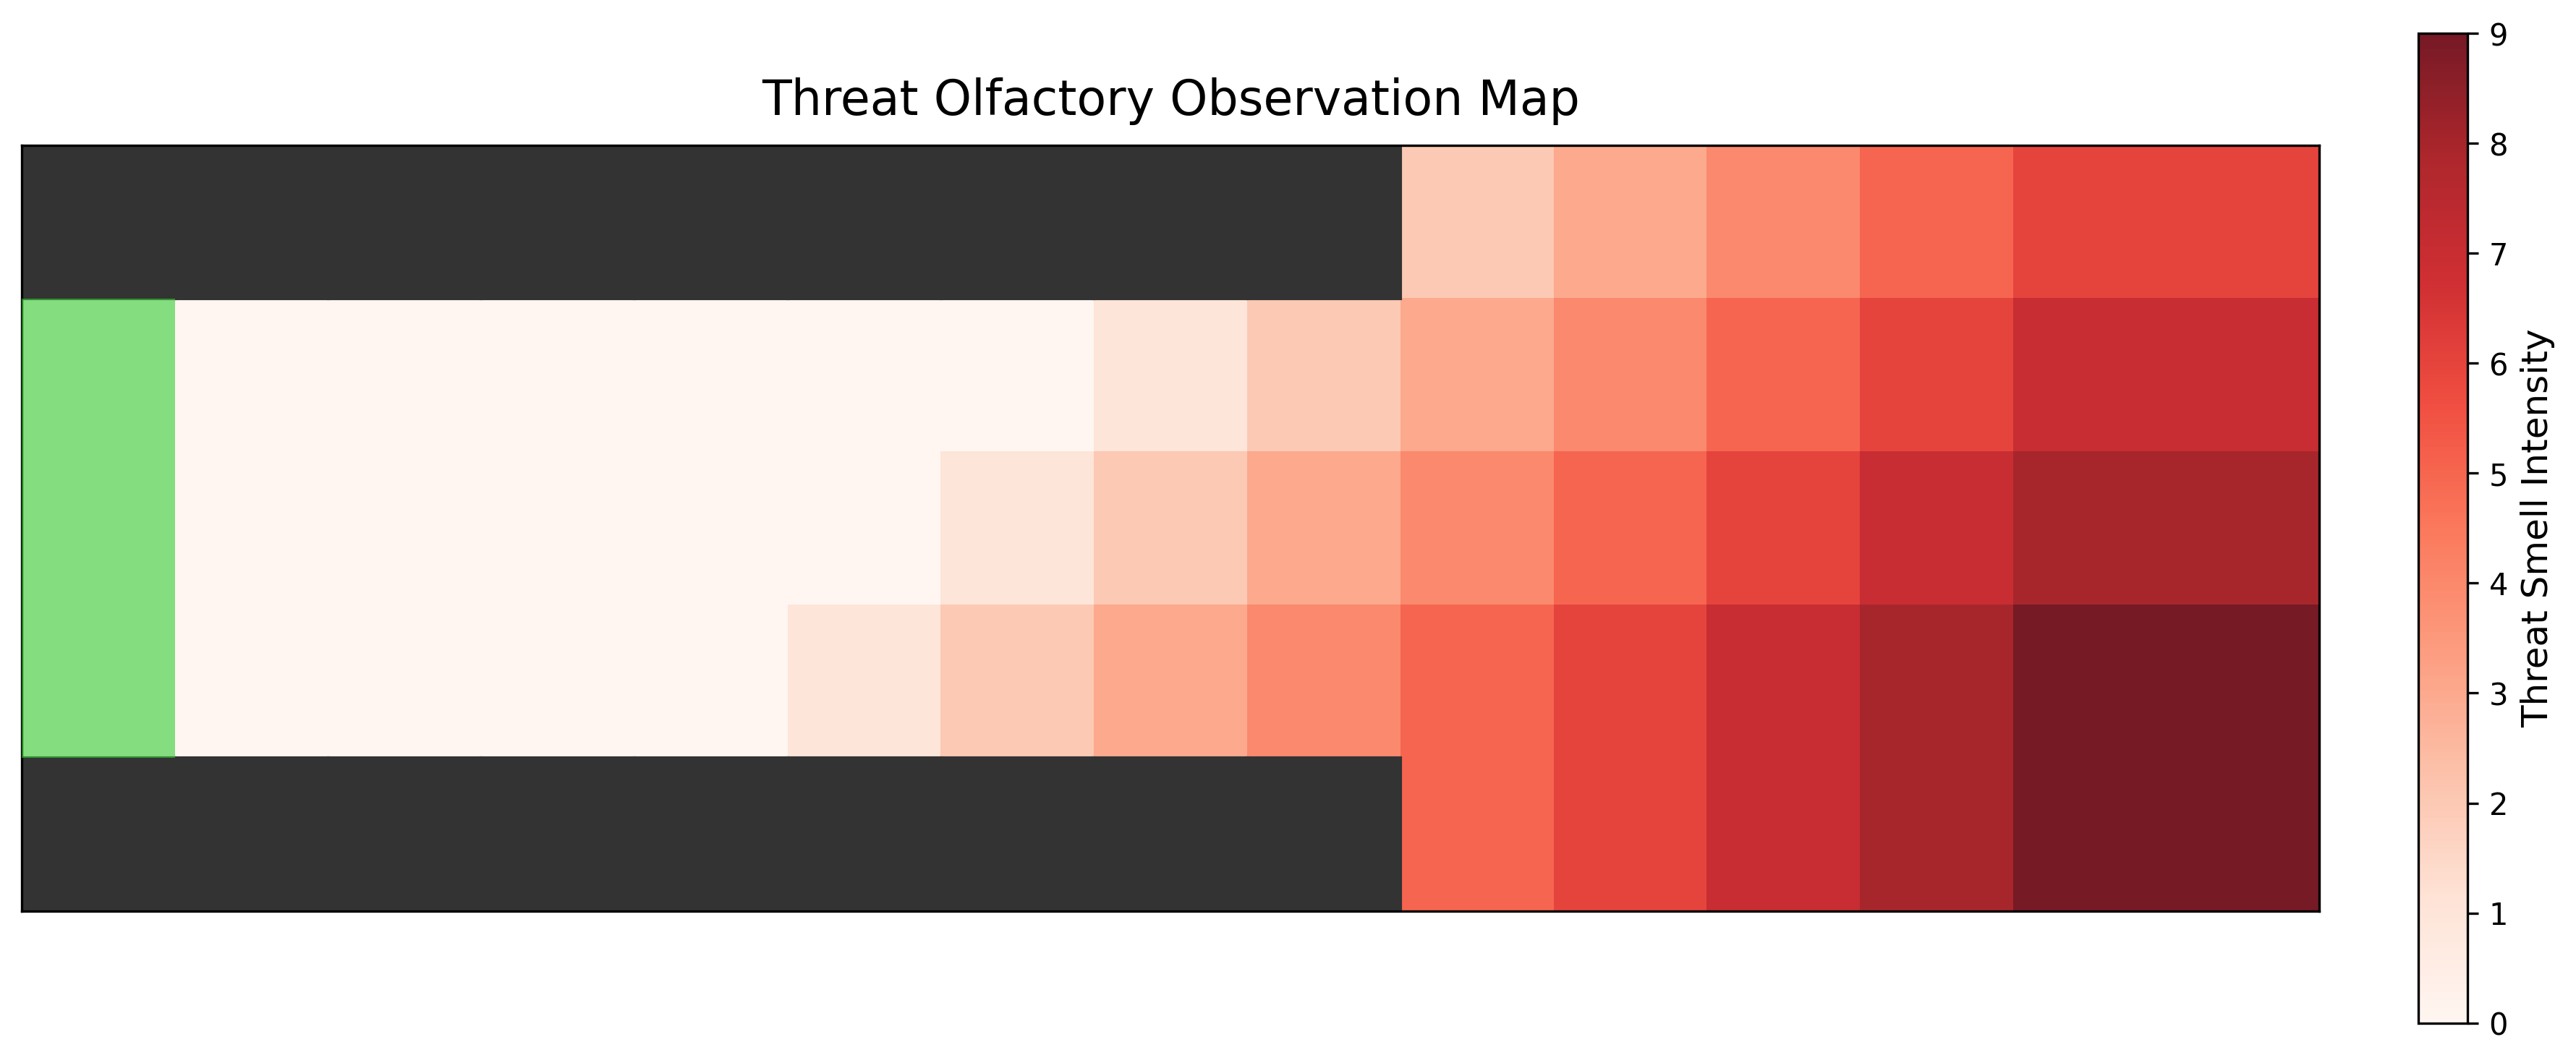

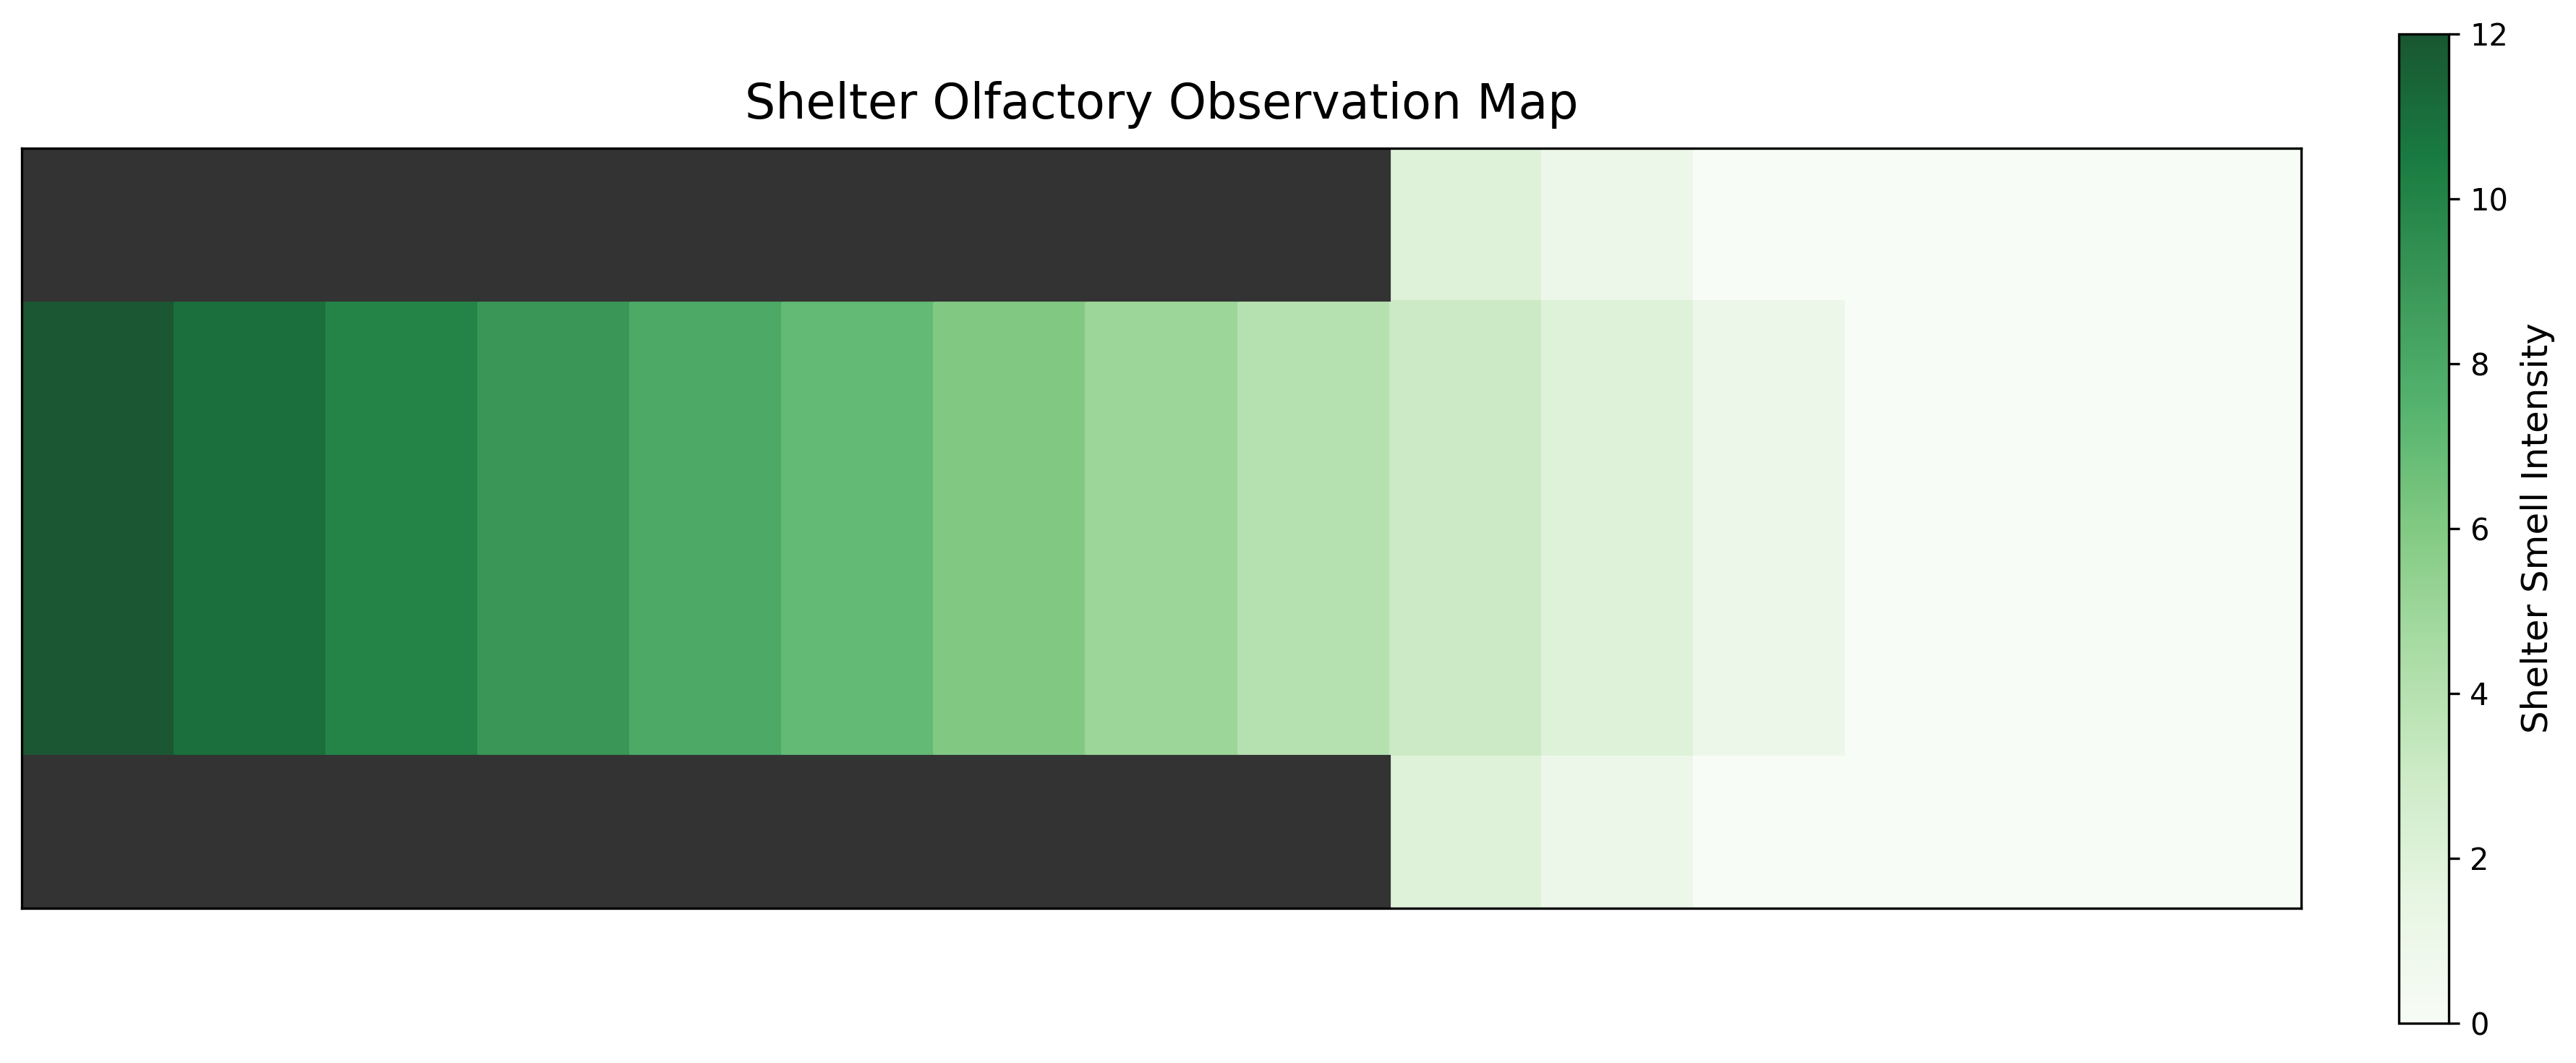

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# --- 1. SETUP DATA ---
mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

rows, cols = mask.shape

# Sources
shelter_cells = [(r, 0) for r in range(rows) if mask[r, 0]]
threat_cells = [(3, 13), (3, 14), (4, 13), (4, 14)]

# Compute Distances
def get_min_manhattan_dist(r, c, source_cells):
    dists = [abs(r - sr) + abs(c - sc) for (sr, sc) in source_cells]
    return min(dists)

grid_threat = np.full((rows, cols), np.nan)
grid_shelter = np.full((rows, cols), np.nan)

max_threat_intensity = 9
max_shelter_intensity = 12

for r in range(rows):
    for c in range(cols):
        if mask[r, c]:
            # Threat
            dist_t = get_min_manhattan_dist(r, c, threat_cells)
            grid_threat[r, c] = max(0, max_threat_intensity - dist_t)
            
            # Shelter
            dist_s = get_min_manhattan_dist(r, c, shelter_cells)
            grid_shelter[r, c] = max(0, max_shelter_intensity - dist_s)

# Helper for consistent styling
def setup_plot_ax(ax, rows, cols, mask):
    ax.set_xlim(-0.5, cols - 0.5)
    ax.set_ylim(rows - 0.5, -0.5)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    # Draw walls
    for r in range(rows):
        for c in range(cols):
            if not mask[r, c]:
                ax.add_patch(Rectangle((c-0.5, r-0.5), 1, 1, color=(0.2, 0.2, 0.2)))

# --- 2. PLOT 1: THREAT INTENSITY ---
fig1, ax1 = plt.subplots(figsize=(12, 5), dpi=300) # High Res
setup_plot_ax(ax1, rows, cols, mask)

# Heatmap
im1 = ax1.imshow(grid_threat, cmap='Reds', alpha=0.9, vmin=0, vmax=max_threat_intensity)
cbar1 = fig1.colorbar(im1, ax=ax1, fraction=0.03, pad=0.04)
cbar1.set_label('Threat Smell Intensity', fontsize=12)
cbar1.ax.tick_params(labelsize=10)

# Overlay Shelter Location (Green) for context
for (sr, sc) in shelter_cells:
    ax1.add_patch(Rectangle((sc - 0.5, sr - 0.5), 1, 1, 
                            linewidth=0, facecolor='limegreen', alpha=0.6, zorder=5))

ax1.set_title('Threat Olfactory Observation Map', fontsize=16, pad=10)
plt.tight_layout()
plt.savefig('threat_map.svg', format='svg', bbox_inches='tight', dpi=300) # Uncomment to save
plt.show()

# --- 3. PLOT 2: SHELTER CUE ---
fig2, ax2 = plt.subplots(figsize=(12, 5), dpi=300) # High Res
setup_plot_ax(ax2, rows, cols, mask)

# Heatmap
im2 = ax2.imshow(grid_shelter, cmap='Greens', alpha=0.9, vmin=0, vmax=max_shelter_intensity)
cbar2 = fig2.colorbar(im2, ax=ax2, fraction=0.03, pad=0.04)
cbar2.set_label('Shelter Smell Intensity', fontsize=12)
cbar2.ax.tick_params(labelsize=10)

# (No red threat outline here, as requested)

ax2.set_title('Shelter Olfactory Observation Map', fontsize=16, pad=10)
plt.tight_layout()
plt.savefig('shelter_map.svg', format='svg', bbox_inches='tight', dpi=300) # Uncomment to save
plt.show()